# Regresja logistyczna

Tuning on subsample: 500,000 rows (full train: 7,390,373)
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END .......................logreg__C=0.0745934328572655; total time=   1.6s
[CV] END .......................logreg__C=0.0745934328572655; total time=   1.4s
[CV] END .......................logreg__C=0.0745934328572655; total time=   1.3s
[CV] END ........................logreg__C=56.69849511478853; total time=   1.2s
[CV] END ........................logreg__C=56.69849511478853; total time=   1.3s
[CV] END ........................logreg__C=56.69849511478853; total time=   1.3s
[CV] END .......................logreg__C=4.5705630998014515; total time=   1.3s
[CV] END .......................logreg__C=4.5705630998014515; total time=   1.3s
[CV] END .......................logreg__C=4.5705630998014515; total time=   1.3s
[CV] END .......................logreg__C=0.9846738873614566; total time=   1.2s
[CV] END .......................logreg__C=0.9846738873614566; total tim

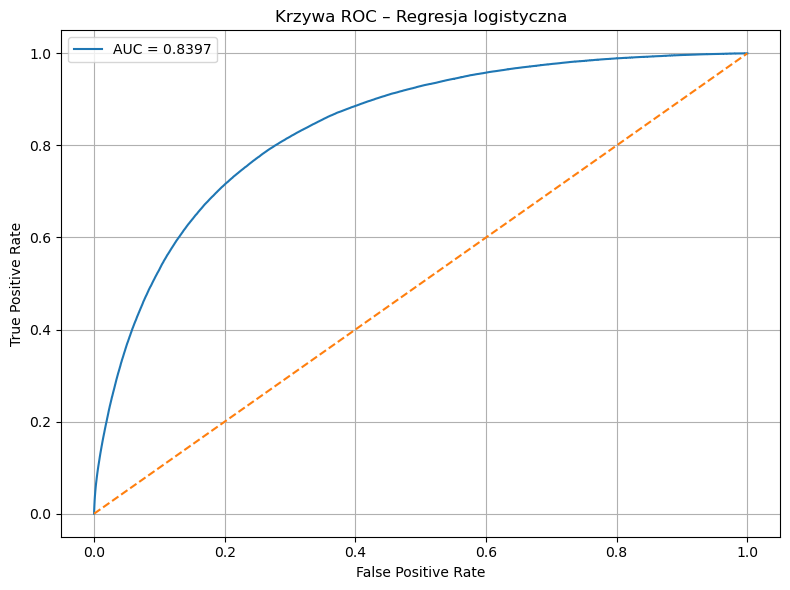

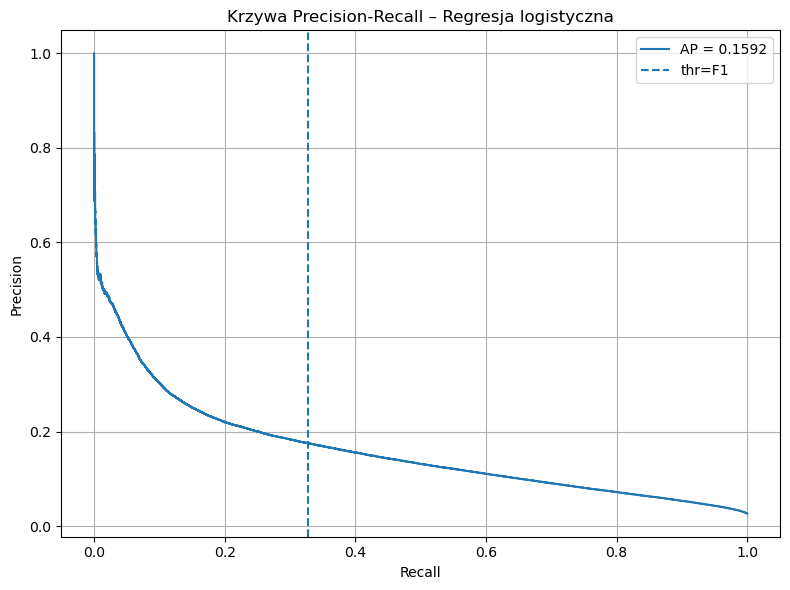

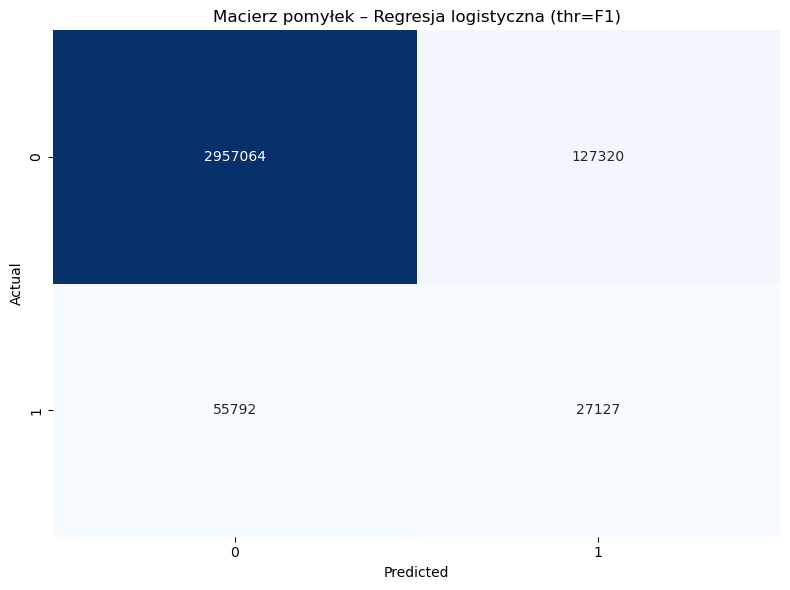

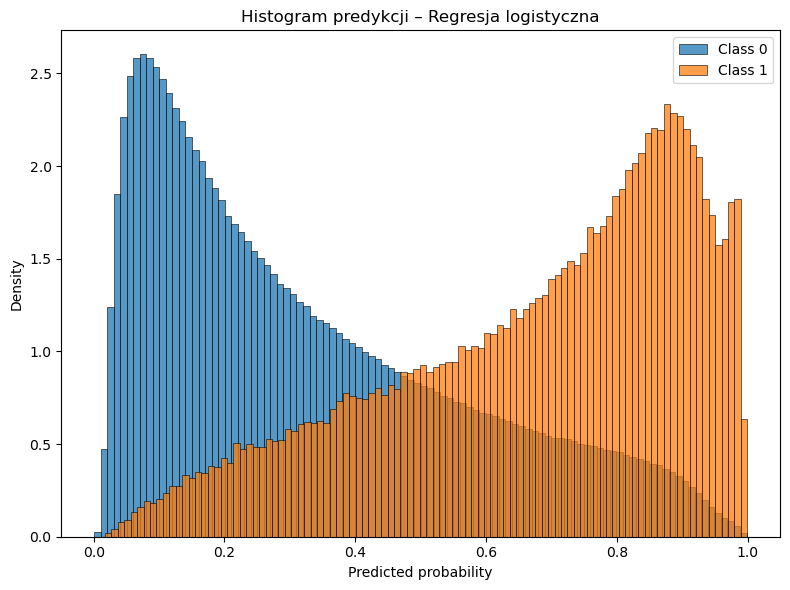

SHAP (Explainer[linear]) – start
SHAP subsample: 5,000 / 3,167,303


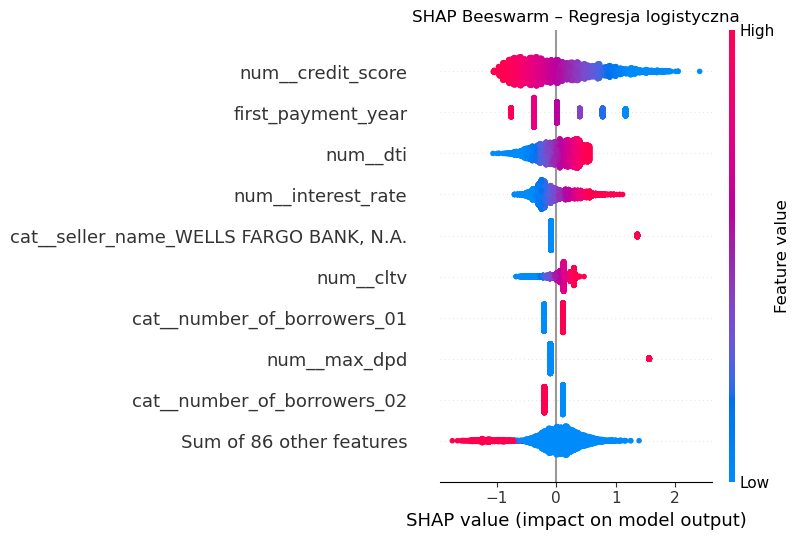

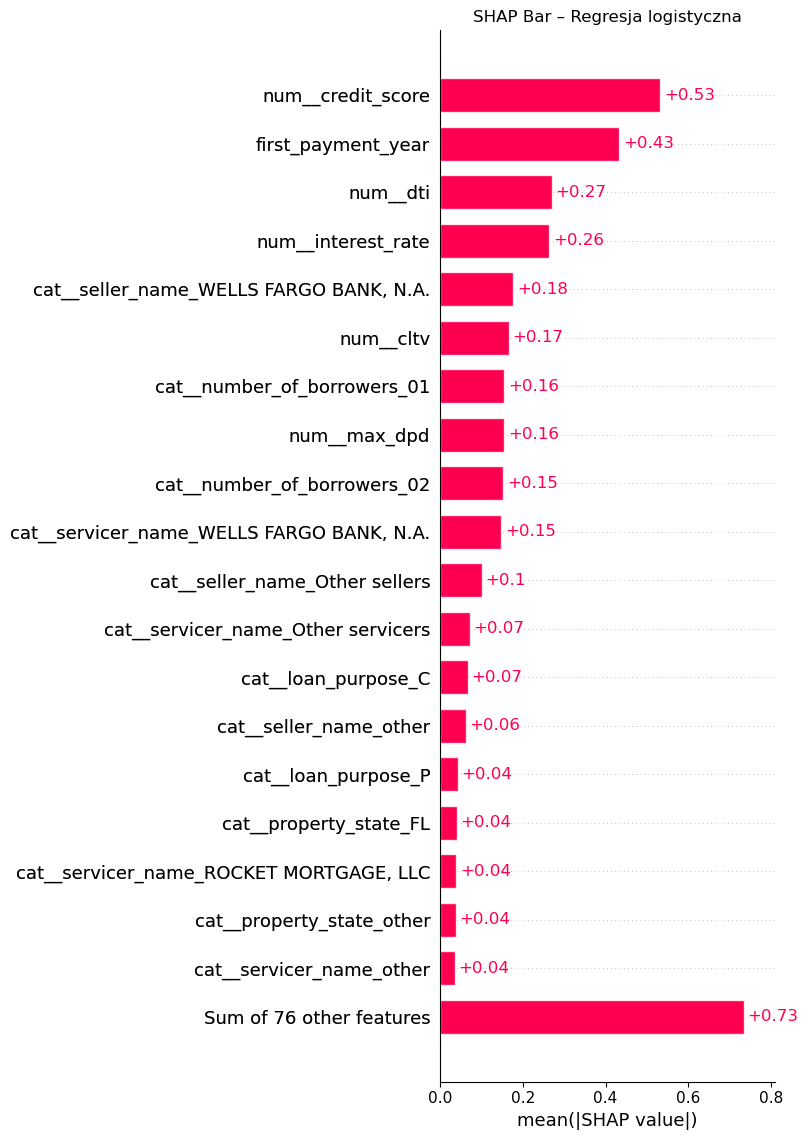

Top 5 cech (źródło SHAP/fallback): ['num__credit_score', 'first_payment_year', 'num__dti', 'num__interest_rate', 'cat__seller_name_WELLS FARGO BANK, N.A.']
TOP_ALL : ['num__credit_score', 'first_payment_year', 'num__dti', 'num__interest_rate', 'cat__seller_name_WELLS FARGO BANK, N.A.']
TOP_CONT: ['num__credit_score', 'num__dti', 'num__interest_rate']
TOP_CAT : ['cat__seller_name_WELLS FARGO BANK, N.A.']


<Figure size 640x480 with 0 Axes>

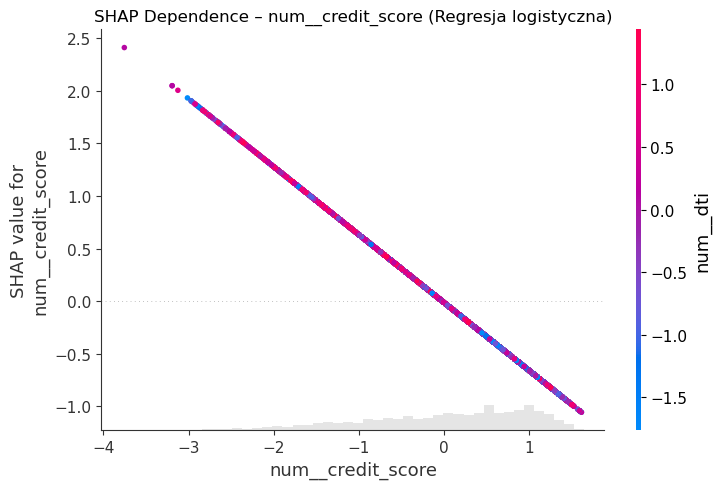

<Figure size 640x480 with 0 Axes>

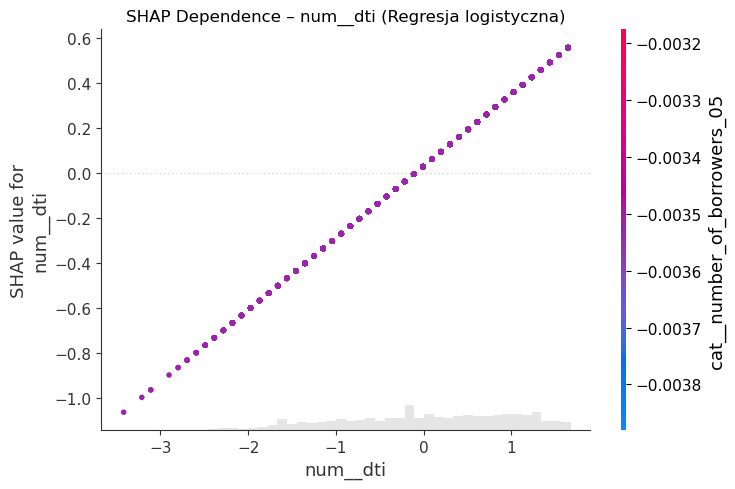

<Figure size 640x480 with 0 Axes>

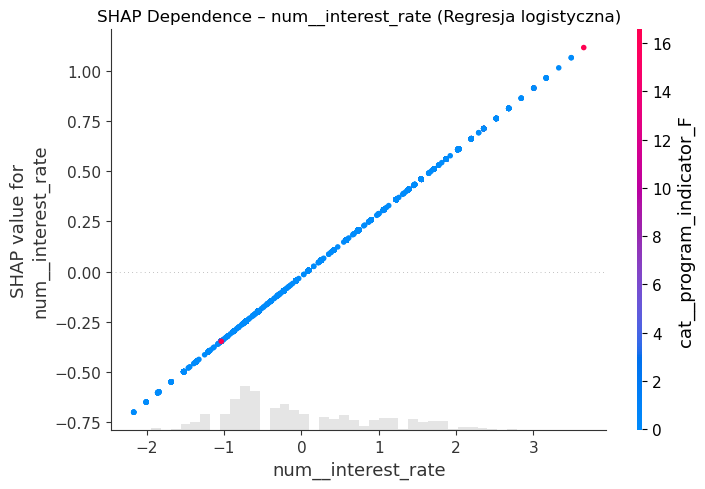

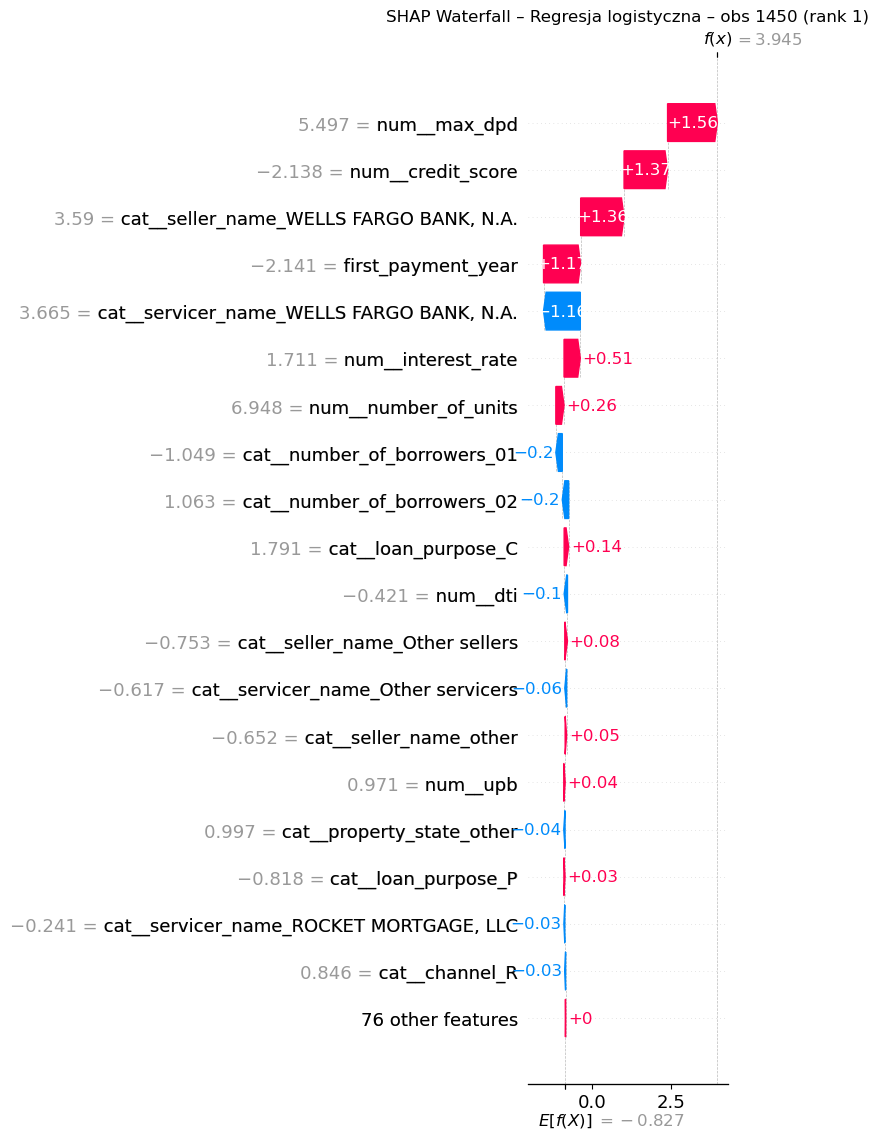

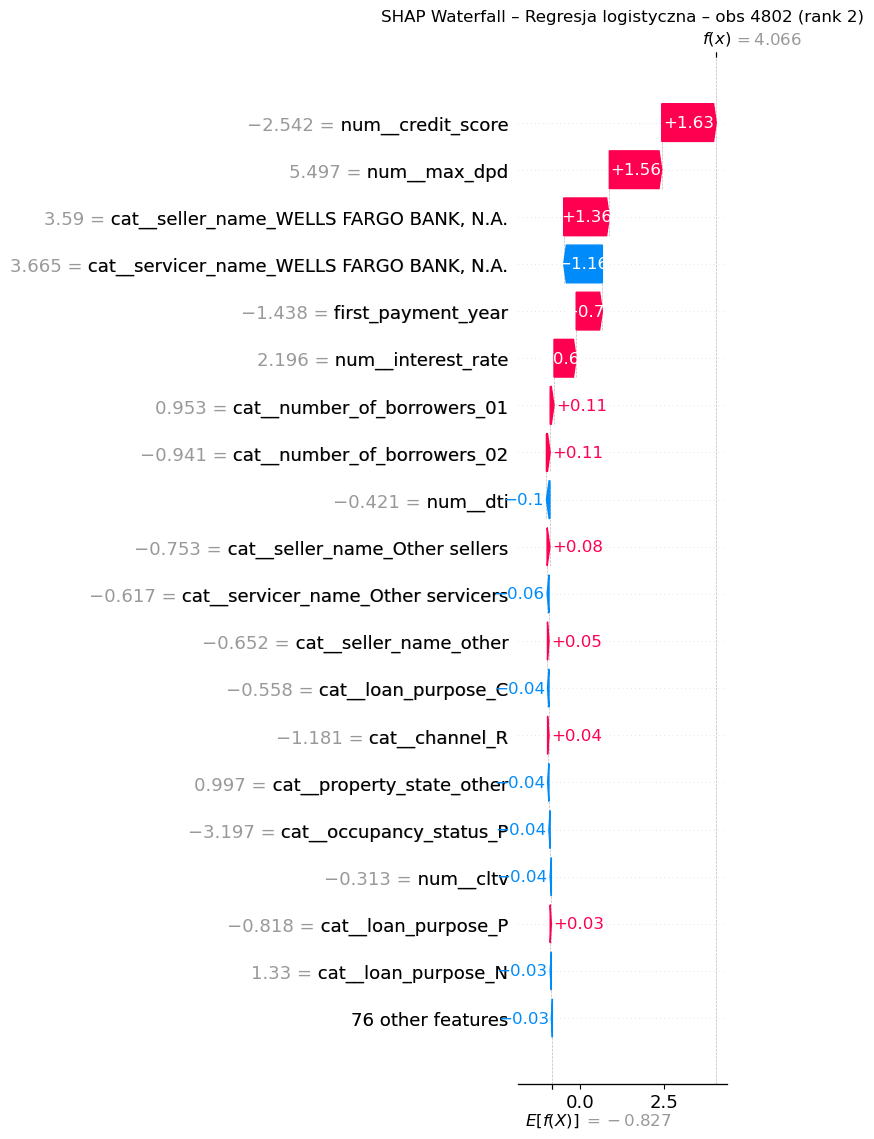

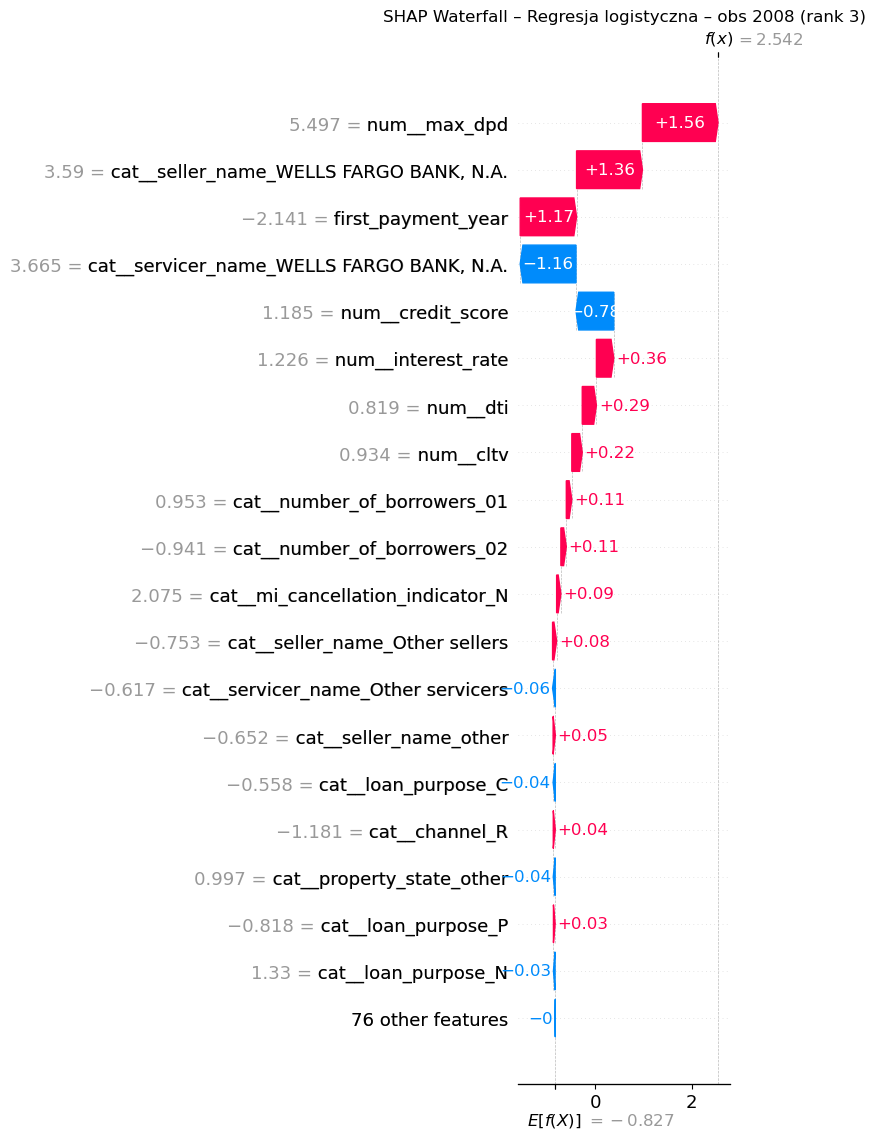

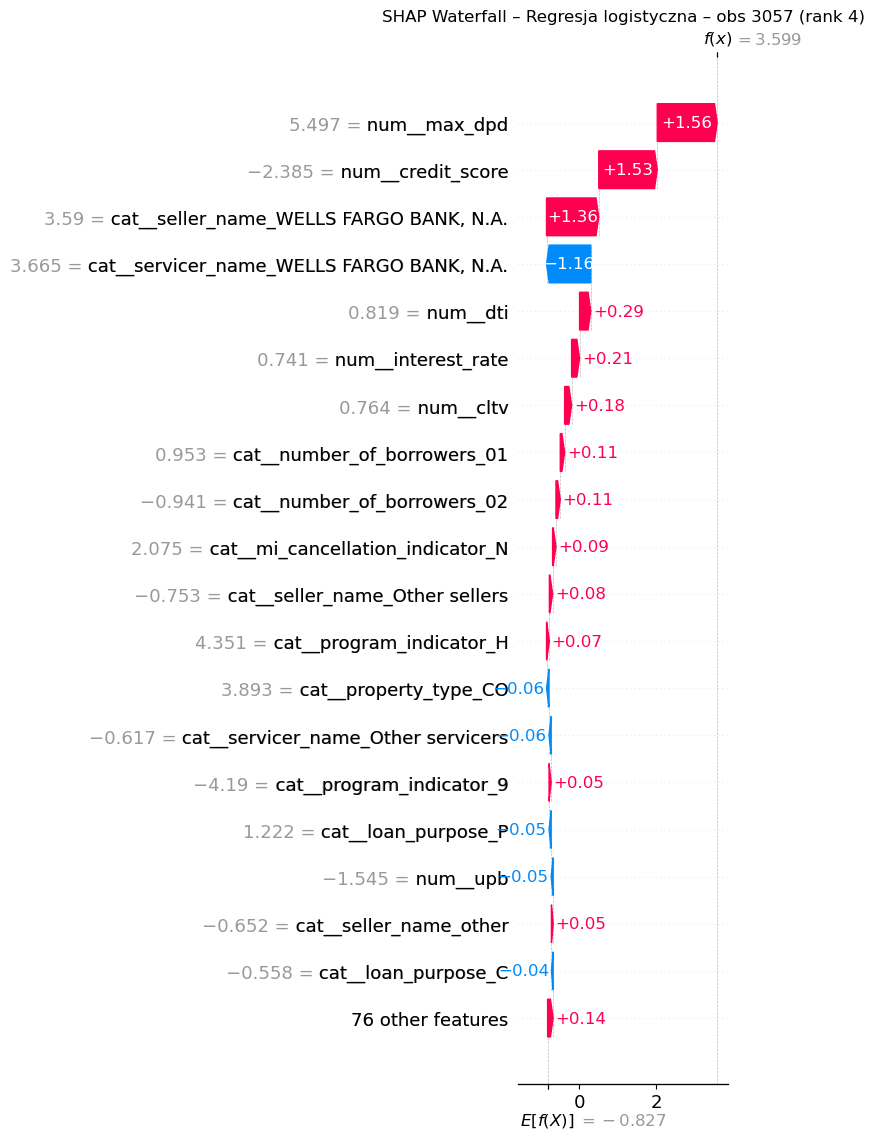

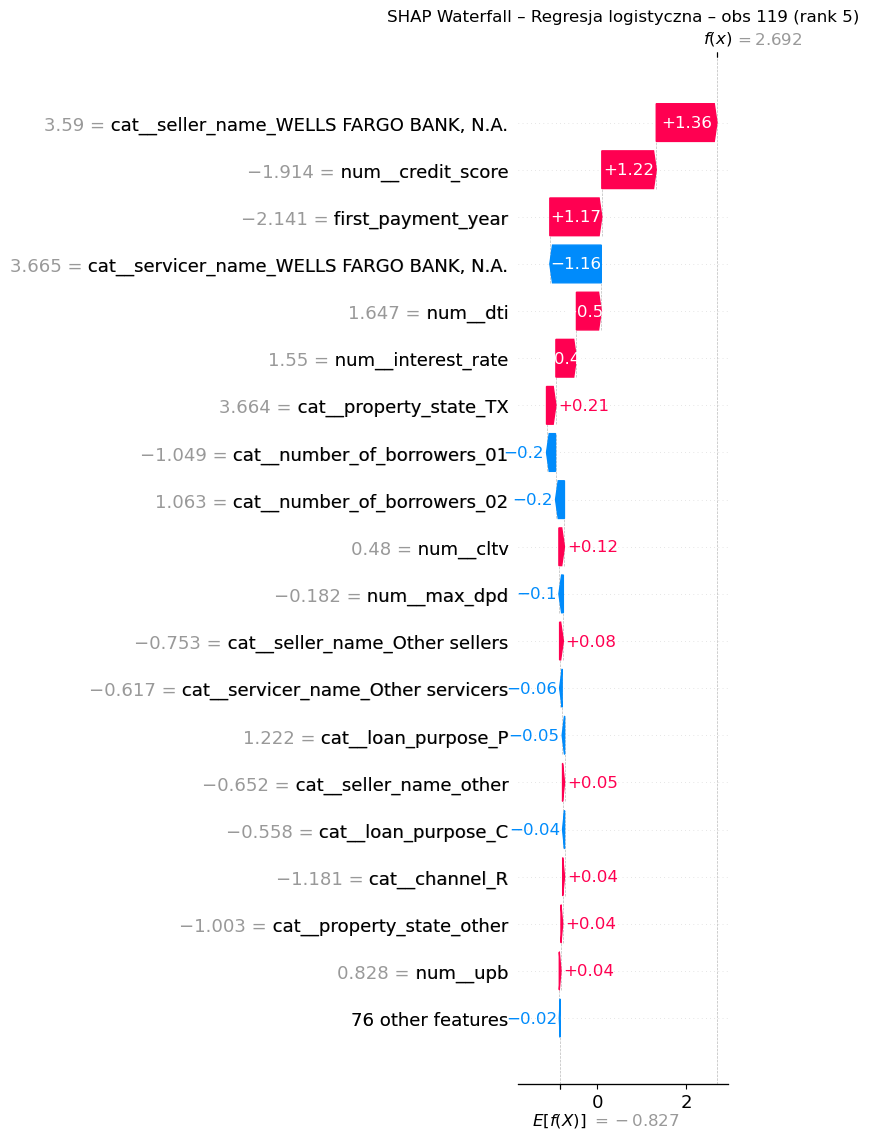

<Figure size 640x480 with 0 Axes>

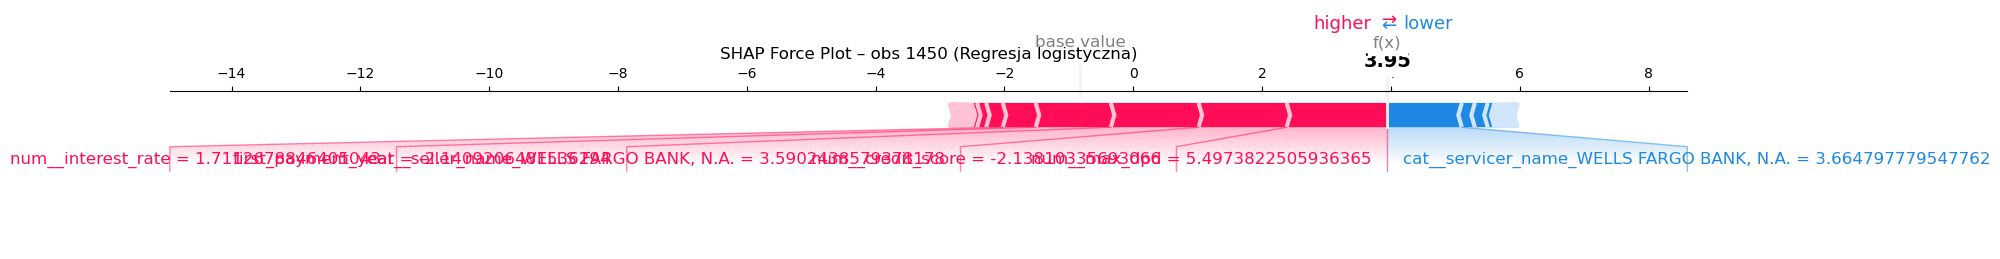

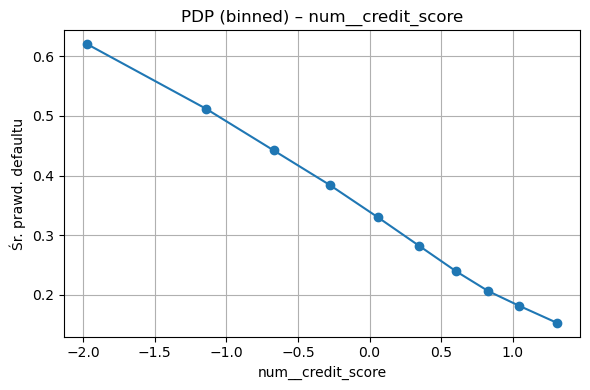

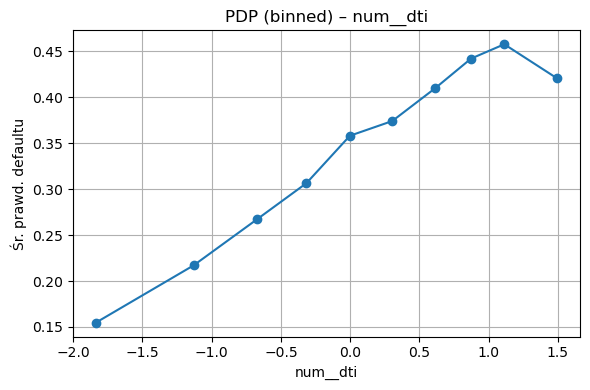

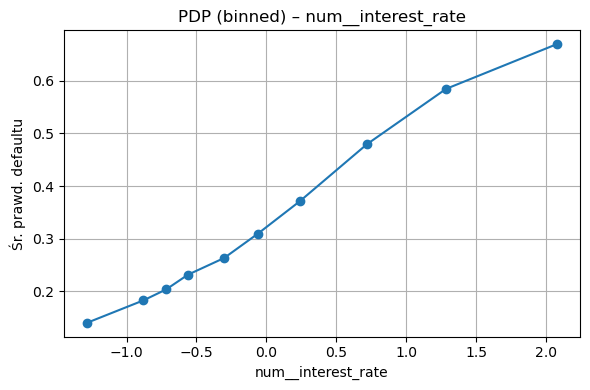

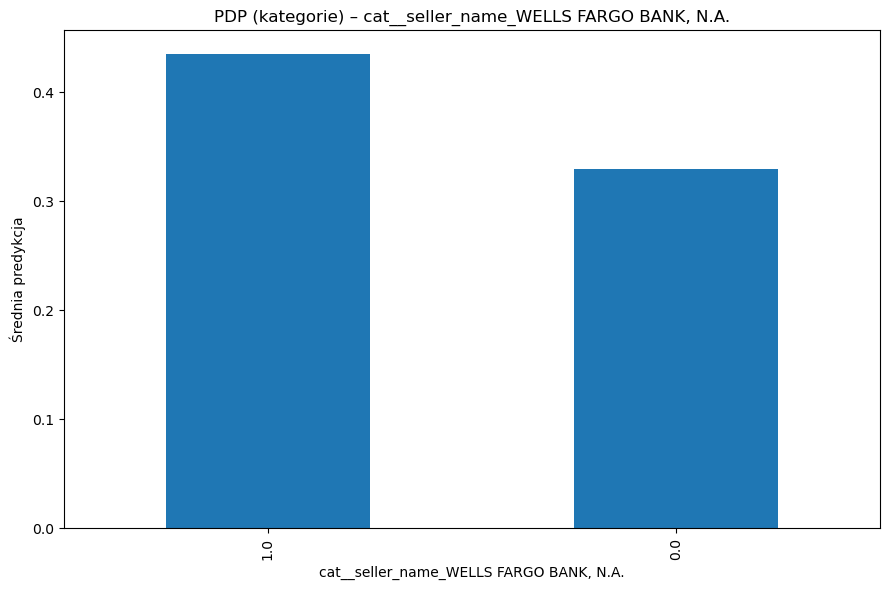

Boxploty FP/FN – Regresja logistyczna


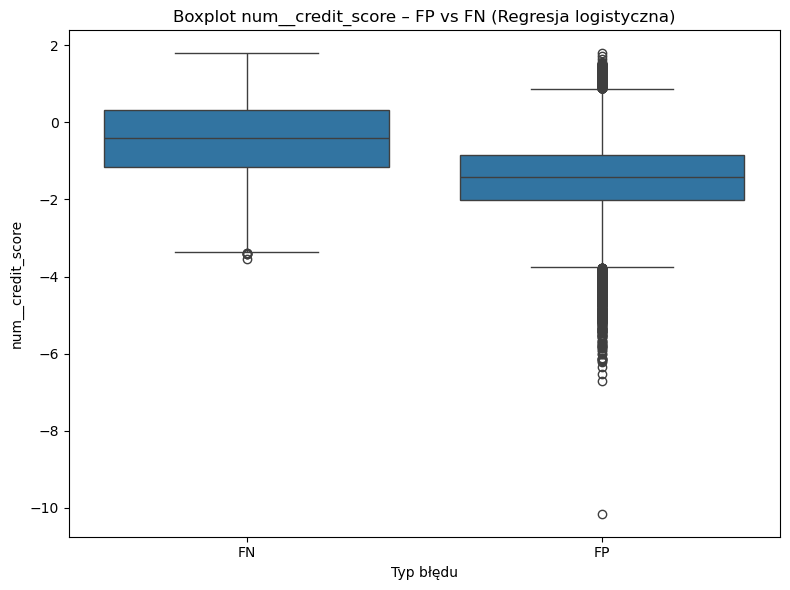

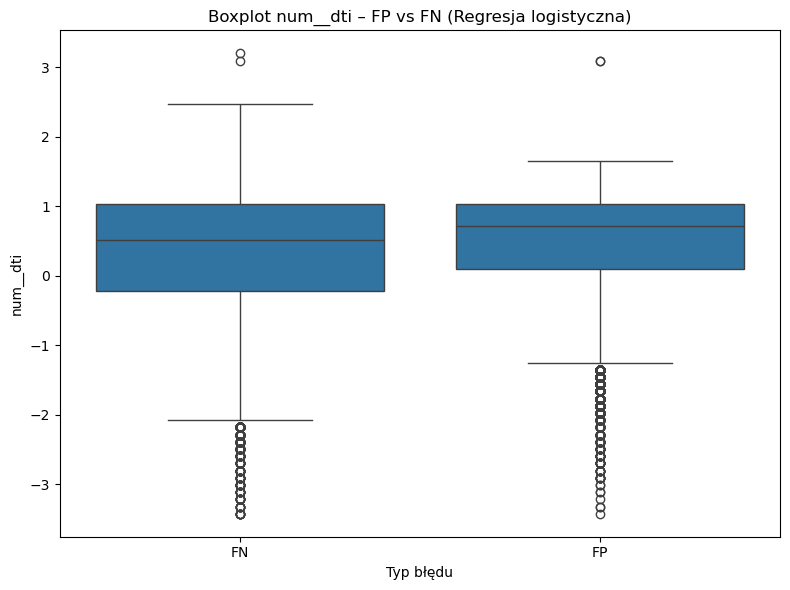

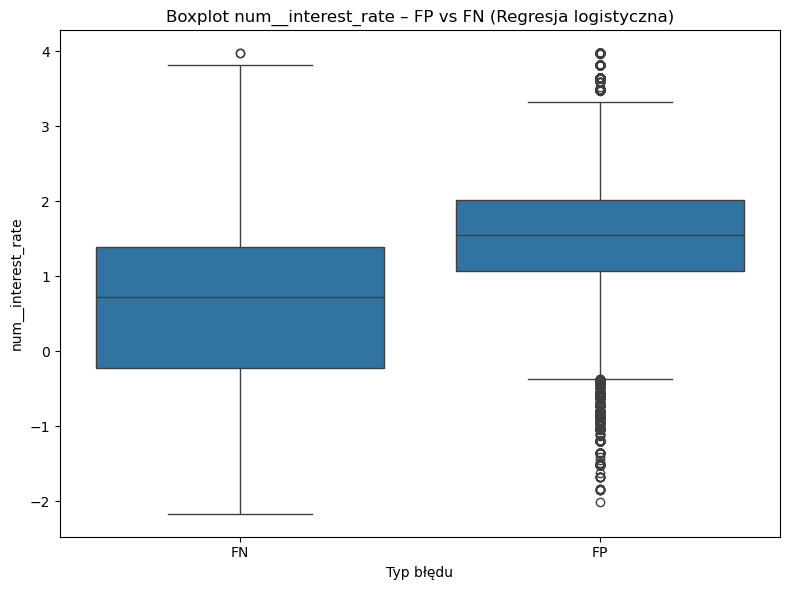

Perturbacja — start
Perturbacja — cechy: ['num__credit_score', 'num__dti', 'num__interest_rate']


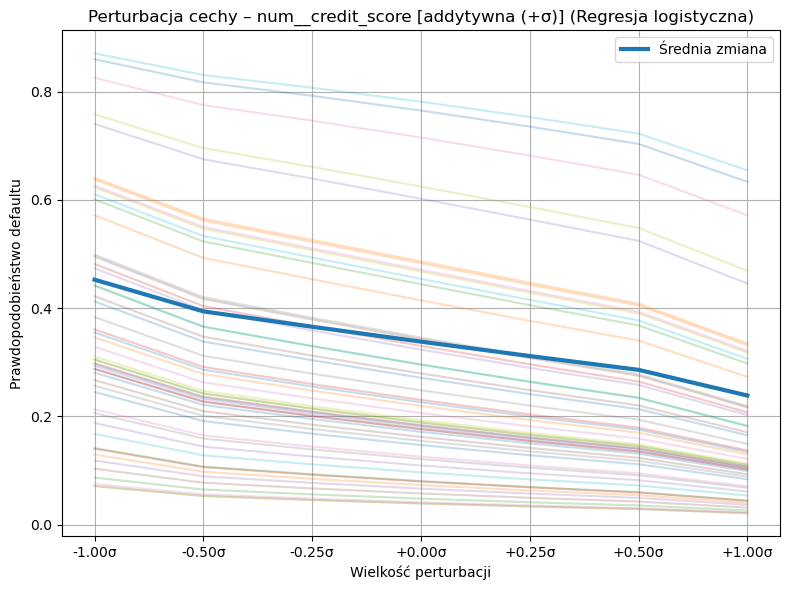

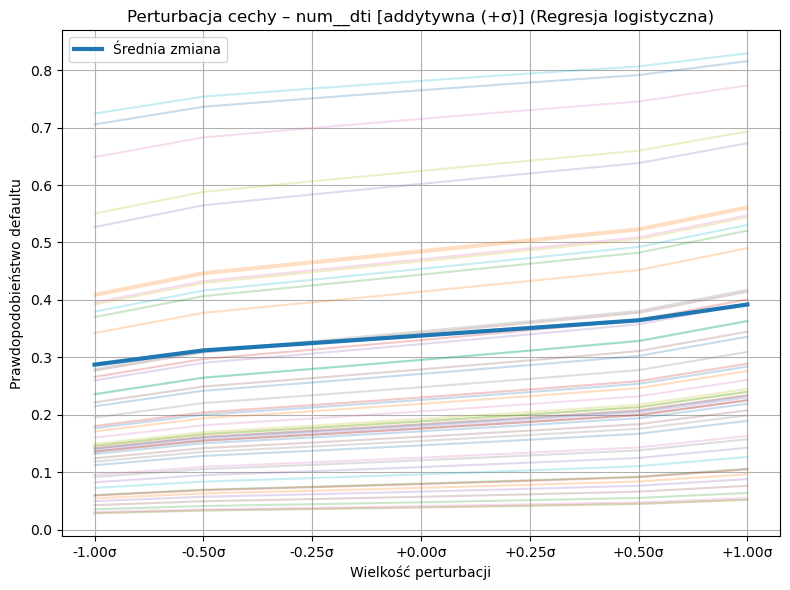

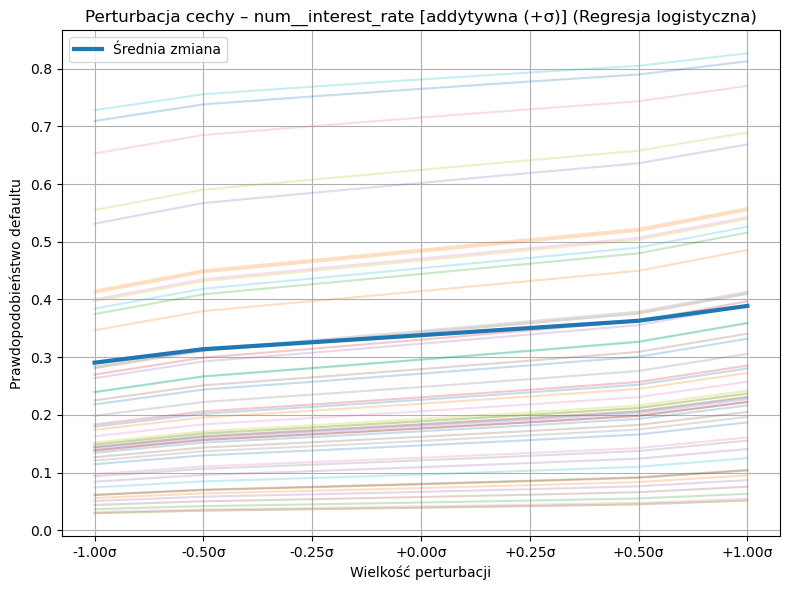

Zapisano: feature_perturbation_summary_logreg.csv


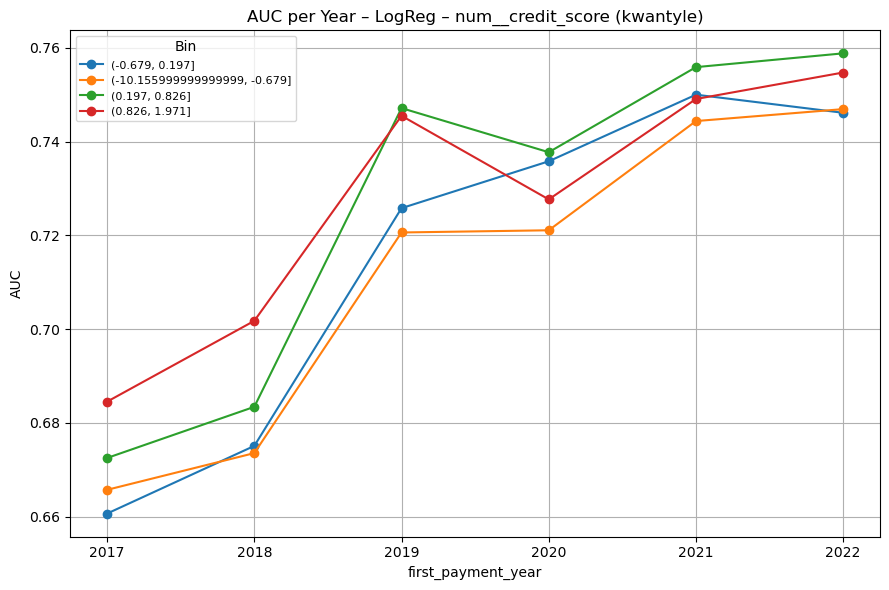

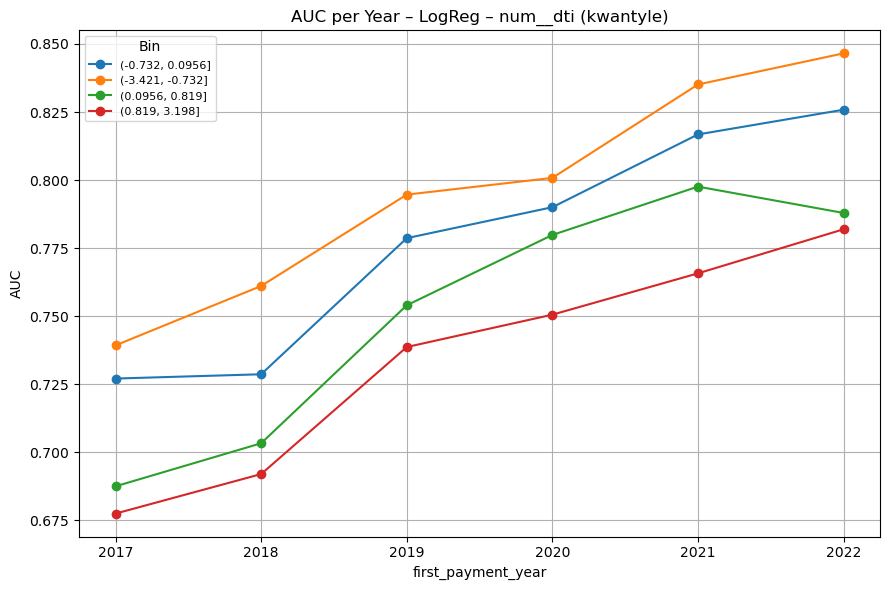

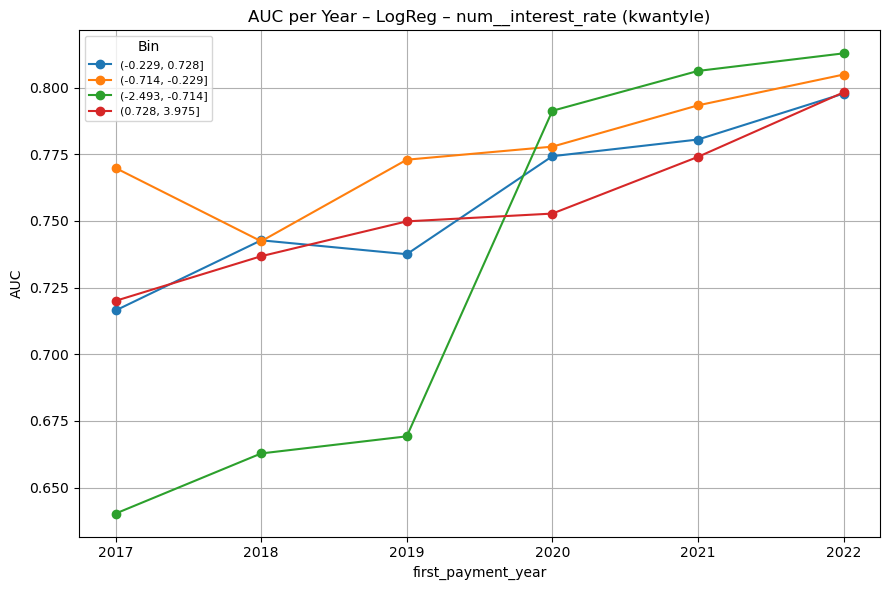

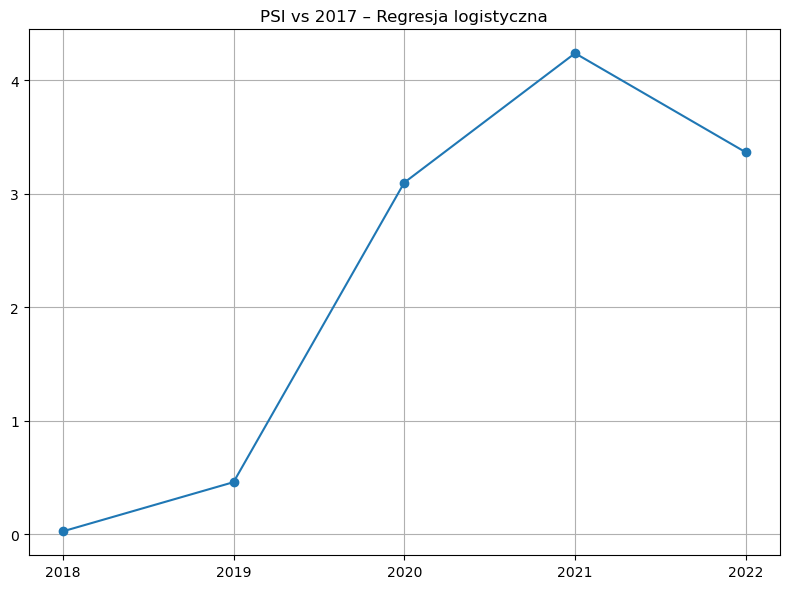

Permutation Importance – Regresja logistyczna


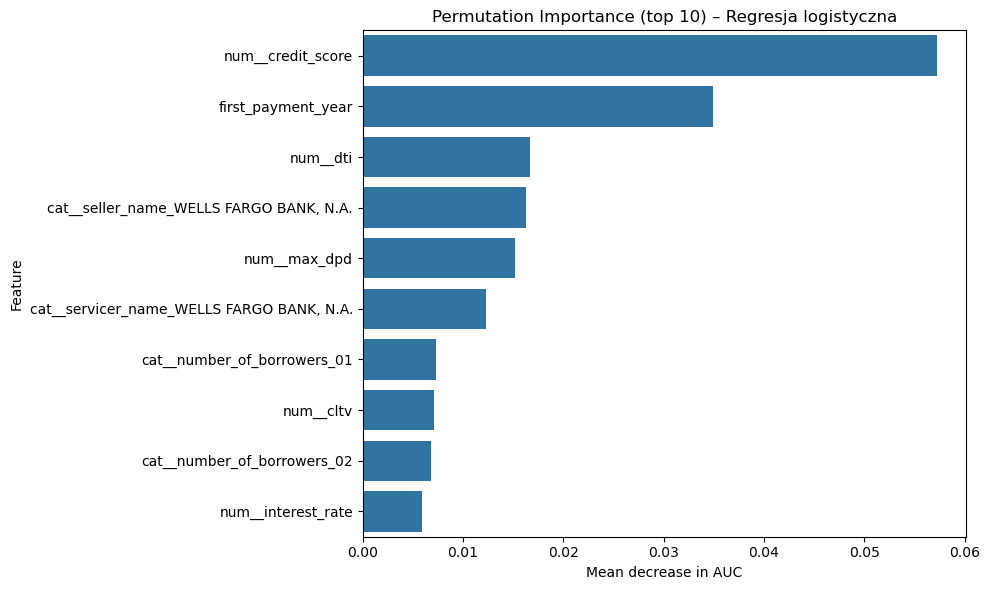

CSI (Top5 CONT): bazowy rok vs bieżące dane – Regresja logistyczna
CSI – cechy CONT: ['num__credit_score', 'num__dti', 'num__interest_rate']


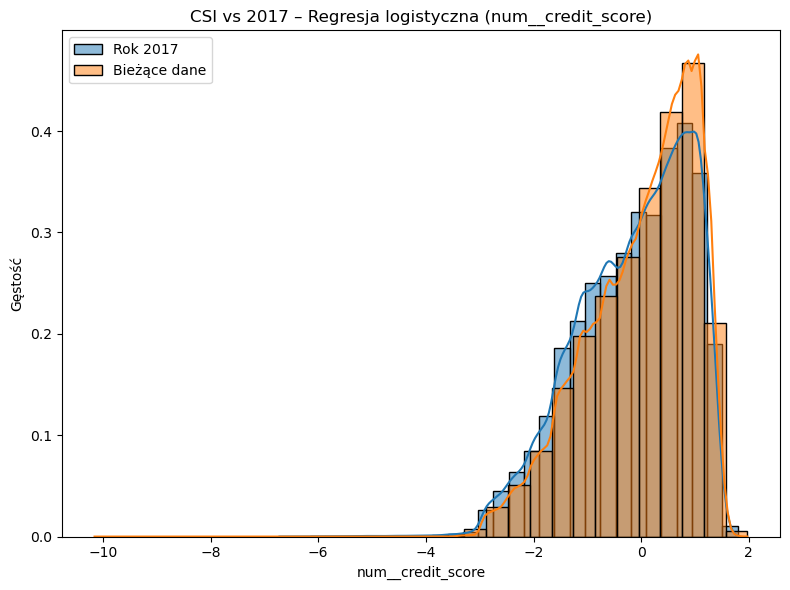

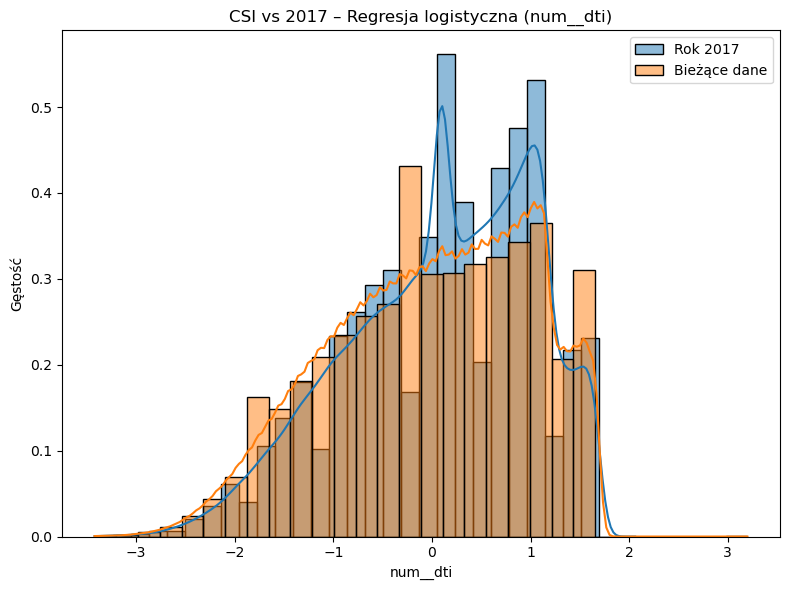

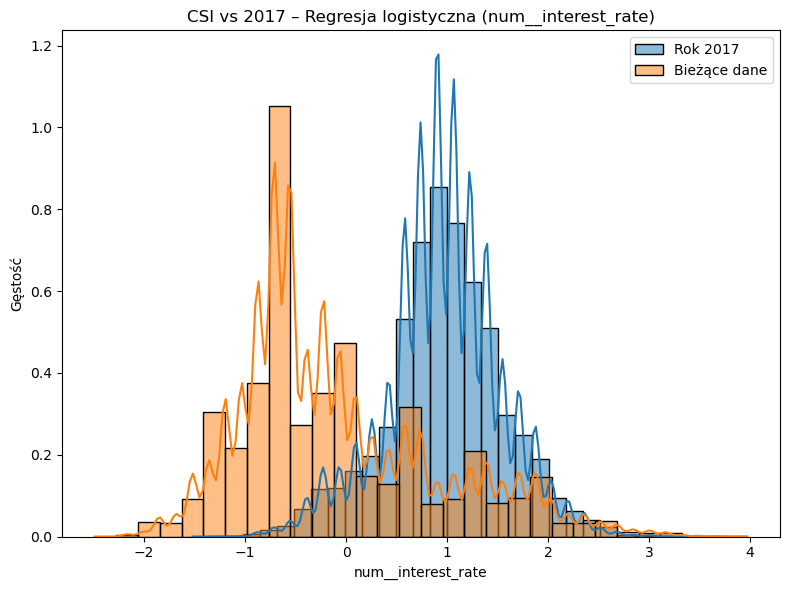

CSI zapisane do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza/Wyniki_Regresja_logistyczna/csi_logreg_top5_summary.csv
Analizy dla modelu regresji logistycznej zostały zapisane.


In [1]:
# ====================
# REGRESJA LOGISTYCZNA
# ====================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import re
from shap import maskers
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, classification_report,
    precision_recall_curve, average_precision_score, roc_curve)
from sklearn.inspection import permutation_importance
from scipy.stats import loguniform

def _safe_fname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))

# Ścieżki
data_path = ""
output_dir = os.path.join(data_path, "Wyniki_Regresja_logistyczna")
os.makedirs(output_dir, exist_ok=True)

# Dane
train_data = pd.read_parquet(f"{data_path}/final_base_nn_logit_train.parquet")
test_data  = pd.read_parquet(f"{data_path}/final_base_nn_logit_test.parquet")
X_train_full = train_data.drop(columns=["default_flag"], errors="ignore").copy()
y_train_full = train_data["default_flag"].astype(int).copy()
X_test_full  = test_data.drop(columns=["default_flag"], errors="ignore").copy()
y_test_full  = test_data["default_flag"].astype(int).copy()

# Pipeline
X_train, y_train = X_train_full, y_train_full
X_test,  y_test  = X_test_full, y_test_full
feature_names = X_train.columns.tolist()

# Tuning na podróbce + refit na całym zbiorze
def stratified_subsample(X, y, n_tune=500_000, random_state=42):
    df = X.copy()
    df["__y__"] = y.values
    if len(df) <= n_tune:
        return X, y
    frac = n_tune / len(df)
    parts = []
    rng = np.random.RandomState(random_state)
    for cls, g in df.groupby("__y__"):
        take = max(1, int(round(len(g) * frac)))
        parts.append(g.sample(n=take, random_state=int(rng.randint(0, 1_000_000_000))))
    sub = pd.concat(parts).sample(frac=1.0, random_state=random_state)
    return sub.drop(columns="__y__"), sub["__y__"].astype(y.dtype)

# Podpróbka do tuningu
X_tune, y_tune = stratified_subsample(X_train, y_train, n_tune=500_000)
print(f"Tuning on subsample: {len(X_tune):,} rows (full train: {len(X_train):,})")

# Pipeline do tuningu
pipeline_tune = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logreg", LogisticRegression(
        solver="lbfgs", penalty="l2",
        max_iter=3000, tol=5e-4,
        class_weight="balanced",
        random_state=42
    ))
])

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline_tune,
    param_distributions={"logreg__C": loguniform(1e-3, 1e2)},  
    n_iter=30,                 
    cv=3,                      
    scoring="roc_auc",
    verbose=2,
    n_jobs=1, pre_dispatch=1,
    random_state=42,
    refit=False
)

search.fit(X_tune, y_tune)
best_C = float(search.best_params_["logreg__C"])
print("Najlepsze C (subsample):", best_C)

# Finalny model
best_model = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logreg", LogisticRegression(
        solver="lbfgs", penalty="l2",
        C=best_C,
        max_iter=6000,
        tol=1e-4,
        class_weight="balanced",
        random_state=42
    ))
])

print("Refit na pełnym zbiorze z C =", best_C)
best_model.fit(X_train, y_train)

# ========================
# Zapis współczynników LR
# ========================
logreg = best_model.named_steps["logreg"]
coefs = np.ravel(logreg.coef_)

if coefs.size != len(feature_names):
    raise RuntimeError("Rozmiar coef_ nie zgadza się z liczbą cech.")

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "coef_abs": np.abs(coefs),
    "direction": np.where(coefs > 0, "positive", "negative")
}).sort_values("coef_abs", ascending=False)

coef_path = os.path.join(output_dir, "logreg_coefficients.csv")
coef_df.to_csv(coef_path, index=False, encoding="utf-8-sig")
print(f"Współczynniki regresji logistycznej zapisane do: {coef_path}")


# Predykcje
y_proba = best_model.predict_proba(X_test)[:, 1]
auc_val = roc_auc_score(y_test, y_proba)
print("AUC (test):", auc_val)

# Tuning progu: (A) maks F1 na PR, (B) Youden J na ROC
prec, rec, thr_pr = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (prec * rec) / np.maximum(prec + rec, 1e-12)
best_f1_idx = int(np.nanargmax(f1_scores))
thr_f1 = thr_pr[max(0, best_f1_idx-1)] if best_f1_idx < len(thr_pr) else 0.5

fpr, tpr, thr_roc = roc_curve(y_test, y_proba)
youden = tpr - fpr
best_j_idx = int(np.nanargmax(youden))
thr_j = thr_roc[best_j_idx] if best_j_idx < len(thr_roc) else 0.5

# Wybór progu roboczego (F1)
best_thr = float(thr_f1)
print(f"Wybrany próg (F1): {best_thr:.4f}")

y_pred = (y_proba >= best_thr).astype(int)
print("Raport (próg=F1):\n", classification_report(y_test, y_pred, zero_division=0))

# Zapis predykcji
test_out = X_test.copy()
test_out["pred_prob"] = y_proba
test_out["pred_label"] = y_pred
test_out["y_true"] = y_test
test_out.to_csv(f"{output_dir}/test_with_predictions_logreg.csv", index=False)

#====
# ROC
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
ax.plot([0,1],[0,1],"--")
ax.set_title("Krzywa ROC – Regresja logistyczna")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.grid(True); fig.tight_layout()
fig.savefig(f"{output_dir}/roc_curve_logreg.png"); plt.show(); plt.close(fig)

#=================
# Precision-Recall
ap = average_precision_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(rec, prec, label=f"AP = {ap:.4f}")
ax.axvline(x=rec[max(0, best_f1_idx-1)], linestyle="--", label="thr=F1")
ax.set_title("Krzywa Precision-Recall – Regresja logistyczna")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(True); fig.tight_layout()
fig.savefig(f"{output_dir}/precision_recall_curve_logreg.png"); plt.show(); plt.close(fig)

#================================
# Confusion matrix (dla progu F1)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Macierz pomyłek – Regresja logistyczna (thr=F1)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.tight_layout(); fig.savefig(f"{output_dir}/confusion_matrix_logreg.png"); plt.show(); plt.close(fig)

#====================
# Histogram predykcji
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(y_proba[y_test==0], label='Class 0', stat='density', bins=100, ax=ax)
sns.histplot(y_proba[y_test==1], label='Class 1', stat='density', bins=100, ax=ax)
ax.set_title("Histogram predykcji – Regresja logistyczna")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Density"); ax.legend()
fig.tight_layout(); fig.savefig(f"{output_dir}/prediction_hist_logreg.png"); plt.show(); plt.close(fig)

#=====
# SHAP
print("SHAP (Explainer[linear]) – start")

scaler = best_model.named_steps["scaler"]
logreg  = best_model.named_steps["logreg"]

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_names, index=X_test.index)

# Masker + linear algorithm dla LR
masker = maskers.Independent(X_train_scaled_df)
def _stratified_idx(y, n=5_000, random_state=42):
    y = pd.Series(y).reset_index(drop=True)
    if len(y) <= n: 
        return np.arange(len(y))
    frac = n / len(y)
    rng = np.random.RandomState(random_state)
    parts = []
    for cls, g in y.groupby(y.values):
        take = max(1, int(round(len(g) * frac)))
        parts.append(g.sample(n=take, random_state=int(rng.randint(0, 1_000_000_000))).index)
    idx = np.concatenate(parts)
    return np.random.RandomState(random_state).permutation(idx)

# ========================
# SHAP z fallback na coef_
try:
    explainer = shap.Explainer(logreg, masker=masker, algorithm="linear")

    shap_idx = _stratified_idx(y_test, n=5_000, random_state=42)
    X_test_shap = X_test_scaled_df.iloc[shap_idx]
    print(f"SHAP subsample: {len(X_test_shap):,} / {len(X_test_scaled_df):,}")

    exp = explainer(X_test_shap)

    # Beeswarm plot
    fig = plt.figure()
    shap.plots.beeswarm(exp, max_display=10, show=False)
    plt.title("SHAP Beeswarm – Regresja logistyczna")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "shap_beeswarm_logreg.png"))
    plt.show(); plt.close(fig)

    # Bar plot
    fig = plt.figure()
    shap.plots.bar(exp, max_display=20, show=False)
    plt.title("SHAP Bar – Regresja logistyczna")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "shap_bar_logreg.png"))
    plt.show(); plt.close(fig)

    # Top-5 wg mean(|SHAP|)
    vals = exp.values
    mean_abs_shap = np.nanmean(np.abs(vals), axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:5]
    top_vars = [exp.feature_names[i] for i in top_idx]

except Exception as e:
    print("Fallback na współczynnikach LR, ponieważ SHAP nie policzył się poprawnie.", e)
    coefs = np.ravel(logreg.coef_)
    if coefs.size != len(feature_names):
        raise RuntimeError("Rozmiar coef_ nie zgadza się z liczbą cech.")
    top_idx = np.argsort(np.abs(coefs))[::-1][:5]
    top_vars = [feature_names[i] for i in top_idx]

# Wynikowy ranking cech
print("Top 5 cech (źródło SHAP/fallback):", top_vars)

# Zapis rankingu do CSV
if "mean_abs_shap" in locals():
    shap_importance_df = pd.DataFrame({
        "feature": exp.feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)
    shap_importance_df.to_csv(
        os.path.join(output_dir, "shap_importance_mean_abs_logreg.csv"),
        index=False
    )

# ==========================
# Listy + TOP_CONT / TOP_CAT
def _is_dummy01(s: pd.Series) -> bool:
    u = pd.Series(s.dropna().unique())
    return (len(u) > 0) and u.isin([0, 1]).all()

_EXCLUDE_NAME_TOKENS = [
    "msa", "zip", "postal", "code", "id",
    "year", "month", "date", "day", "days_since", "number_of_borrowers"
]
_EXCLUDE_EXACT = {"first_payment_year"}

def _is_name_excluded(name: str) -> bool:
    n = str(name).lower()
    if n in _EXCLUDE_EXACT:
        return True
    return any(tok in n for tok in _EXCLUDE_NAME_TOKENS)

SAFE_CAT_FEATURES = [
    c for c in X_test.columns
    if not _is_name_excluded(c) and _is_dummy01(X_test[c])
]
SAFE_CONT_FEATURES = [
    c for c in X_test.columns
    if not _is_name_excluded(c)
    and pd.api.types.is_numeric_dtype(X_test[c])
    and not _is_dummy01(X_test[c])
    and X_test[c].nunique(dropna=True) >= 3
]

TOP_ALL  = [c for c in top_vars if c in X_test.columns]
TOP_CONT = [c for c in TOP_ALL if c in SAFE_CONT_FEATURES]
TOP_CAT  = [c for c in TOP_ALL if c in SAFE_CAT_FEATURES]

if not TOP_CONT:
    print("Uwaga: TOP_CONT puste – wybór pierwszych 5 z SAFE_CONT_FEATURES")
    TOP_CONT = SAFE_CONT_FEATURES[:5]
if not TOP_CAT:
    print("Uwaga: TOP_CAT puste – wybór pierwszych 5 z SAFE_CAT_FEATURES")
    TOP_CAT = SAFE_CAT_FEATURES[:5]

print("TOP_ALL :", TOP_ALL)
print("TOP_CONT:", TOP_CONT)
print("TOP_CAT :", TOP_CAT)

# SHAP Dependence
for feature in TOP_CONT[:5]:
    try:
        fig = plt.figure()
        shap.plots.scatter(exp[:, feature], color=exp, show=False)
        plt.title(f"SHAP Dependence – {feature} (Regresja logistyczna)")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"shap_dependence_{_safe_fname(feature)}_logreg.png"), dpi=150)
        plt.show(); plt.close(fig)
    except Exception as e:
        print(f"Błąd dependence plot dla {feature}: {e}")

# Waterfall plot
impact = np.abs(exp.values).sum(axis=1)
idx_sorted = np.argsort(impact)[::-1]
idx_keep = [int(i) for i in idx_sorted if np.isfinite(impact[int(i)]) and impact[int(i)] > 1e-12][:5]

for rank, idx in enumerate(idx_keep, start=1):
    try:
        fig = plt.figure()
        shap.plots.waterfall(exp[idx], max_display=20, show=False)
        plt.title(f"SHAP Waterfall – Regresja logistyczna – obs {idx} (rank {rank})")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"shap_waterfall_rank{rank}_obs{idx}_logreg.png"), dpi=150)
        plt.show(); plt.close(fig)
    except Exception as e:
        print(f"Błąd waterfall plot dla obs {idx}: {e}")

# Force plot
try:
    fig = plt.figure()
    shap.plots.force(exp[idx_keep[0]], matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot – obs {idx_keep[0]} (Regresja logistyczna)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"shap_force_obs{idx_keep[0]}_logreg.png"), dpi=150)
    plt.show(); plt.close(fig)
except Exception as e:
    try:
        base_val = np.squeeze(np.atleast_1d(exp.base_values))[0] if np.ndim(exp.base_values) else float(exp.base_values)
        shap.force_plot(base_val, exp.values[0], exp.data[0], matplotlib=True, show=False)
        plt.title(f"SHAP Force Plot – obs {idx_keep[0]} (fallback)")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"shap_force_obs{idx_keep[0]}_logreg.png"), dpi=150)
        plt.show(); plt.close()
    except Exception as e2:
        print(f"Błąd force plot: {e} / fallback: {e2}")

except Exception as e:
    print("Fallback na współczynnikach LR, ponieważ SHAP nie policzył się poprawnie.", e)
    coefs = np.ravel(logreg.coef_)
    if coefs.size != len(feature_names):
        raise RuntimeError("Rozmiar coef_ nie zgadza się z liczbą cech.")
    top_idx = np.argsort(np.abs(coefs))[::-1][:5]
    top_vars = [feature_names[i] for i in top_idx]
    print("Top 5 (fallback |coef|):", top_vars)

#=============
# PDP (binned)
for var in TOP_CONT:
    df_plot = pd.DataFrame({var: X_test[var], "pred_prob": y_proba}).dropna()
    if df_plot.empty:
        continue
    try:
        df_plot["bin"] = pd.qcut(df_plot[var], q=10, duplicates='drop')
    except Exception:
        print(f"PDP:pominięta zmienna {var} – brak sensownych kwantyli.")
        continue
    bin_means  = df_plot.groupby("bin", observed=False)[var].mean()
    pred_means = df_plot.groupby("bin", observed=False)["pred_prob"].mean()
    plt.figure(figsize=(6,4))
    plt.plot(bin_means, pred_means, marker="o")
    plt.title(f"PDP (binned) – {var}")
    plt.xlabel(var); plt.ylabel("Śr. prawd. defaultu")
    plt.grid(True); plt.tight_layout()
    plt.savefig(f"{output_dir}/pdp_binned_{_safe_fname(var)}_logreg.png")
    plt.show(); plt.close()

for var in TOP_CAT:
    dfc = pd.DataFrame({var: X_test[var], "predicted_proba": y_proba}).dropna()
    top_cats = dfc[var].value_counts().head(20).index
    dfc = dfc[dfc[var].isin(top_cats)]
    grouped = dfc.groupby(var)["predicted_proba"].mean().sort_values(ascending=False)
    ax = grouped.plot(kind="bar", figsize=(9,6))
    ax.set_title(f"PDP (kategorie) – {var}")
    ax.set_xlabel(var); ax.set_ylabel("Średnia predykcja")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"pdp_cat_{_safe_fname(var)}_logreg.png"))
    plt.show(); plt.close()

#===============
# Boxploty FP/FN
print("Boxploty FP/FN – Regresja logistyczna")

# Tabela błędów
errors_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "y_pred_proba": y_proba
}, index=X_test.index)

errors_df["error_type"] = np.select(
    [
        (errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0),  # FN
        (errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1)   # FP
    ],
    ["FN", "FP"],
    default="OK"
)

# Eksport pełnej tabeli błędów
errors_df.to_csv(os.path.join(output_dir, "errors_fp_fn_logreg.csv"), index=True)

# Wykresy FP i FN
plot_df = errors_df.loc[errors_df["error_type"].isin(["FP", "FN"])]

# Boxploty dla każdej cechy ciągłej z TOP_CONT
if not TOP_CONT:
    print("Uwaga: TOP_CONT jest puste – brak cech ciągłych do boxplotów.")
else:
    for var in TOP_CONT:
        try:
            df_plot = pd.concat([plot_df[["error_type"]], X_test[[var]]], axis=1)

            # Sprawdzenie liczby unikalnych wartości
            nunq = df_plot[var].dropna().nunique()
            if nunq < 3:
                print(f"Pominięcie {var} – za mało unikalnych wartości ({nunq}).")
                continue

            fig, ax = plt.subplots(figsize=(8, 6))
            sns.boxplot(
                data=df_plot,
                x="error_type", y=var,
                order=["FN", "FP"],
                ax=ax
            )
            ax.set_title(f"Boxplot {var} – FP vs FN (Regresja logistyczna)")
            ax.set_xlabel("Typ błędu")
            ax.set_ylabel(var)
            fig.tight_layout()
            out_path = os.path.join(output_dir, f"boxplot_fpfn_{_safe_fname(var)}_logreg.png")
            fig.savefig(out_path, dpi=150)
            plt.show()
            plt.close(fig)

        except Exception as e:
            print(f"Błąd boxplotu dla {var}: {e}")

#==================
# Perturbacja cechy
def _safe_fname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))

print("Perturbacja — start")

PERTURB_TOP_N   = 5
PERCENT_DELTAS  = np.array([-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20])
STD_STEPS       = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
SAMPLE_ROWS     = 200
SHOW_N_LINES    = 50

if not TOP_CONT:
    print("Uwaga: TOP_CONT puste — brak cech do perturbacji.")
    FEATURES_FOR_PERTURB = []
else:
    FEATURES_FOR_PERTURB = TOP_CONT[:PERTURB_TOP_N]

print("Perturbacja — cechy:", FEATURES_FOR_PERTURB)

base_idx = X_test.index[:min(SAMPLE_ROWS, len(X_test))]
X_base_all = X_test.loc[base_idx].copy()

perturb_summary_rows = []

for var in FEATURES_FOR_PERTURB:
    try:
        if var not in X_base_all.columns:
            print(f"Pominięta zmienna {var} — brak w X_test.")
            continue

        x = X_base_all[var].copy()
        x_nonan = x.dropna()
        if x_nonan.empty:
            print(f"Pominięta zmienna {var} — same NaN.")
            continue

        # Reguła wyboru trybu: dodatnie: mnożnik %, w przeciwnym razie kroki w sigma
        use_multiplicative = (x_nonan.min() > 0) and (np.nanmedian(x_nonan) > 1e-12)
        preds_grid, labels = [], []

        if use_multiplicative:
            for d in PERCENT_DELTAS:
                Xp = X_base_all.copy()
                Xp.loc[x_nonan.index, var] = x_nonan * (1.0 + d)
                y_pred = best_model.predict_proba(Xp)[:, 1]
                preds_grid.append(y_pred)
                labels.append(f"{int(d*100)}%")
        else:
            std = float(np.nanstd(x_nonan))
            if not np.isfinite(std) or std < 1e-12:
                # Ew. procenty
                for d in PERCENT_DELTAS:
                    Xp = X_base_all.copy()
                    Xp.loc[x_nonan.index, var] = x_nonan * (1.0 + d)
                    y_pred = best_model.predict_proba(Xp)[:, 1]
                    preds_grid.append(y_pred)
                    labels.append(f"{int(d*100)}%")
                use_multiplicative = True
            else:
                for s in STD_STEPS:
                    Xp = X_base_all.copy()
                    Xp.loc[x_nonan.index, var] = x_nonan + s * std
                    y_pred = best_model.predict_proba(Xp)[:, 1]
                    preds_grid.append(y_pred)
                    labels.append(f"{s:+.2f}σ")

        # Wykres i średnia
        fig, ax = plt.subplots(figsize=(8, 6))
        show_n = min(SHOW_N_LINES, len(X_base_all))
        for i in range(show_n):
            ax.plot(range(len(labels)), [preds_grid[k][i] for k in range(len(labels))], alpha=0.25)
        mean_curve = np.array([np.mean(pg) for pg in preds_grid])
        ax.plot(range(len(labels)), mean_curve, linewidth=3, label="Średnia zmiana")
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=0)

        mode_txt = "procentowa (×)" if use_multiplicative else "addytywna (+σ)"
        ax.set_title(f"Perturbacja cechy – {var} [{mode_txt}] (Regresja logistyczna)")
        ax.set_xlabel("Wielkość perturbacji")
        ax.set_ylabel("Prawdopodobieństwo defaultu")
        ax.legend(); ax.grid(True); fig.tight_layout()

        out_path = os.path.join(output_dir, f"feature_perturbation_{_safe_fname(var)}_logreg.png")
        fig.savefig(out_path, dpi=150)
        plt.show(); plt.close(fig)

        center_idx = len(mean_curve) // 2
        base_pred = float(mean_curve[center_idx])
        if use_multiplicative:
            if center_idx > 0 and center_idx < len(mean_curve) - 1:
                dy = mean_curve[center_idx + 1] - mean_curve[center_idx - 1]
                dx = (PERCENT_DELTAS[center_idx + 1] - PERCENT_DELTAS[center_idx - 1])
                elasticity = float(dy / max(dx, 1e-12))
            else:
                elasticity = np.nan
        else:
            if center_idx > 0 and center_idx < len(mean_curve) - 1:
                dy = mean_curve[center_idx + 1] - mean_curve[center_idx - 1]
                dx = (STD_STEPS[center_idx + 1] - STD_STEPS[center_idx - 1])
                elasticity = float(dy / max(dx, 1e-12))
            else:
                elasticity = np.nan

        row = {
            "feature": var,
            "mode": "multiplicative(%)" if use_multiplicative else "additive(std)",
            "base_pred": base_pred,
            "elasticity_local": elasticity
        }

        # Średnie poziomy dla kilku kluczowych punktów
        if use_multiplicative:
            key = { -10: None, 0: None, +10: None }
            for pct in key.keys():
                try:
                    idx = list(PERCENT_DELTAS).index(pct/100.0)
                    key[pct] = float(mean_curve[idx])
                except ValueError:
                    key[pct] = np.nan
            row.update({
                "mean_pred_-10%": key[-10],
                "mean_pred_0%":   key[0],
                "mean_pred_+10%": key[+10],
                "delta(+10% - 0%)": (key[+10] - key[0]) if (key[+10] is not None and key[0] is not None) else np.nan,
                "delta(0% - -10%)": (key[0] - key[-10]) if (key[0] is not None and key[-10] is not None) else np.nan
            })
        else:
            key = { -0.5: None, 0.0: None, +0.5: None }
            for s in key.keys():
                try:
                    idx = list(STD_STEPS).index(s)
                    key[s] = float(mean_curve[idx])
                except ValueError:
                    key[s] = np.nan
            row.update({
                "mean_pred_-0.5σ": key[-0.5],
                "mean_pred_0σ":    key[0.0],
                "mean_pred_+0.5σ": key[+0.5],
                "delta(+0.5σ - 0σ)": (key[+0.5] - key[0.0]) if (key[+0.5] is not None and key[0.0] is not None) else np.nan,
                "delta(0σ - -0.5σ)": (key[0.0] - key[-0.5]) if (key[0.0] is not None and key[-0.5] is not None) else np.nan
            })

        perturb_summary_rows.append(row)

    except Exception as e:
        print(f"Perturbacja — błąd dla {var}: {e}")

# Zapis zbiorczy
if perturb_summary_rows:
    pd.DataFrame(perturb_summary_rows).to_csv(
        os.path.join(output_dir, "feature_perturbation_summary_logreg.csv"),
        index=False
    )
    print("Zapisano: feature_perturbation_summary_logreg.csv")
else:
    print("Perturbacja — brak wyników do zapisania.")

#=============
# AUC per year
df_base = X_test.copy()
df_base["y_proba"] = y_proba
df_base["y_true"]  = y_test.values
df_base["first_payment_year"] = pd.to_numeric(df_base["first_payment_year"], errors="coerce").astype("Int64")

# AUC per year dla TOP_CONT
nbins = 4          # liczba kwantylowych binów
min_group = 30     # minimalna liczebność

for feat in TOP_CONT:
    df = df_base[["first_payment_year", feat, "y_true", "y_proba"]].dropna().copy()
    # Kwantyle
    try:
        df["bin"] = pd.qcut(df[feat], q=nbins, duplicates="drop")
    except Exception:
        print(f"Pominięcie {feat} – za mało unikalnych wartości do qcut.")
        continue
    rows = []
    for (yr, b), g in df.groupby(["first_payment_year", "bin"], observed=False):
        if pd.isna(yr) or len(g) < min_group or g["y_true"].nunique() < 2:
            continue
        auc = roc_auc_score(g["y_true"], g["y_proba"])
        rows.append({"year": int(yr), "bin": str(b), "AUC": auc})
    if not rows:
        print(f"Brak danych do AUC per year dla {feat}.")
        continue

    res = pd.DataFrame(rows).sort_values(["year", "bin"])
    safe = re.sub(r"[^A-Za-z0-9_\-+=]+", "_", feat)
    res.to_csv(f"{output_dir}/auc_per_year_by_bin_{safe}_logreg.csv", index=False)

    # Wykres
    pivot = res.pivot(index="year", columns="bin", values="AUC").sort_index()
    plt.figure(figsize=(9, 6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=str(col))
    plt.title(f"AUC per Year – LogReg – {feat} (kwantyle)")
    plt.xlabel("first_payment_year")
    plt.ylabel("AUC")
    plt.grid(True); plt.legend(title="Bin", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/auc_per_year_by_bin_{safe}_logreg.png")
    plt.show()

#============
# PSI vs 2017
def calculate_psi(expected, actual, bins=10):
    e_cnt, edges = np.histogram(expected, bins=bins, range=(0, 1))
    a_cnt, _     = np.histogram(actual,   bins=edges)
    e_perc = e_cnt / max(e_cnt.sum(), 1) + 1e-6
    a_perc = a_cnt / max(a_cnt.sum(), 1) + 1e-6
    return float(np.sum((e_perc - a_perc) * np.log(e_perc / a_perc)))

if "first_payment_year" in X_test.columns:
    base_year = 2017
    years = sorted(pd.Series(X_test["first_payment_year"]).dropna().unique().astype(int))
    if base_year in years:
        base_scores = test_out.loc[X_test["first_payment_year"] == base_year, "pred_prob"]
        psi_vals = []
        for year in years:
            if year == base_year: 
                continue
            actual = test_out.loc[X_test["first_payment_year"] == year, "pred_prob"]
            if len(actual) > 0 and len(base_scores) > 0:
                psi_vals.append((year, calculate_psi(base_scores, actual)))
        if psi_vals:
            psi_df = pd.DataFrame(psi_vals, columns=["Rok", "PSI"])
            fig, ax = plt.subplots(figsize=(8,6))
            ax.plot(psi_df["Rok"], psi_df["PSI"], marker="o")
            ax.set_title("PSI vs 2017 – Regresja logistyczna")
            ax.grid(True); 
            ax.set_xticks(psi_df["Rok"])
            ax.set_xticklabels(psi_df["Rok"].astype(str))            
            fig.tight_layout()
            fig.savefig(f"{output_dir}/psi_curve_logreg.png"); plt.show(); plt.close(fig)
            psi_df.to_csv(f"{output_dir}/psi_values_logreg.csv", index=False)
    else:
        print("Brak roku bazowego 2017 w X_test - analiza PSI pominięta.")
else:
    print("Brak kolumny first_payment_year - analiza PSI pominięta.")

#=======================
# Permutation Importance
print("Permutation Importance – Regresja logistyczna")

perm_idx = _stratified_idx(y_test, n=10_000, random_state=42)
X_test_small = X_test.iloc[perm_idx].copy()
y_test_small = y_test.iloc[perm_idx].copy()

perm_result = permutation_importance(
    best_model, X_test_small, y_test_small,
    n_repeats=3,           
    scoring='roc_auc',
    random_state=42,
    n_jobs=1              
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

perm_df.to_csv(f"{output_dir}/permutation_importance_full_logreg.csv", index=False)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x="importance_mean", y="feature", data=perm_df.head(10), ax=ax)
ax.set_title("Permutation Importance (top 10) – Regresja logistyczna")
ax.set_xlabel("Mean decrease in AUC"); ax.set_ylabel("Feature")
fig.tight_layout(); fig.savefig(f"{output_dir}/permutation_importance_top10_plot_logreg.png"); plt.show(); plt.close(fig)

#========
# CSI 
print("CSI (Top5 CONT): bazowy rok vs bieżące dane – Regresja logistyczna")

# Rok bazowy i kolumna lat
base_year = 2017
X_test["first_payment_year"] = pd.to_numeric(
    X_test["first_payment_year"], errors="coerce"
).astype("Int64")

# Wybór cech
if "TOP_CONT" in globals() and isinstance(TOP_CONT, (list, tuple)) and len(TOP_CONT) > 0:
    top_features = list(TOP_CONT)[:5]
else:
    # Fallback: top_vars z SHAP przefiltrowane do zmiennych ciągłych
    try:
        imp_vals = np.abs(exp.values).mean(axis=0)
        _top_all = pd.Series(imp_vals, index=exp.feature_names).nlargest(10).index.tolist()
    except Exception:
        _top_all = [c for c in X_test.columns][:10]

    # Użycie SAFE_CONT_FEATURES do filtracji
    if "SAFE_CONT_FEATURES" in globals():
        top_features = [c for c in _top_all if c in SAFE_CONT_FEATURES][:5]
    else:
        # Jeśli nie ma SAFE_CONT_FEATURES
        top_features = [
            c for c in _top_all
            if c in X_test.columns
            and c != "first_payment_year"
            and pd.api.types.is_numeric_dtype(X_test[c])
            and X_test[c].nunique(dropna=True) >= 3
            and not str(c).lower().startswith("cat__")
        ][:5]
print("CSI – cechy CONT:", top_features)

def _safe(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.\-+=]+", "_", str(s))

def _quantile_edges(arr, max_bins=10, min_bins=3):
    s = pd.to_numeric(pd.Series(arr), errors="coerce").dropna().values
    if s.size < 2:
        return None
    for b in range(max_bins, min_bins - 1, -1):
        edges = np.unique(np.quantile(s, np.linspace(0, 1, b + 1)))
        if edges.size >= (min_bins + 1):
            return edges
    return None

def _csi_from_edges(base_vals, cur_vals, edges):
    b = pd.to_numeric(pd.Series(base_vals), errors="coerce").dropna().values
    c = pd.to_numeric(pd.Series(cur_vals),  errors="coerce").dropna().values
    if b.size == 0 or c.size == 0:
        return np.nan
    b_cnt, _ = np.histogram(b, bins=edges)
    c_cnt, _ = np.histogram(c, bins=edges)
    if b_cnt.sum() == 0 or c_cnt.sum() == 0:
        return np.nan
    b_p = b_cnt / b_cnt.sum() + 1e-6
    c_p = c_cnt / c_cnt.sum() + 1e-6
    return float(np.sum((b_p - c_p) * np.log(b_p / c_p)))

# Wykresy
rows = []
min_n = 20  # Minimalna liczność w roku bazowym i w bieżących

for feat in top_features:
    if feat not in X_test.columns:
        print(f"CSI: Pominięcie {feat} – brak w X_test.")
        continue

    if feat == "first_payment_year":
        continue
    if (not pd.api.types.is_numeric_dtype(X_test[feat])) or X_test[feat].nunique(dropna=True) < 3:
        print(f"CSI: pominięta cecha {feat} – nieciągła/nienumeryczna albo zbyt mało unikalnych wartości.")
        continue

    df = X_test[["first_payment_year", feat]].dropna().copy()
    if df.empty:
        print(f"CSI: pominięta zmienna {feat} – brak danych po dropna().")
        continue

    counts = df["first_payment_year"].value_counts()
    if base_year not in counts.index or counts.loc[base_year] < min_n:
        print(f"CSI: pominięta zmienna {feat} – brak wystarczających danych dla roku bazowego {base_year}.")
        continue

    base_vals = df.loc[df["first_payment_year"] == base_year, feat].values
    cur_vals  = df.loc[df["first_payment_year"] != base_year, feat].values
    if base_vals.size < min_n or cur_vals.size < min_n:
        print(f"CSI: pominięta zmeinna {feat} – za mało danych (base={base_vals.size}, curr={cur_vals.size}).")
        continue

    edges = _quantile_edges(np.concatenate([base_vals, cur_vals]), max_bins=10, min_bins=3)
    if edges is None:
        print(f"CSI: pominięta zmienna {feat} – nie udało się wyznaczyć sensownych binów.")
        continue

    csi_val = _csi_from_edges(base_vals, cur_vals, edges)
    rows.append({"feature": feat, "base_year": base_year, "n_base": base_vals.size, "n_curr": cur_vals.size, "CSI": csi_val})

    # Wykres: histogram + KDE
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.histplot(pd.to_numeric(base_vals), label=f"Rok {base_year}", kde=True, stat="density", bins=30, ax=ax)
    sns.histplot(pd.to_numeric(cur_vals),  label="Bieżące dane", kde=True, stat="density", bins=30, ax=ax)
    ax.set_title(f"CSI vs {base_year} – Regresja logistyczna ({feat})")
    ax.set_xlabel(feat)
    ax.set_ylabel("Gęstość")
    ax.legend()
    fig.tight_layout()
    plt.savefig(f"{output_dir}/csi_distribution_{_safe(feat)}_logreg.png")
    plt.show()
    plt.close(fig)

# Zbiorczy CSV
if rows:
    csi_df = pd.DataFrame(rows).sort_values(["feature"])
    csi_df.to_csv(f"{output_dir}/csi_logreg_top5_summary.csv", index=False)
    print("CSI zapisane do:", f"{output_dir}/csi_logreg_top5_summary.csv")
else:
    print("CSI: brak wyników dla wybranych cech CONT.")

# Koniec kodu regresji logistycznej
print("Analizy dla modelu regresji logistycznej zostały zapisane.")

# Sieć neuronowa


Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END batch_size=2048, epochs=30, model__activation=elu, model__alpha=0.0003, model__dropout=0.2, model__hidden_layer_sizes=(256, 128), model__learning_rate=0.0005; total time= 2.9min
[CV] END batch_size=2048, epochs=30, model__activation=elu, model__alpha=0.0003, model__dropout=0.2, model__hidden_layer_sizes=(256, 128), model__learning_rate=0.0005; total time= 3.1min
[CV] END batch_size=1024, epochs=40, model__activation=elu, model__alpha=0.001, model__dropout=0.2, model__hidden_layer_sizes=(128, 64), model__learning_rate=0.0003; total time= 3.4min
[CV] END batch_size=1024, epochs=40, model__activation=elu, model__alpha=0.001, model__dropout=0.2, model__hidden_layer_sizes=(128, 64), model__learning_rate=0.0003; total time= 3.1min
[CV] END batch_size=2048, epochs=40, model__activation=elu, model__alpha=0.001, model__dropout=0.2, model__hidden_layer_sizes=(256, 128), model__learning_rate=0.0005; total time= 3.4min
[CV] END

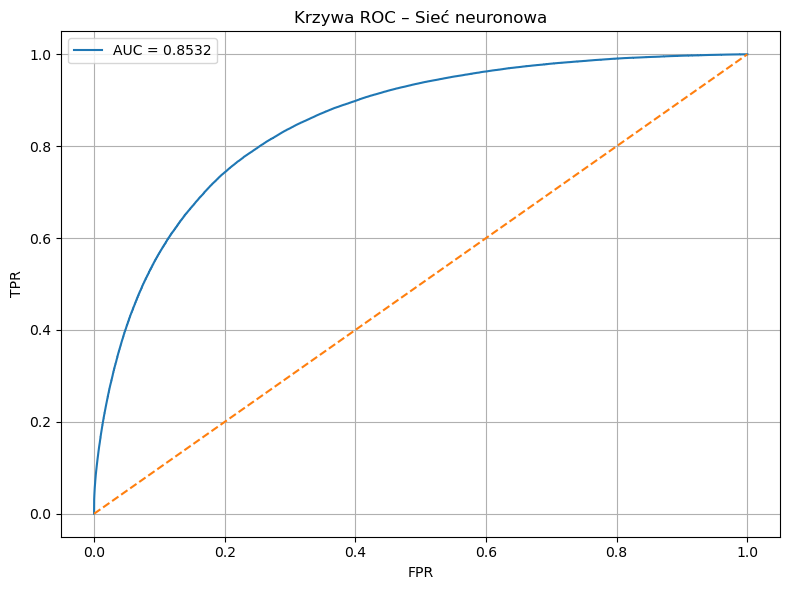

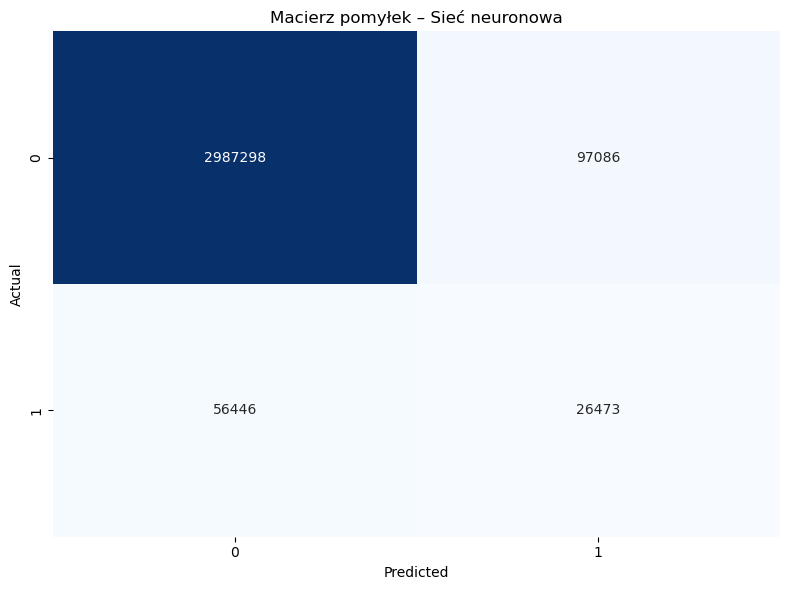

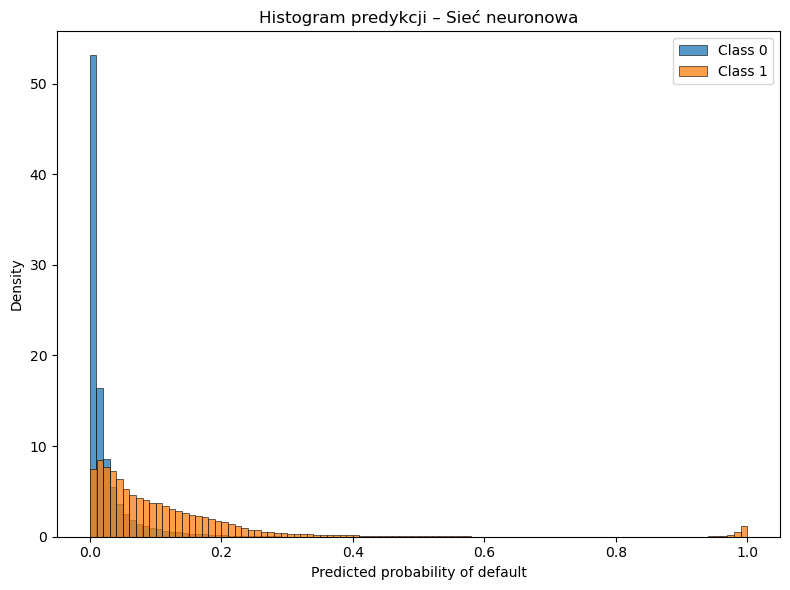

SHAP (DeepExplainer) ...


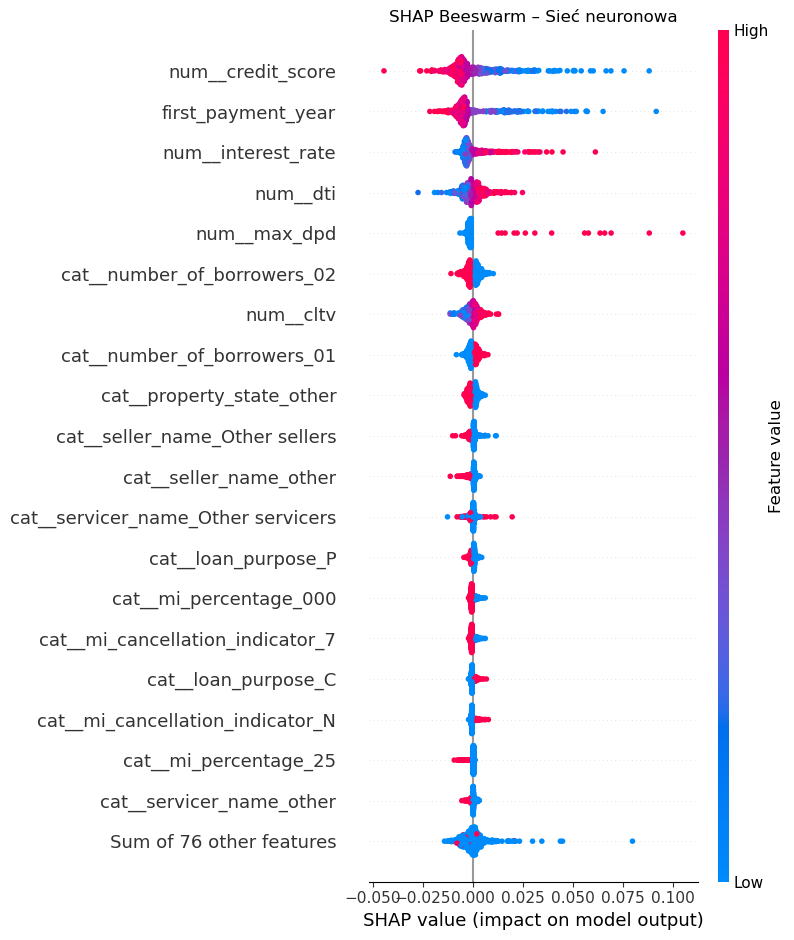

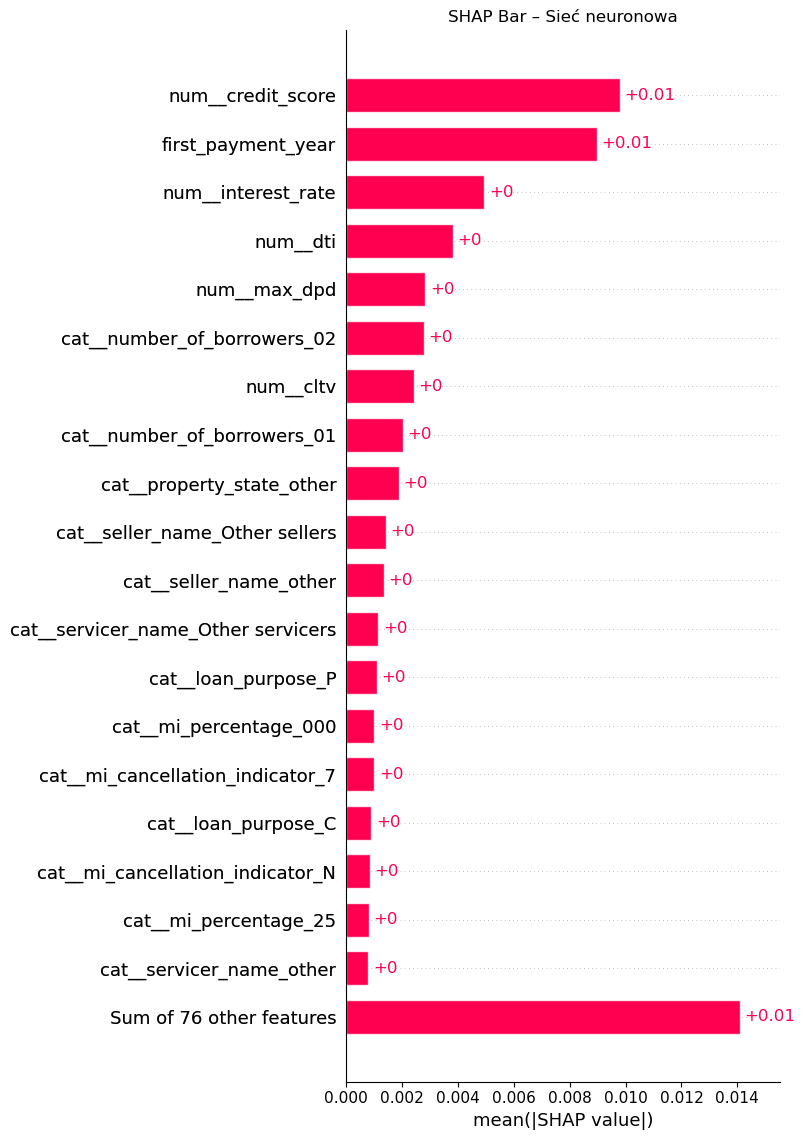

Top 5 wg mean(|SHAP|): ['num__credit_score', 'first_payment_year', 'num__interest_rate', 'num__dti', 'num__max_dpd']


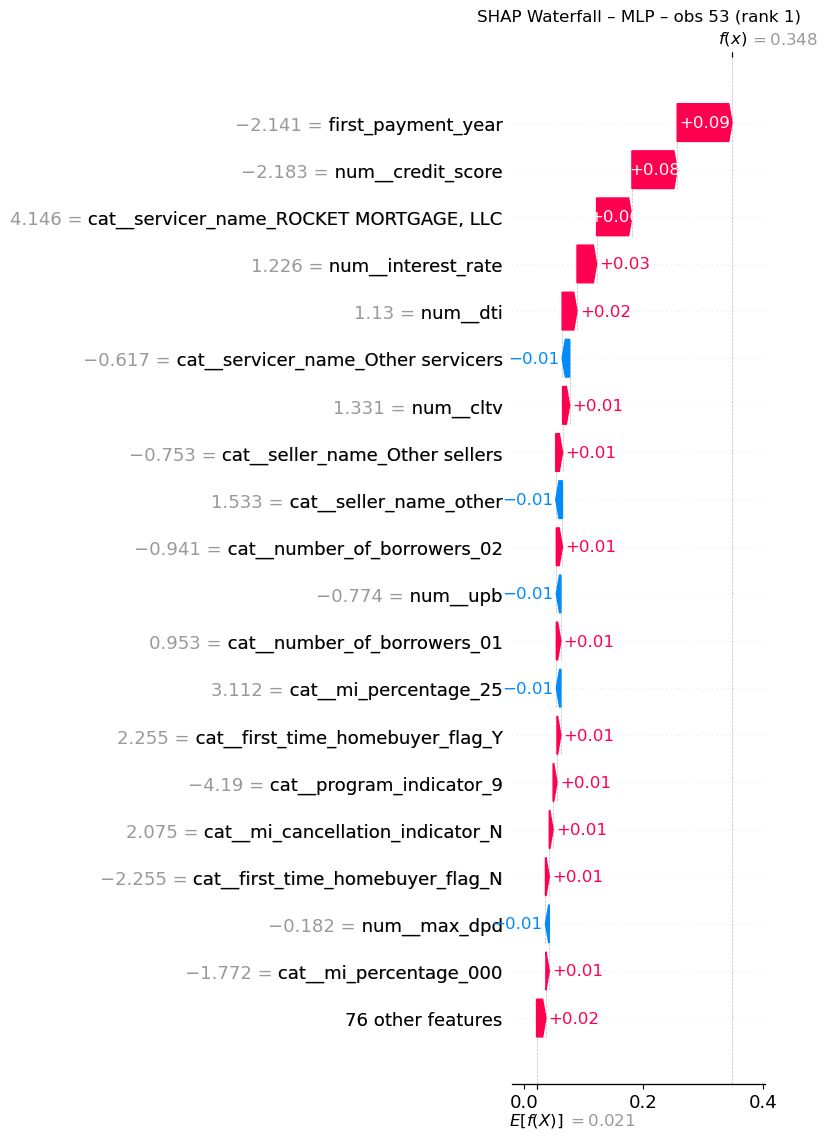

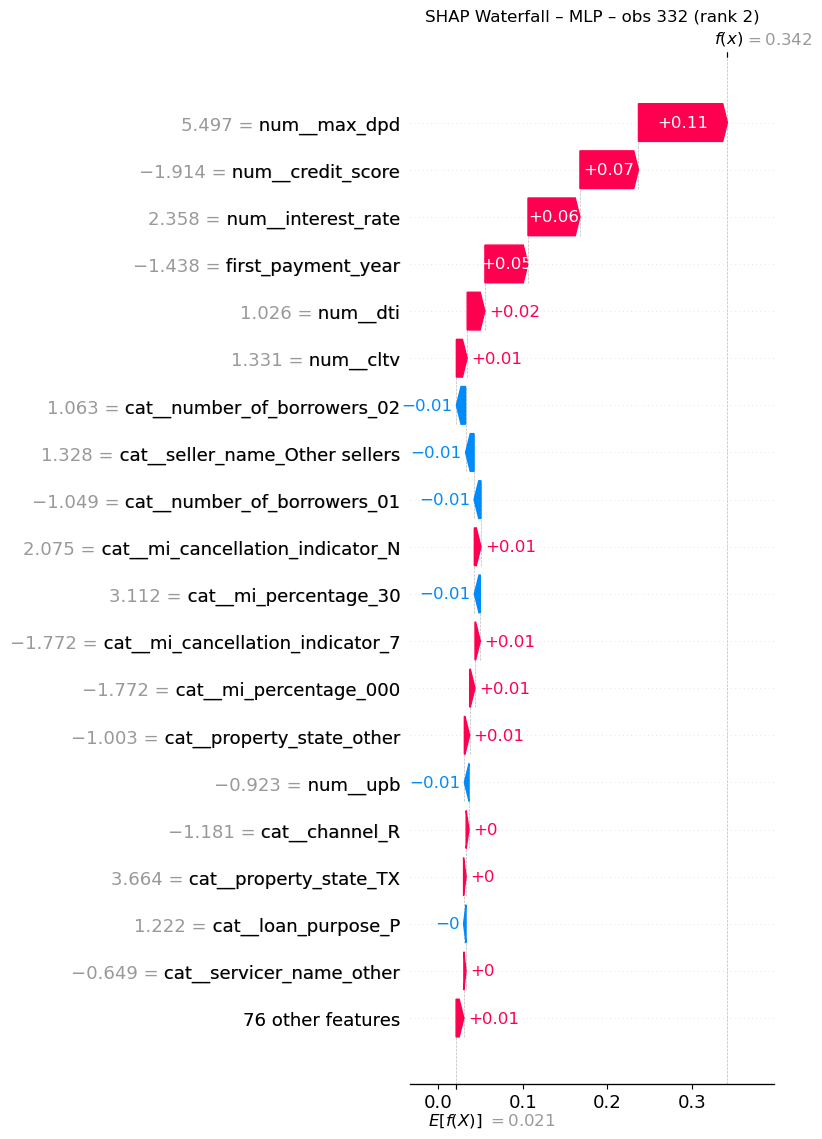

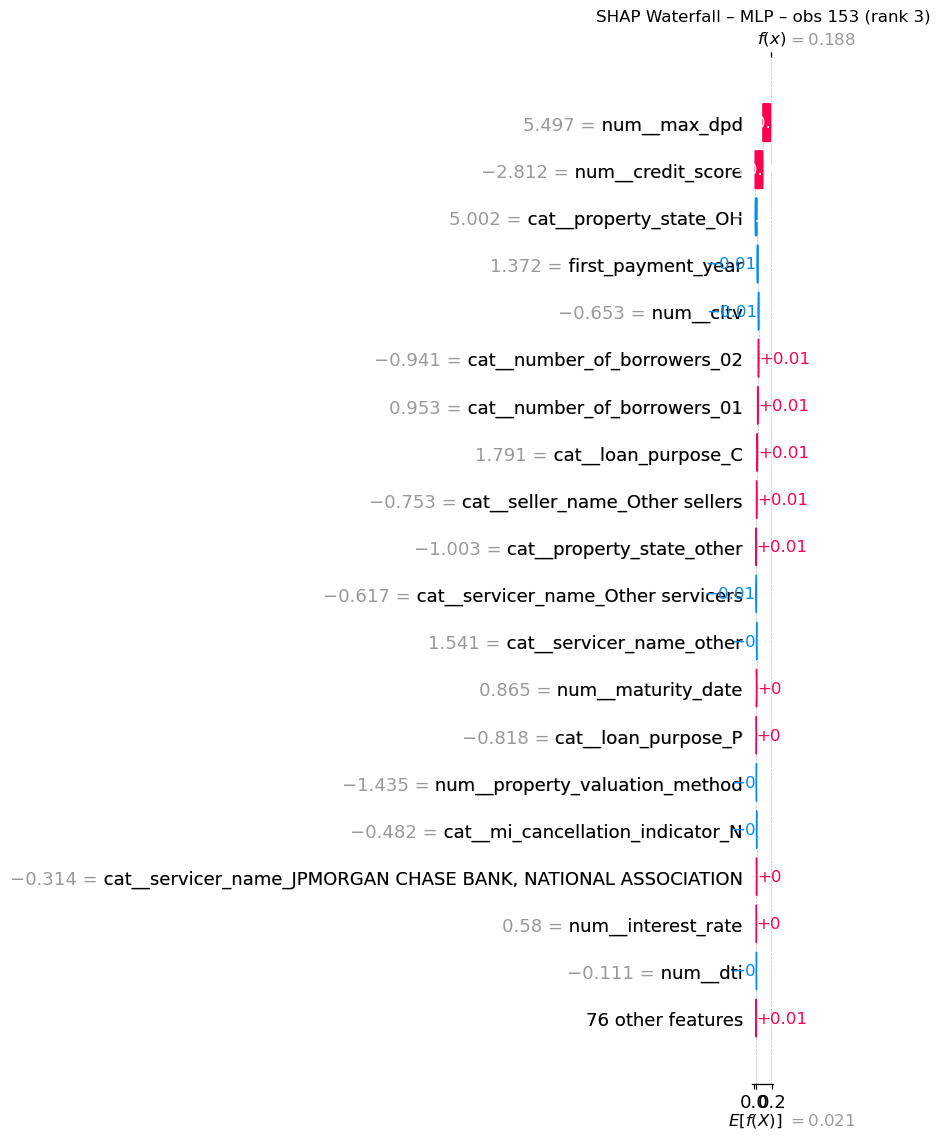

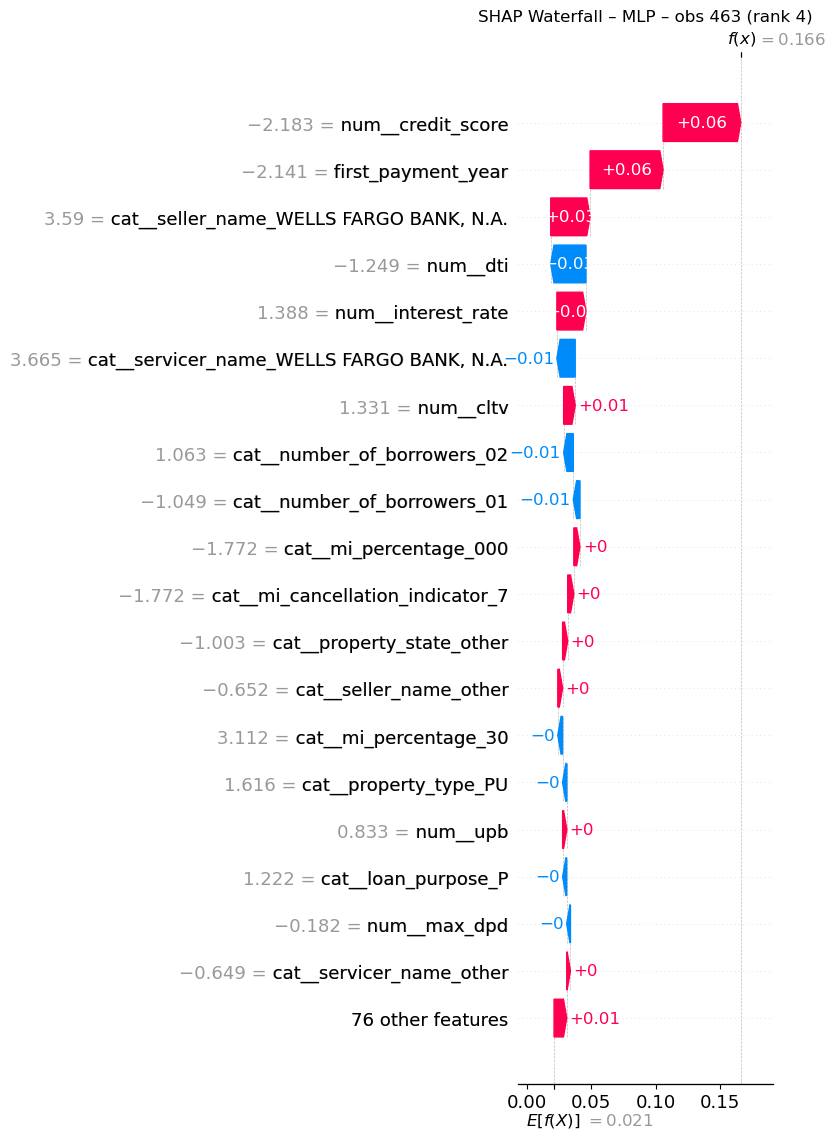

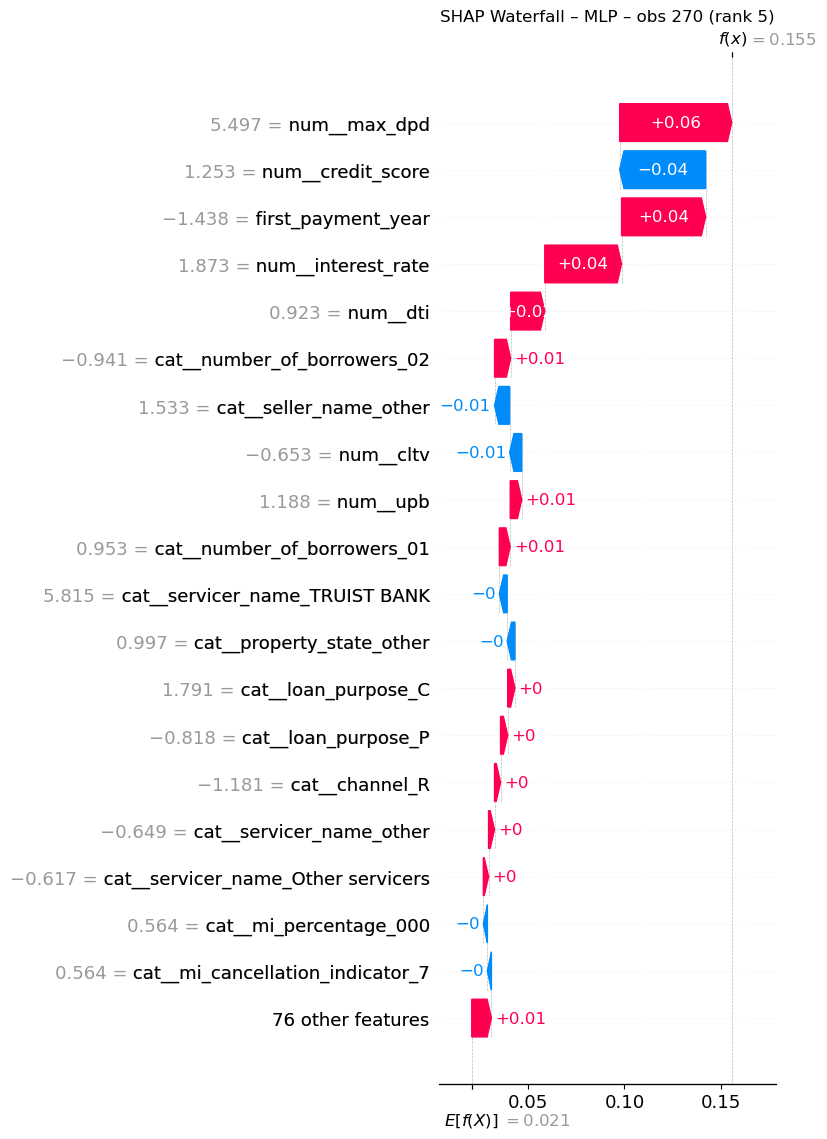

<Figure size 640x480 with 0 Axes>

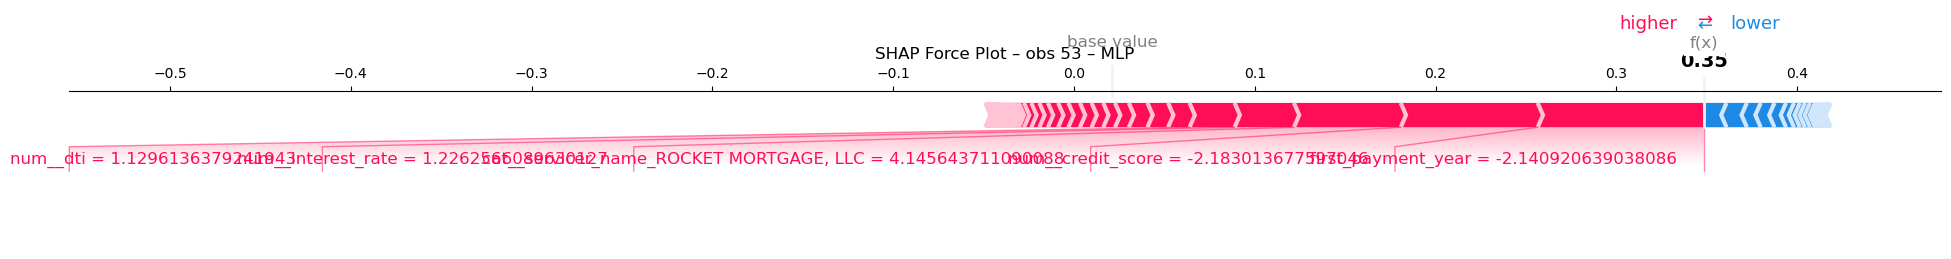

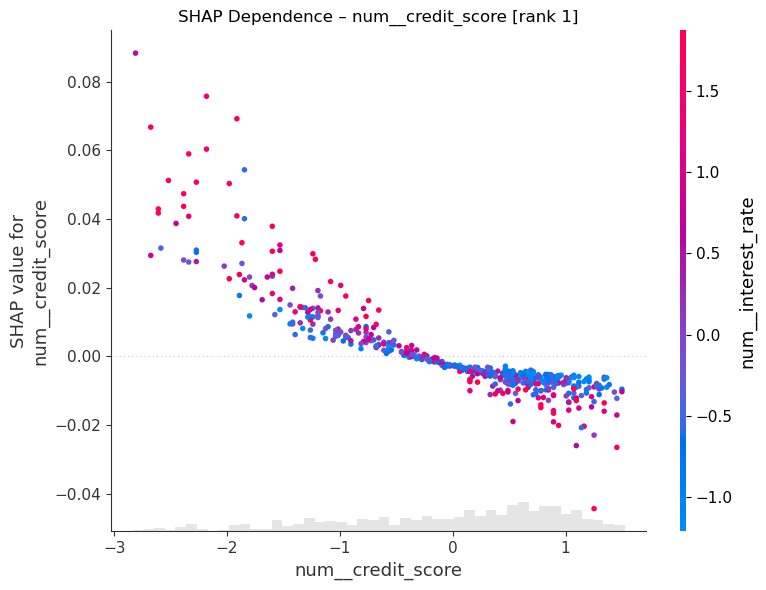

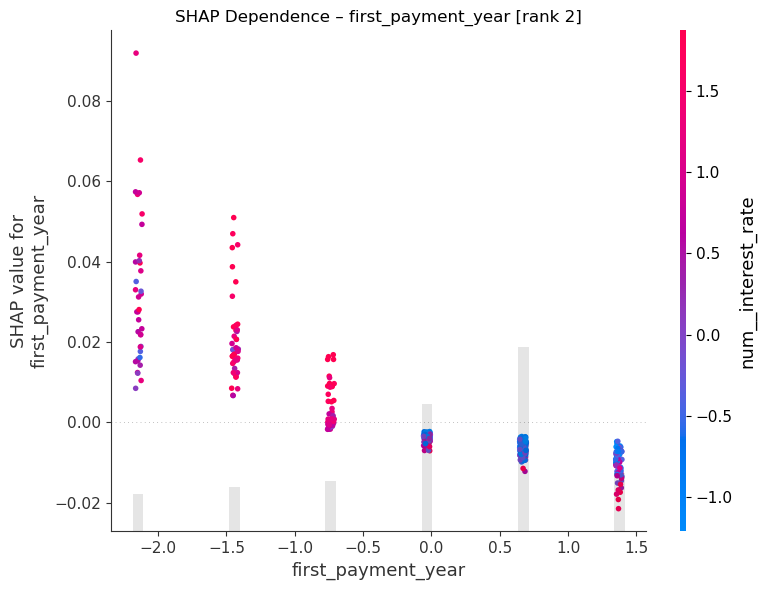

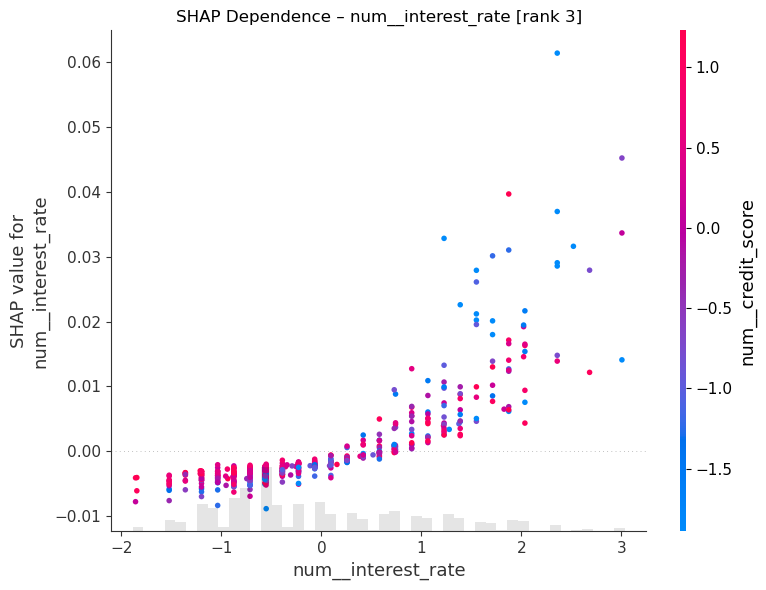

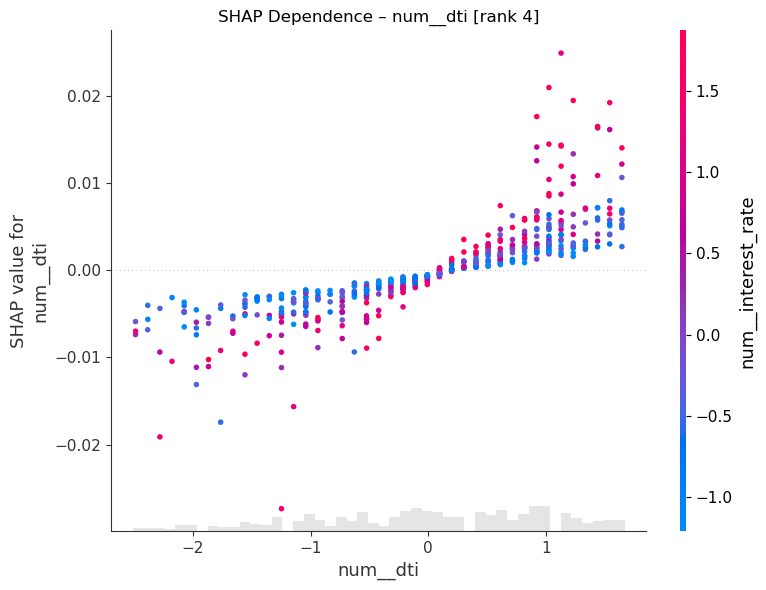

Pomijam dependence plot dla num__max_dpd – nienumeryczna/bin.
TOP_CONT: ['num__credit_score', 'num__interest_rate', 'num__dti']
TOP_CAT : []


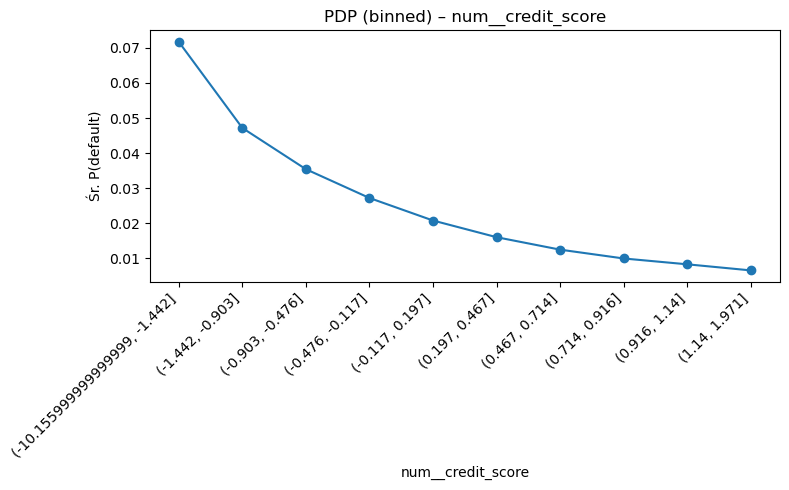

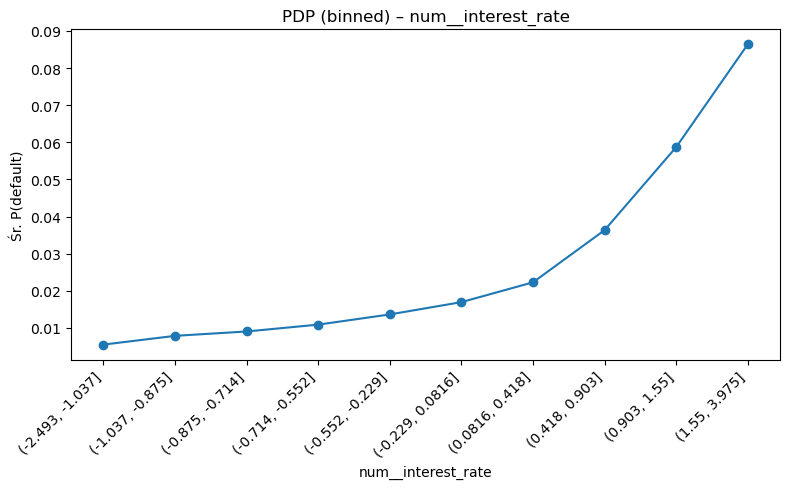

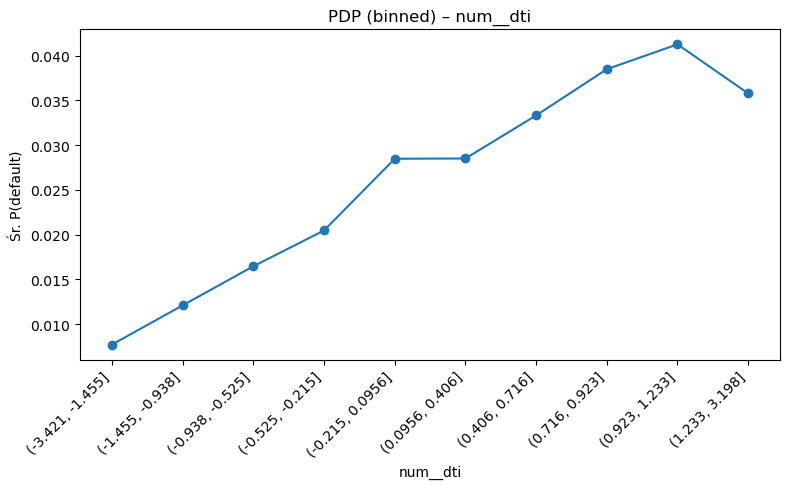

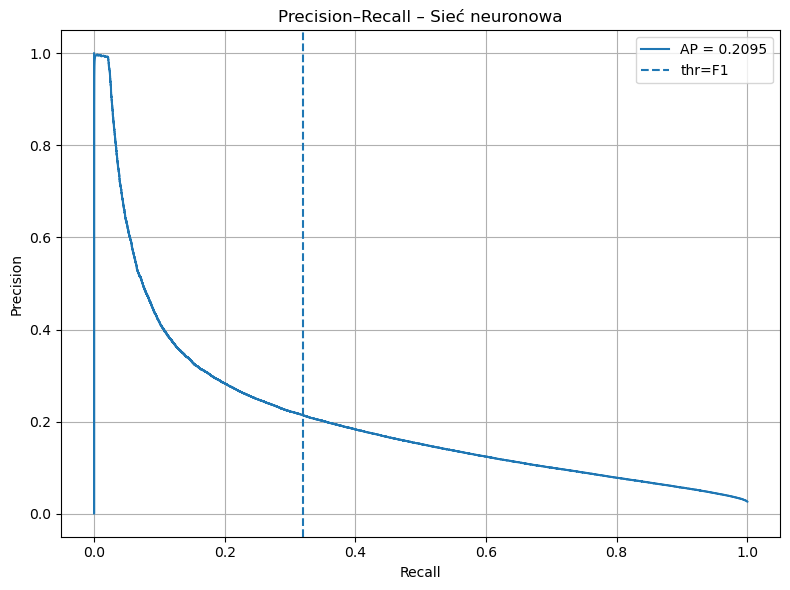

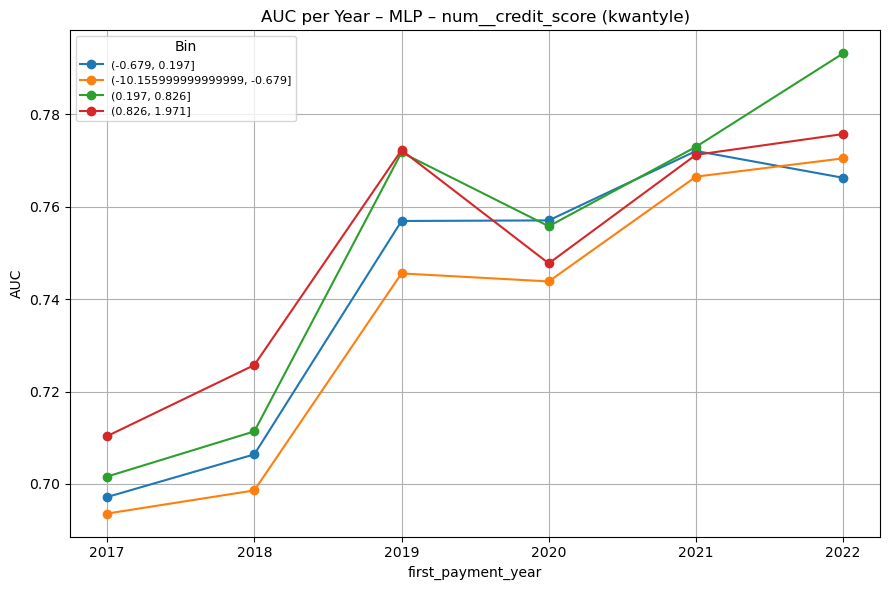

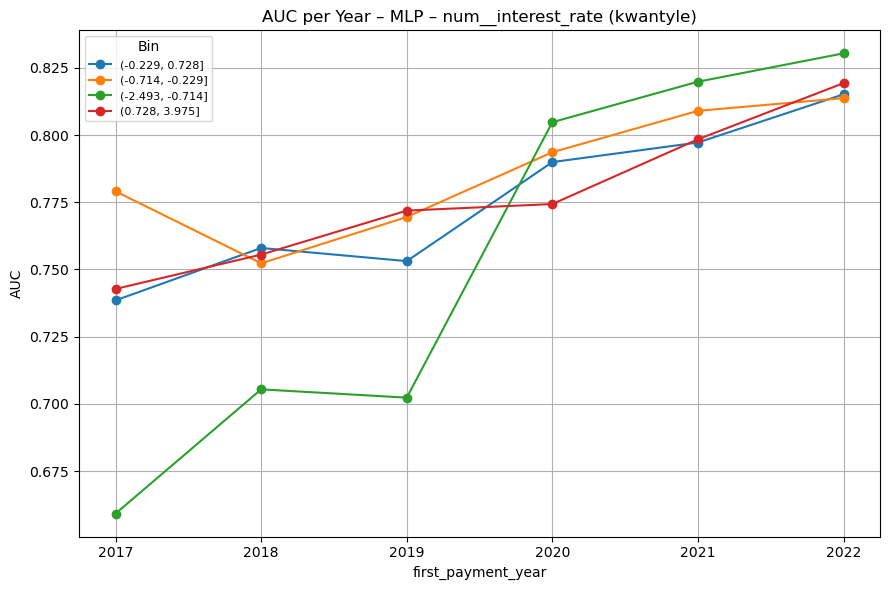

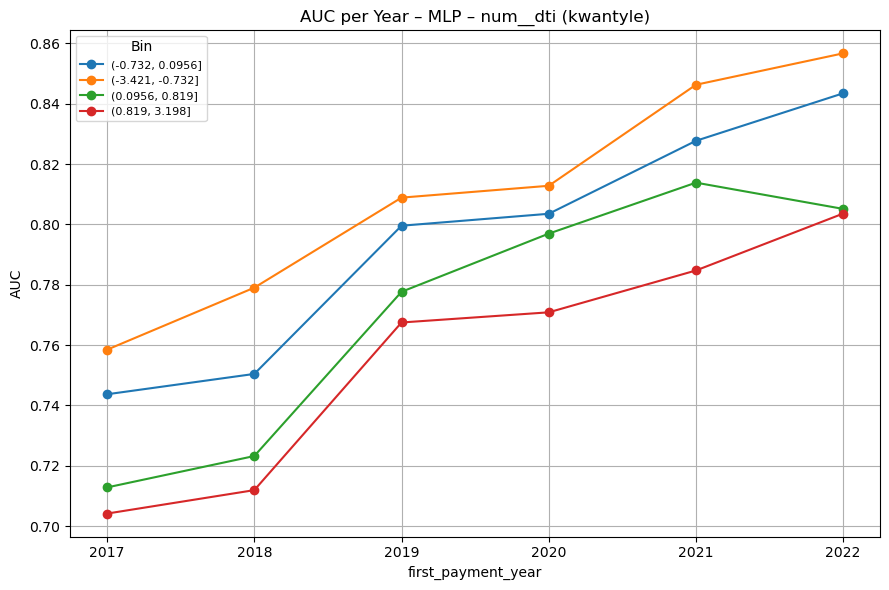

Perturbacja cech – start (MLP)
Perturbacja — cechy: ['num__credit_score', 'num__interest_rate', 'num__dti']


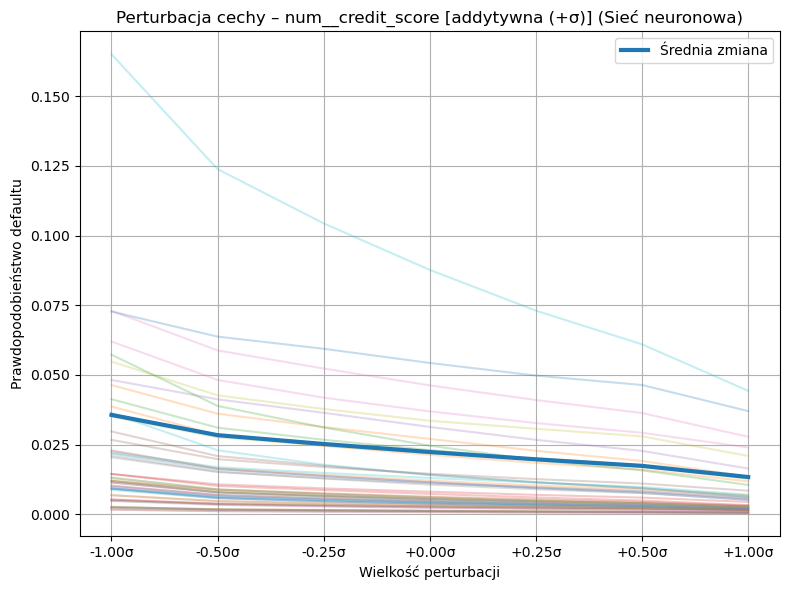

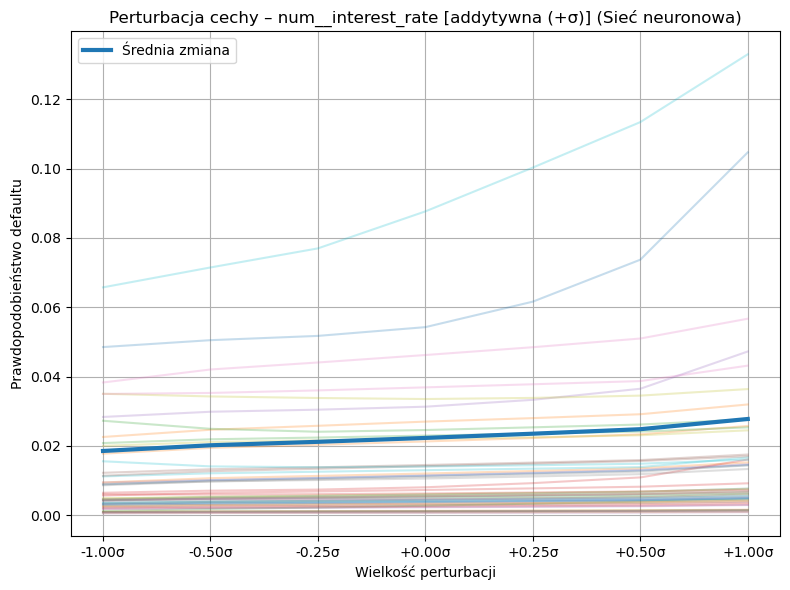

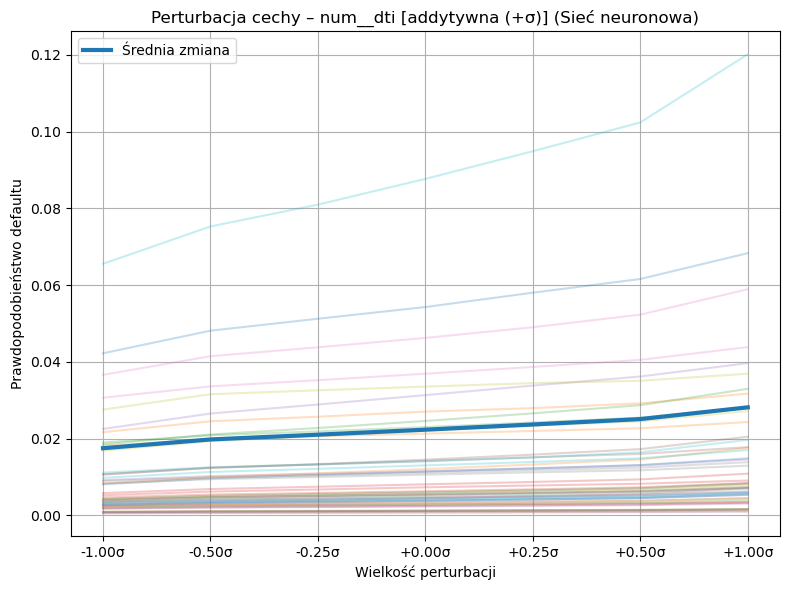

Zapisano: feature_perturbation_summary_mlp.csv


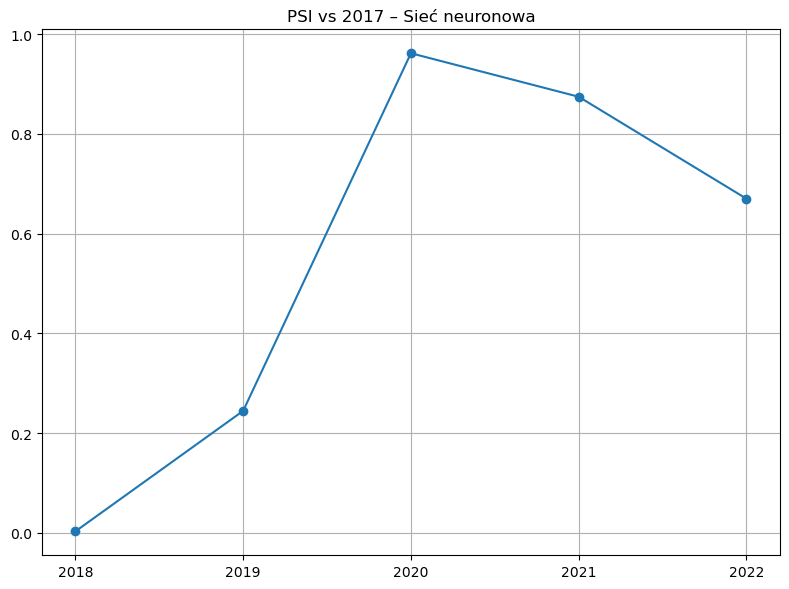

CSI (Top): bazowy rok vs bieżące dane – Sieć neuronowa
Rok bazowy dla CSI: 2017


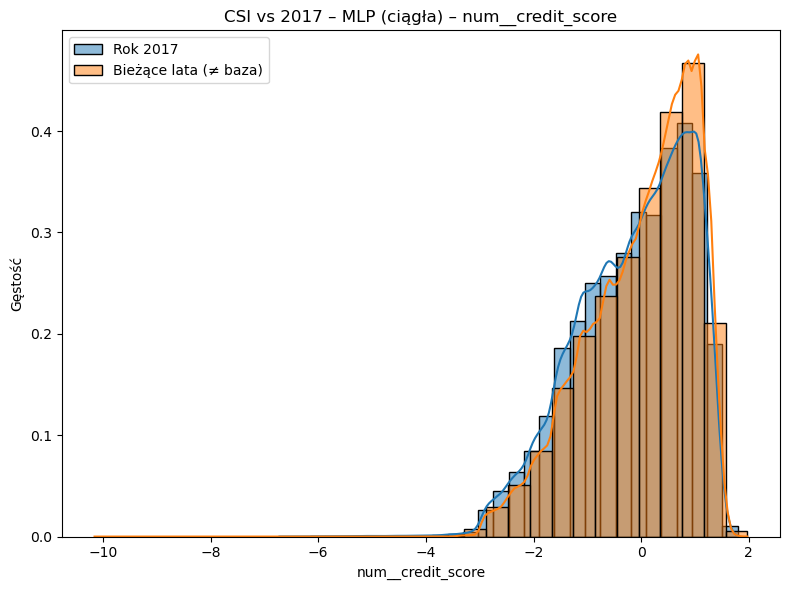

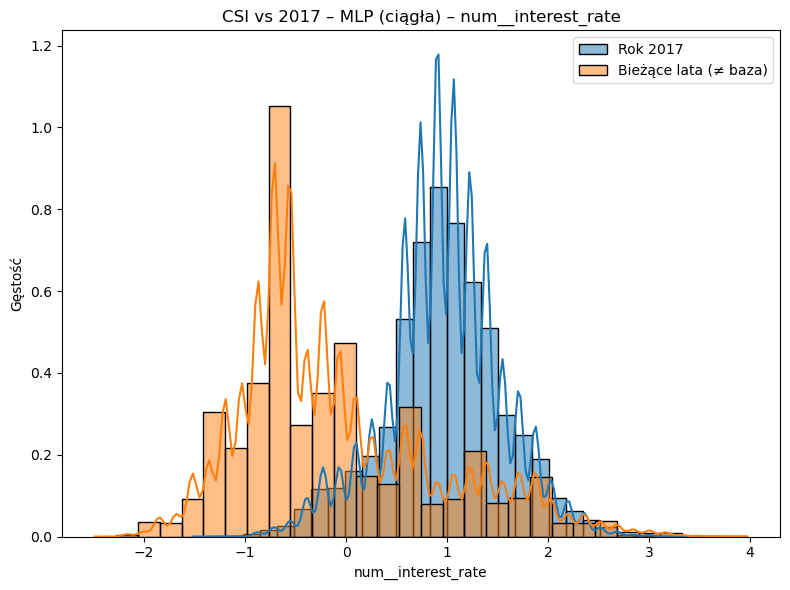

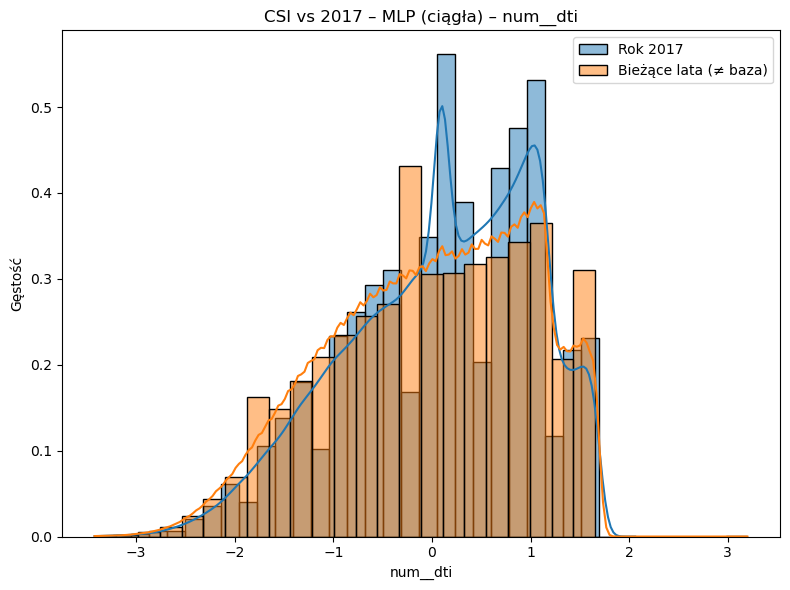

Permutation Importance ...


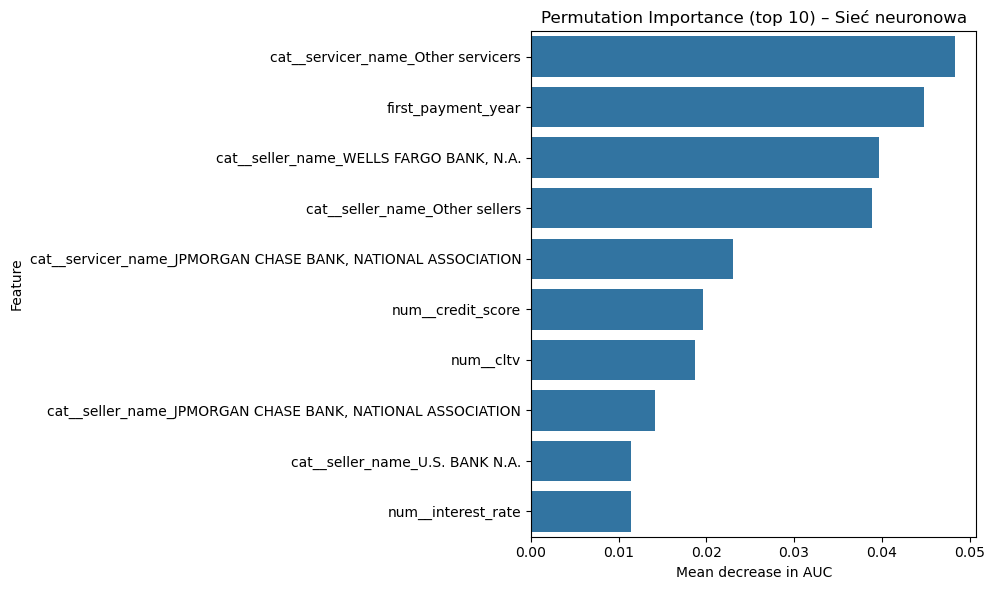

Analizy dla modelu sieci neuronowej zostały zapisane.


In [1]:
# ==============
# SIEĆ NEURONOWA
# ==============
import os, re, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf
from tensorflow.keras import Input, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

from sklearn.inspection import permutation_importance
from scikeras.wrappers import KerasClassifier

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

# Ścieżki
data_path  = ""
output_dir = os.path.join(data_path, "Wyniki_Siec_neuronowa")
os.makedirs(output_dir, exist_ok=True)

def _safe_fname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))

# Dane
train_data = pd.read_parquet(f"{data_path}/final_base_nn_logit_train.parquet")
test_data  = pd.read_parquet(f"{data_path}/final_base_nn_logit_test.parquet")

# Czyszczenie danych
X_train = train_data.drop(columns=[c for c in train_data.columns if "postal_code" in c.lower()] + ["default_flag"], errors="ignore")
y_train = train_data["default_flag"].astype(int)

X_test  = test_data.drop(columns=[c for c in test_data.columns if "postal_code" in c.lower()] + ["default_flag"], errors="ignore")
y_test  = test_data["default_flag"].astype(int)

# Daty
def yyyymm_to_year(col: pd.Series) -> pd.Series:
    return pd.to_datetime(col.astype(str), format="%Y%m", errors="coerce").dt.year.astype("Int64")

for df in (X_train, X_test):
    if "first_payment_date" in df.columns:
        df["first_payment_year"] = yyyymm_to_year(df["first_payment_date"])
    if "maturity_date" in df.columns:
        df["maturity_year"] = yyyymm_to_year(df["maturity_date"])
    df.drop(columns=["first_payment_date", "maturity_date",
                     "first_payment_date_dt", "maturity_date_dt"],
            inplace=True, errors="ignore")

# Podział typów zmiennych
numeric_features     = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
all_features         = numeric_features + categorical_features

# Preprocessing zmiennych
scaler  = StandardScaler().fit(X_train[numeric_features])

if categorical_features:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.float32)
    encoder.fit(X_train[categorical_features])
else:
    encoder = None

X_train_num = scaler.transform(X_train[numeric_features]).astype(np.float32, copy=False)
X_test_num  = scaler.transform(X_test[numeric_features]).astype(np.float32, copy=False)

if encoder is not None:
    X_train_cat = encoder.transform(X_train[categorical_features])
    X_test_cat  = encoder.transform(X_test[categorical_features])
else:
    X_train_cat = np.empty((len(X_train),0), dtype=np.float32)
    X_test_cat  = np.empty((len(X_test),0),  dtype=np.float32)

X_train_transformed = np.ascontiguousarray(np.hstack([X_train_num, X_train_cat]), dtype=np.float32)
X_test_transformed  = np.ascontiguousarray(np.hstack([X_test_num,  X_test_cat]),  dtype=np.float32)

# Model
def build_model(meta,
                hidden_layer_sizes=(256,128),
                activation="relu",
                alpha=1e-4,
                dropout=0.2,
                learning_rate=5e-4):
    n_features = meta["n_features_in_"]
    m = Sequential()
    m.add(Input(shape=(n_features,)))
    m.add(Dense(hidden_layer_sizes[0], activation=activation,
                kernel_regularizer=regularizers.l2(alpha)))
    if dropout and dropout > 0: m.add(Dropout(dropout))
    for units in hidden_layer_sizes[1:]:
        m.add(Dense(units, activation=activation,
                    kernel_regularizer=regularizers.l2(alpha)))
        if dropout and dropout > 0: m.add(Dropout(dropout))
    m.add(Dense(1, activation="sigmoid"))
    m.compile(optimizer=Adam(learning_rate=learning_rate),
              loss="binary_crossentropy",
              metrics=["AUC"])
    return m

base_clf = KerasClassifier(
    model=build_model,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=6, restore_best_weights=True, min_delta=1e-4),
               ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)],
    verbose=0,
    random_state=42
)

param_dist = {
    "model__hidden_layer_sizes": [(128,), (256,), (128,64), (256,128)],
    "model__activation": ["relu", "elu"],
    "model__alpha": [1e-4, 3e-4, 1e-3],
    "model__dropout": [0.0, 0.2],
    "model__learning_rate": [7e-4, 5e-4, 3e-4],
    "batch_size": [512, 1024, 2048],
    "epochs": [20, 30, 40],
}

rs = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring="roc_auc",
    n_jobs=1,
    verbose=2,
    refit=False
)

tf.keras.backend.clear_session(); gc.collect()
rs.fit(X_train_transformed, y_train)

best = rs.best_params_
tf.keras.backend.clear_session(); gc.collect()

clf_best = KerasClassifier(
    model=build_model,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=6, restore_best_weights=True, min_delta=1e-4),
               ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)],
    verbose=0,
    random_state=42,
    batch_size=best["batch_size"],
    epochs=best["epochs"],
    model__hidden_layer_sizes=best["model__hidden_layer_sizes"],
    model__activation=best["model__activation"],
    model__alpha=best["model__alpha"],
    model__dropout=best["model__dropout"],
    model__learning_rate=best["model__learning_rate"],
)
clf_best.fit(X_train_transformed, y_train)

# Ewaluacja
y_pred_proba = clf_best.predict_proba(X_test_transformed)[:, 1]

prec, rec, thr = precision_recall_curve(y_test, y_pred_proba)
f1 = 2 * (prec * rec) / np.maximum(prec + rec, 1e-12)
best_f1_idx = int(np.nanargmax(f1))
best_thr = thr[max(0, best_f1_idx-1)] if best_f1_idx < len(thr) else 0.5
print(f"Wybrany próg (F1): {best_thr:.4f}")
y_pred = (y_pred_proba >= best_thr).astype(int)

f1_val = f1_score(y_test, y_pred)
prec_at_thr = precision_score(y_test, y_pred)
rec_at_thr  = recall_score(y_test, y_pred)
print(f"F1={f1_val:.4f}, P={prec_at_thr:.4f}, R={rec_at_thr:.4f}")

print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("Macierz pomyłek:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Zapis predykcji do CSV
pred_out = X_test.copy()
pred_out["pred_prob"] = y_pred_proba
pred_out["pred_label"] = y_pred
pred_out["y_true"] = y_test.values
pred_out["decision_threshold_f1"] = best_thr

out_csv = os.path.join(output_dir, "test_with_predictions_mlp.csv")
pred_out.to_csv(out_csv, index=False)
print("Zapisano predykcje do:", out_csv)

#====
# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.4f}")
plt.plot([0,1],[0,1],"--")
plt.title("Krzywa ROC – Sieć neuronowa"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve_mlp.png"); 
plt.show() 
plt.close()

#=================
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Macierz pomyłek – Sieć neuronowa")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.savefig(f"{output_dir}/confusion_matrix_mlp.png"); 
plt.show()
plt.close()

#====================
# Histogram predykcji
plt.figure(figsize=(8,6))
sns.histplot(y_pred_proba[y_test == 0], stat="density", bins=100, label="Class 0")
sns.histplot(y_pred_proba[y_test == 1], stat="density", bins=100, label="Class 1")
plt.title("Histogram predykcji – Sieć neuronowa")
plt.xlabel("Predicted probability of default"); plt.ylabel("Density")
plt.legend(); plt.tight_layout()
plt.savefig(f"{output_dir}/prediction_hist_mlp.png"); 
plt.show()
plt.close()

# ====================
# SHAP (DeepExplainer)
print("SHAP (DeepExplainer) ...")
sample_size = min(500, X_test_transformed.shape[0])
rng = np.random.RandomState(42)
bg_n = min(200, X_train_transformed.shape[0])
bg_idx = rng.choice(X_train_transformed.shape[0], size=bg_n, replace=False)
background = X_train_transformed[bg_idx]

explainer = shap.DeepExplainer(clf_best.model_, background)
raw = explainer.shap_values(X_test_transformed[:sample_size])

shap_arr = raw[0] if isinstance(raw, list) else raw
shap_arr = np.asarray(shap_arr)
if shap_arr.ndim == 3 and shap_arr.shape[-1] == 1:
    shap_arr = shap_arr[..., 0]

X_shap = X_test_transformed[:sample_size]
if shap_arr.shape == X_shap.shape:
    ev = explainer.expected_value
    if isinstance(ev, (list, tuple, np.ndarray)):
        ev = np.asarray(ev)
        ev = ev[0] if ev.ndim > 0 else float(ev)
    base_vec = np.full((shap_arr.shape[0],), float(ev))

    shap_exp = shap.Explanation(values=shap_arr, base_values=base_vec,
                                data=X_shap, feature_names=all_features)

    # Beeswarm plot
    plt.figure()
    shap.plots.beeswarm(shap_exp, max_display=20, show=False)
    plt.title("SHAP Beeswarm – Sieć neuronowa"); plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_beeswarm_siec_neuronowa.png");
    plt.show()
    plt.close()

    # Bar plot
    plt.figure()
    shap.plots.bar(shap_exp, max_display=20, show=False)
    plt.title("SHAP Bar – Sieć neuronowa"); plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_bar_siec_neuronowa.png"); 
    plt.show()
    plt.close()

    # Top-5 cech wg mean(|SHAP|)
    vals = np.asarray(shap_exp.values)
    mean_abs = np.nanmean(np.abs(vals), axis=0)
    top5_idx = np.argsort(mean_abs)[::-1][:5]
    top_vars = [shap_exp.feature_names[i] for i in top5_idx]
    print("Top 5 wg mean(|SHAP|):", top_vars)
else:
    print(f"[UWAGA] SHAP ma kształt {shap_arr.shape}, dane {X_shap.shape} – pominięcie wizualizacji.")
    top_vars = []

if "shap_exp" in locals():
    impact = np.abs(shap_exp.values).sum(axis=1)
    idx_sorted = np.argsort(impact)[::-1]
    idx_keep = [int(i) for i in idx_sorted if np.isfinite(impact[int(i)]) and impact[int(i)] > 1e-12][:5]

    # Waterfall plot
    for rank, idx in enumerate(idx_keep, start=1):
        try:
            plt.figure()
            shap.plots.waterfall(shap_exp[idx], max_display=20, show=False)
            plt.title(f"SHAP Waterfall – MLP – obs {idx} (rank {rank})")
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f"shap_waterfall_rank{rank}_obs{idx}_mlp.png"), dpi=150)
            plt.show()
            plt.close()
        except Exception as e:
            print(f"Błąd waterfall plot dla obs {idx}: {e}")

    # Force plot (pierwsza z Top-5)
    try:
        if len(idx_keep) > 0:
            plt.figure()
            shap.plots.force(shap_exp[idx_keep[0]], matplotlib=True, show=False)
            plt.title(f"SHAP Force Plot – obs {idx_keep[0]} – MLP")
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f"shap_force_obs{idx_keep[0]}_mlp.png"), dpi=150)
            plt.show()
            plt.close()
    except Exception as e:
        print(f"Błąd force plot: {e}")

    # SHAP Dependence
    for rank, var in enumerate(top_vars, start=1):
        if var not in X_test.columns: 
            continue
        if (not pd.api.types.is_numeric_dtype(X_test[var])) or (X_test[var].nunique() <= 2):
            print(f"Pominięcie dependence plot dla {var} – nienumeryczna/bin.")
            continue
        try:
            fig, ax = plt.subplots(figsize=(8,6))
            shap.plots.scatter(shap_exp[:, var], color=shap_exp, show=False, ax=ax)
            ax.set_title(f"SHAP Dependence – {var} [rank {rank}]")
            fig.tight_layout()
            fig.savefig(f"{output_dir}/shap_dependence_rank{rank}_{_safe_fname(var)}_siec_neuronowa.png")
            plt.show()
            plt.close(fig)
        except Exception as e:
            print(f"Błąd dependence plot dla {var}: {e}")
else:
    print("Pominięto waterfall/force/dependence – SHAP Explanation niedostępny.")


# ===========================
# Listy zmiennych do wykresów
_EXCLUDE_NAME_TOKENS = ["msa","zip","postal","code","id","year","month","date","day","days_since","number_of_borrowers"]
_EXCLUDE_EXACT = {"first_payment_year"}

def _is_name_excluded(name: str) -> bool:
    n = str(name).lower()
    if n in _EXCLUDE_EXACT: return True
    return any(tok in n for tok in _EXCLUDE_NAME_TOKENS)

def _is_dummy01(s: pd.Series) -> bool:
    u = pd.Series(s.dropna().unique())
    return (len(u) > 0) and u.isin([0,1]).all()

SAFE_CAT_FEATURES = categorical_features[:]
SAFE_CONT_FEATURES = [
    c for c in numeric_features
    if c not in {"first_payment_year", "maturity_year"}
    and not _is_name_excluded(c)
    and pd.api.types.is_numeric_dtype(X_test[c])
    and not _is_dummy01(X_test[c])
    and X_test[c].nunique(dropna=True) >= 3
]

TOP_ALL  = [c for c in top_vars if c in X_test.columns] if len(top_vars) else []
TOP_CONT = [c for c in TOP_ALL if c in SAFE_CONT_FEATURES]
TOP_CAT  = [c for c in TOP_ALL if c in SAFE_CAT_FEATURES]

if len(TOP_CONT) == 0: TOP_CONT = SAFE_CONT_FEATURES[:5]
if len(TOP_CAT)  == 0: TOP_CAT  = SAFE_CAT_FEATURES[:5]

print("TOP_CONT:", TOP_CONT[:10])
print("TOP_CAT :", TOP_CAT[:10])

# ===================================
# PDP (binned) dla zmiennych ciągłych
vars_for_pdp = TOP_CONT[:5] if len(TOP_CONT)>0 else SAFE_CONT_FEATURES[:5]
for var in vars_for_pdp:
    try:
        bins = pd.qcut(X_test[var], q=10, duplicates="drop")
        df_tmp = pd.DataFrame({var: bins, "pred": y_pred_proba}).dropna()
        if df_tmp.empty or df_tmp[var].nunique() < 2: 
            print(f"PDP: pominięcie {var} – za mało danych.")
            continue
        grouped = df_tmp.groupby(var, observed=False)["pred"].mean().reset_index()
        plt.figure(figsize=(8,5))
        plt.plot(grouped[var].astype(str), grouped["pred"], marker="o")
        plt.title(f"PDP (binned) – {var}")
        plt.xlabel(var); plt.ylabel("Śr. P(default)")
        plt.xticks(rotation=45, ha="right"); plt.tight_layout()
        plt.savefig(f"{output_dir}/pdp_binned_{_safe_fname(var)}_siec_neuronowa.png"); 
        plt.show()
        plt.close()
    except Exception as e:
        print(f"PDP: błąd dla {var}: {e}")

# ===============
# PDP – kategorie
max_levels = 20
vars_for_pdp_cat = TOP_CAT[:5] if len(TOP_CAT)>0 else SAFE_CAT_FEATURES[:5]
for var in vars_for_pdp_cat:
    try:
        dfc = pd.DataFrame({var: X_test[var], "pred": y_pred_proba}).dropna()
        if dfc.empty:
            print(f"PDP (zmienne kategoryczne): pominięta zmienna {var} – brak danych.")
            continue
        top_levels = dfc[var].value_counts().head(max_levels).index
        dfc = dfc[dfc[var].isin(top_levels)]
        if dfc[var].nunique() < 2:
            print(f"PDP (zmienne kategoryczne): pominięta zmienna {var} – 1 kategoria po filtrze.")
            continue
        grouped = dfc.groupby(var, observed=False)["pred"].mean().sort_values(ascending=False)
        ax = grouped.plot(kind="bar", figsize=(9,6))
        ax.set_title(f"PDP (kategorie) – {var}")
        ax.set_xlabel(var); ax.set_ylabel("Śr. P(default)")
        plt.tight_layout(); plt.savefig(os.path.join(output_dir, f"pdp_cat_{_safe_fname(var)}_siec_neuronowa.png")); plt.close()
    except Exception as e:
        print(f"PDP (zmienne kategoryczne): błąd dla {var}: {e}")

# ================
# Precision–Recall
prec, rec, thr = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.axvline(rec[max(0, best_f1_idx-1)], linestyle="--", label="thr=F1")
plt.title("Precision–Recall – Sieć neuronowa")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig(f"{output_dir}/precision_recall_curve_mlp.png"); 
plt.show() 
plt.close()

# =============
# Eksport FP/FN
errors_df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred, "y_pred_proba": y_pred_proba}, index=X_test.index)
errors_df["error_type"] = np.select(
    [(errors_df["y_true"]==1)&(errors_df["y_pred"]==0),
     (errors_df["y_true"]==0)&(errors_df["y_pred"]==1)],
    ["FN","FP"], default="OK"
)
errors_df.to_csv(os.path.join(output_dir, "errors_fp_fn_mlp.csv"), index=True)

# ============
# AUC per year
def _safe(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_\-+=]+", "_", str(s))

df_base = X_test.copy()
df_base["y_proba"] = y_pred_proba
df_base["y_true"]  = y_test.values
if "first_payment_year" not in df_base.columns:
    raise RuntimeError("Brak 'first_payment_year' w X_test.")
df_base["first_payment_year"] = pd.to_numeric(df_base["first_payment_year"], errors="coerce").astype("Int64")

nbins, min_group = 4, 30
for feat in TOP_CONT:
    if feat not in df_base.columns: 
        continue
    df = df_base[["first_payment_year", feat, "y_true", "y_proba"]].dropna().copy()
    try:
        df["bin"] = pd.qcut(df[feat], q=nbins, duplicates="drop")
    except Exception:
        print(f"Pominięcie {feat} – za mało unikalnych wartości do qcut.")
        continue
    rows = []
    for (yr, b), g in df.groupby(["first_payment_year","bin"], observed=False):
        if pd.isna(yr) or len(g) < min_group or g["y_true"].nunique() < 2: 
            continue
        auc = roc_auc_score(g["y_true"], g["y_proba"])
        rows.append({"year": int(yr), "bin": str(b), "AUC": float(auc)})
    if not rows:
        print(f"Brak danych do AUC per year dla {feat}."); continue
    res = pd.DataFrame(rows).sort_values(["year","bin"])
    safe = _safe(feat)
    res.to_csv(f"{output_dir}/auc_per_year_by_bin_{safe}_mlp.csv", index=False)
    pivot = res.pivot(index="year", columns="bin", values="AUC").sort_index()
    plt.figure(figsize=(9,6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=str(col))
    plt.title(f"AUC per Year – MLP – {feat} (kwantyle)")
    plt.xlabel("first_payment_year"); plt.ylabel("AUC")
    plt.grid(True); plt.legend(title="Bin", fontsize=8); plt.tight_layout()
    plt.savefig(f"{output_dir}/auc_per_year_by_bin_{safe}_mlp.png"); 
    plt.show()
    plt.close()

#===============
# Boxploty FP/FN
plot_df = errors_df.loc[errors_df["error_type"].isin(["FP","FN"])]
for var in TOP_CONT:
    try:
        df_plot = pd.concat([plot_df[["error_type"]], X_test[[var]]], axis=1)
        nunq = df_plot[var].dropna().nunique()
        if nunq < 3:
            print(f"Pominięcie {var} – za mało unikalnych wartości ({nunq})."); continue
        fig, ax = plt.subplots(figsize=(8,6))
        sns.boxplot(data=df_plot, x="error_type", y=var, order=["FN","FP"], ax=ax)
        ax.set_title(f"Boxplot {var} – FP vs FN"); ax.set_xlabel("Typ błędu"); ax.set_ylabel(var)
        fig.tight_layout(); fig.savefig(os.path.join(output_dir, f"boxplot_fpfn_{_safe_fname(var)}_mlp.png"), dpi=150); plt.close(fig)
    except Exception as e:
        print(f"Błąd boxplotu dla {var}: {e}")

# ================
# Perturbacja cech
print("Perturbacja cech – sieć neuronowa")

PERTURB_TOP_N   = 5
PERCENT_DELTAS  = np.array([-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20])
STD_STEPS       = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
SAMPLE_ROWS     = 200
SHOW_N_LINES    = 50

if not TOP_CONT:
    print("Uwaga: TOP_CONT puste — brak cech do perturbacji.")
    FEATURES_FOR_PERTURB = []
else:
    FEATURES_FOR_PERTURB = TOP_CONT[:PERTURB_TOP_N]

print("Perturbacja — cechy:", FEATURES_FOR_PERTURB)

base_idx = X_test.index[:min(SAMPLE_ROWS, len(X_test))]
X_base_all = X_test.loc[base_idx].copy()

perturb_summary_rows = []

for var in FEATURES_FOR_PERTURB:
    try:
        if var not in X_base_all.columns:
            print(f"Pominięta zmienna {var} — brak w X_test.")
            continue

        x = X_base_all[var].copy()
        x_nonan = x.dropna()
        if x_nonan.empty:
            print(f"Pominięta zmienna {var} — same NaN.")
            continue

        # Reguła: dodatnie: mnożnik %, inaczej kroki σ
        use_multiplicative = (x_nonan.min() > 0) and (np.nanmedian(x_nonan) > 1e-12)
        preds_grid, labels = [], []

        if use_multiplicative:
            for d in PERCENT_DELTAS:
                Xp = X_base_all.copy()
                Xp.loc[x_nonan.index, var] = x_nonan * (1.0 + d)

                # Transformacja num+cat
                Xp_num = scaler.transform(Xp[numeric_features])
                if encoder is not None and categorical_features:
                    Xp_cat = encoder.transform(Xp[categorical_features])
                else:
                    Xp_cat = np.empty((len(Xp),0), dtype=np.float32)
                Xt = np.ascontiguousarray(np.hstack([Xp_num, Xp_cat]), dtype=np.float32)
                
                y_pred = clf_best.predict_proba(Xt)[:, 1]
                preds_grid.append(y_pred)
                labels.append(f"{int(d*100)}%")
        else:
            std = float(np.nanstd(x_nonan))
            if not np.isfinite(std) or std < 1e-12:
                for d in PERCENT_DELTAS:
                    Xp = X_base_all.copy()
                    Xp.loc[x_nonan.index, var] = x_nonan * (1.0 + d)

                    Xp_num = scaler.transform(Xp[numeric_features])
                    if encoder is not None and categorical_features:
                        Xp_cat = encoder.transform(Xp[categorical_features])
                    else:
                        Xp_cat = np.empty((len(Xp),0), dtype=np.float32)
                    Xt = np.ascontiguousarray(np.hstack([Xp_num, Xp_cat]), dtype=np.float32)

                    y_pred = clf_best.predict_proba(Xt)[:, 1]
                    preds_grid.append(y_pred)
                    labels.append(f"{int(d*100)}%")
                use_multiplicative = True
            else:
                for s in STD_STEPS:
                    Xp = X_base_all.copy()
                    Xp.loc[x_nonan.index, var] = x_nonan + s * std

                    Xp_num = scaler.transform(Xp[numeric_features])
                    if encoder is not None and categorical_features:
                        Xp_cat = encoder.transform(Xp[categorical_features])
                    else:
                        Xp_cat = np.empty((len(Xp),0), dtype=np.float32)
                    Xt = np.ascontiguousarray(np.hstack([Xp_num, Xp_cat]), dtype=np.float32)

                    y_pred = clf_best.predict_proba(Xt)[:, 1]
                    preds_grid.append(y_pred)
                    labels.append(f"{s:+.2f}σ")

        # Wykres
        fig, ax = plt.subplots(figsize=(8, 6))
        show_n = min(SHOW_N_LINES, len(X_base_all))
        for i in range(show_n):
            ax.plot(range(len(labels)),
                    [preds_grid[k][i] for k in range(len(labels))], alpha=0.25)
        mean_curve = np.array([np.mean(pg) for pg in preds_grid])
        ax.plot(range(len(labels)), mean_curve, linewidth=3, label="Średnia zmiana")
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=0)
        mode_txt = "procentowa (×)" if use_multiplicative else "addytywna (+σ)"
        ax.set_title(f"Perturbacja cechy – {var} [{mode_txt}] (Sieć neuronowa)")
        ax.set_xlabel("Wielkość perturbacji")
        ax.set_ylabel("Prawdopodobieństwo defaultu")
        ax.legend(); ax.grid(True); fig.tight_layout()
        out_path = os.path.join(output_dir, f"feature_perturbation_{_safe_fname(var)}_mlp.png")
        fig.savefig(out_path, dpi=150); 
        plt.show()
        plt.close(fig)

        # CSV z podsumowaniem
        row = {"feature": var, "mode": mode_txt}
        if use_multiplicative:
            for d, lab in zip(PERCENT_DELTAS, labels):
                row[f"mean_pred_{lab}"] = float(np.mean(preds_grid[labels.index(lab)]))
        else:
            for s, lab in zip(STD_STEPS, labels):
                row[f"mean_pred_{lab}"] = float(np.mean(preds_grid[labels.index(lab)]))
        perturb_summary_rows.append(row)

    except Exception as e:
        print(f"Perturbacja — błąd dla {var}: {e}")

if perturb_summary_rows:
    pd.DataFrame(perturb_summary_rows).to_csv(
        os.path.join(output_dir, "feature_perturbation_summary_mlp.csv"), index=False
    )
    print("Zapisano: feature_perturbation_summary_mlp.csv")
else:
    print("Perturbacja — brak wyników do zapisania (sieć neuronowa).")

# =============
# PSI (vs. 2017
def calculate_psi(expected, actual, bins=10, range_=(0,1)):
    e_cnt, edges = np.histogram(expected, bins=bins, range=range_)
    a_cnt, _     = np.histogram(actual,   bins=edges)
    e_p = e_cnt / max(e_cnt.sum(), 1) + 1e-6
    a_p = a_cnt / max(a_cnt.sum(), 1) + 1e-6
    return float(np.sum((e_p - a_p) * np.log(e_p / a_p)))

if "first_payment_year" in X_test.columns:
    years = pd.to_numeric(X_test["first_payment_year"], errors="coerce")
    base_year = 2017
    if (years == base_year).any():
        base_scores = pd.Series(y_pred_proba)[years == base_year]
        psi_vals = []
        for year in sorted(years.dropna().unique().astype(int)):
            if year == base_year: continue
            actual = pd.Series(y_pred_proba)[years == year]
            if len(base_scores) > 0 and len(actual) > 0:
                psi_vals.append((year, calculate_psi(base_scores, actual)))
        if psi_vals:
            psi_df = pd.DataFrame(psi_vals, columns=["Rok","PSI"]).sort_values("Rok")
            fig, ax = plt.subplots(figsize=(8,6))
            ax.plot(psi_df["Rok"], psi_df["PSI"], marker="o")
            ax.set_title("PSI vs 2017 – Sieć neuronowa")
            ax.grid(True)
            ax.set_xticks(psi_df["Rok"])
            ax.set_xticklabels(psi_df["Rok"].astype(str))
            fig.tight_layout()
            fig.savefig(f"{output_dir}/psi_curve_mlp.png"); 
            plt.show()
            plt.close(fig)
            psi_df.to_csv(f"{output_dir}/psi_values_mlp.csv", index=False)
    else:
        print("Brak roku bazowego 2017 w X_test - pominięta analiza PSI.")
else:
    print("Brak kolumny 'first_payment_year' w X_test - pominięta analiza.")

# ===========
# CSI vs 2017

def _quantile_edges(arr, max_bins=10, min_bins=3):
    s = pd.to_numeric(pd.Series(arr), errors="coerce").dropna().values
    if s.size < 2: return None
    for b in range(max_bins, min_bins-1, -1):
        edges = np.unique(np.quantile(s, np.linspace(0,1,b+1)))
        if edges.size >= (min_bins+1): return edges
    return None

def _csi_from_edges(base_vals, cur_vals, edges):
    b = pd.to_numeric(pd.Series(base_vals), errors="coerce").dropna().values
    c = pd.to_numeric(pd.Series(cur_vals),  errors="coerce").dropna().values
    if b.size==0 or c.size==0: return np.nan
    b_cnt, _ = np.histogram(b, bins=edges)
    c_cnt, _ = np.histogram(c, bins=edges)
    if b_cnt.sum()==0 or c_cnt.sum()==0: return np.nan
    b_p = b_cnt / b_cnt.sum() + 1e-6
    c_p = c_cnt / c_cnt.sum() + 1e-6
    return float(np.sum((b_p - c_p) * np.log(b_p / c_p)))

print("CSI (Top): bazowy rok vs bieżące dane – Sieć neuronowa")
if "first_payment_year" in X_test.columns:
    df_year = pd.to_numeric(X_test["first_payment_year"], errors="coerce").astype("Int64")
    base_year = 2017 if (df_year.dropna()==2017).any() else int(df_year.value_counts().idxmax())
    print(f"Rok bazowy dla CSI: {base_year}")

    min_n = 30
    for feat in TOP_CONT:
        if feat not in X_test.columns: 
            continue
        df_feat = pd.concat([df_year.rename("first_payment_year"), X_test[[feat]]], axis=1).dropna()
        if df_feat.empty or df_feat[feat].nunique() < 3:
            print(f"CSI CONT: pominięta zmienna {feat} – za mało unikalnych wartości."); continue
        base_vals = df_feat.loc[df_feat["first_payment_year"] == base_year, feat]
        curr_vals = df_feat.loc[df_feat["first_payment_year"] != base_year, feat]
        if base_vals.shape[0] < min_n or curr_vals.shape[0] < min_n:
            print(f"CSI CONT: pominięta zmienna {feat} – za mało danych."); continue
        all_vals = np.concatenate([base_vals.values, curr_vals.values])
        edges = _quantile_edges(all_vals, max_bins=10, min_bins=3)
        if edges is None:
            print(f"CSI CONT: pominięta zmienna {feat} – brak sensownych binów."); continue
        csi_vals = []
        for year in sorted(df_feat["first_payment_year"].dropna().unique()):
            if int(year) == base_year: continue
            cur = df_feat.loc[df_feat["first_payment_year"] == year, feat]
            if cur.shape[0] < min_n:
                csi_vals.append((int(year), np.nan)); continue
            csi_score = _csi_from_edges(base_vals, cur, edges)
            csi_vals.append((int(year), csi_score))
        csi_df = pd.DataFrame(csi_vals, columns=["Rok","CSI"]).sort_values("Rok")
        safe = _safe_fname(feat)
        csi_df.to_csv(f"{output_dir}/csi_{safe}_mlp_cont.csv", index=False)

        # Wykres rozkładów
        fig, ax = plt.subplots(figsize=(8,6))
        sns.histplot(pd.to_numeric(base_vals), label=f"Rok {base_year}", kde=True, stat="density", bins=30, ax=ax)
        sns.histplot(pd.to_numeric(curr_vals), label="Bieżące lata (≠ baza)", kde=True, stat="density", bins=30, ax=ax)
        ax.set_title(f"CSI vs {base_year} – MLP (ciągła) – {feat}")
        ax.set_xlabel(feat); ax.set_ylabel("Gęstość"); ax.legend()
        fig.tight_layout(); plt.savefig(f"{output_dir}/csi_distribution_{safe}_mlp_cont.png"); 
        plt.show()
        plt.close(fig)
else:
    print("Brak 'first_payment_year' w X_test – analiza CSI pominięta.")

# ======================
# Permutation importance
print("Permutation Importance ...")
X_test_small = X_test_transformed[:1000]
y_test_small = y_test.iloc[:1000]
perm = permutation_importance(
    clf_best, X_test_small, y_test_small,
    n_repeats=2, scoring="roc_auc", random_state=42
)
perm_df = pd.DataFrame({
    "feature": all_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
perm_df.to_csv(f"{output_dir}/permutation_importance_full.csv", index=False)
perm_df.head(10).to_csv(f"{output_dir}/permutation_importance_top10.csv", index=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance_mean", y="feature", data=perm_df.head(10))
plt.title("Permutation Importance (top 10) – Sieć neuronowa")
plt.xlabel("Mean decrease in AUC"); plt.ylabel("Feature")
plt.tight_layout(); plt.savefig(f"{output_dir}/permutation_importance_top10_plot.png"); 
plt.show()
plt.close()

print("Analizy dla modelu sieci neuronowej zostały zapisane.")


# Las losowy

Zapisuję wyniki do: C:\Users\khtur\Desktop\Praca magisterska\Dane\Dane_do_modelu\Analiza\Wyniki_Las_losowy
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 55, number of negative: 1945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2035
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.027500 -> initscore=-3.565684
[LightGBM] [Info] Start training from score -3.565684
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

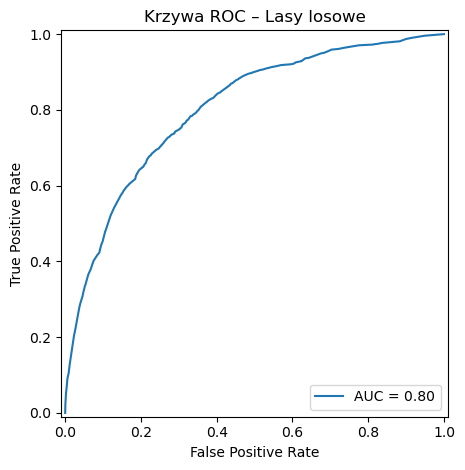

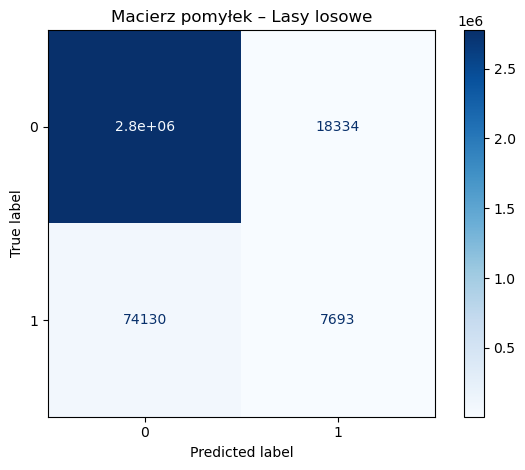

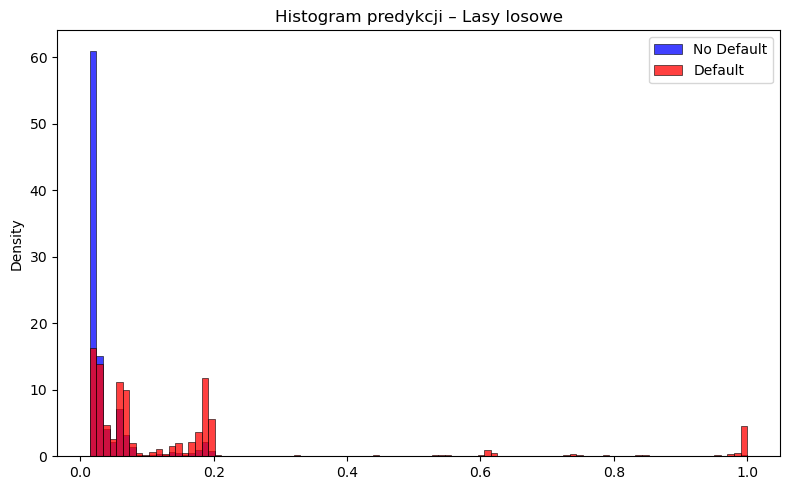

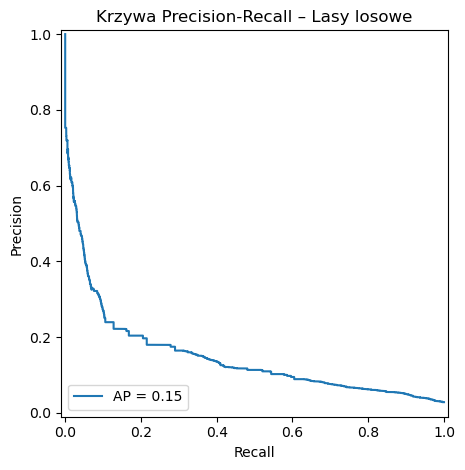

Obliczanie wartości SHAP...
Top 5 cech wg SHAP (bez pomocniczych): ['interest_rate', 'credit_score', 'maturity_date', 'months_30dpd', 'max_dpd']
TOP_CAT puste – używam pierwszych 5 z SAFE_CAT_FEATURES.
SAFE_CONT_FEATURES (n=14)
SAFE_CAT_FEATURES  (n=208)
TOP_CONT: ['interest_rate', 'credit_score', 'max_dpd']
TOP_CAT : ['super_conforming_flag', 'harp_indicator', 'first_time_homebuyer_flag_N', 'first_time_homebuyer_flag_Y', 'mi_percentage_12']


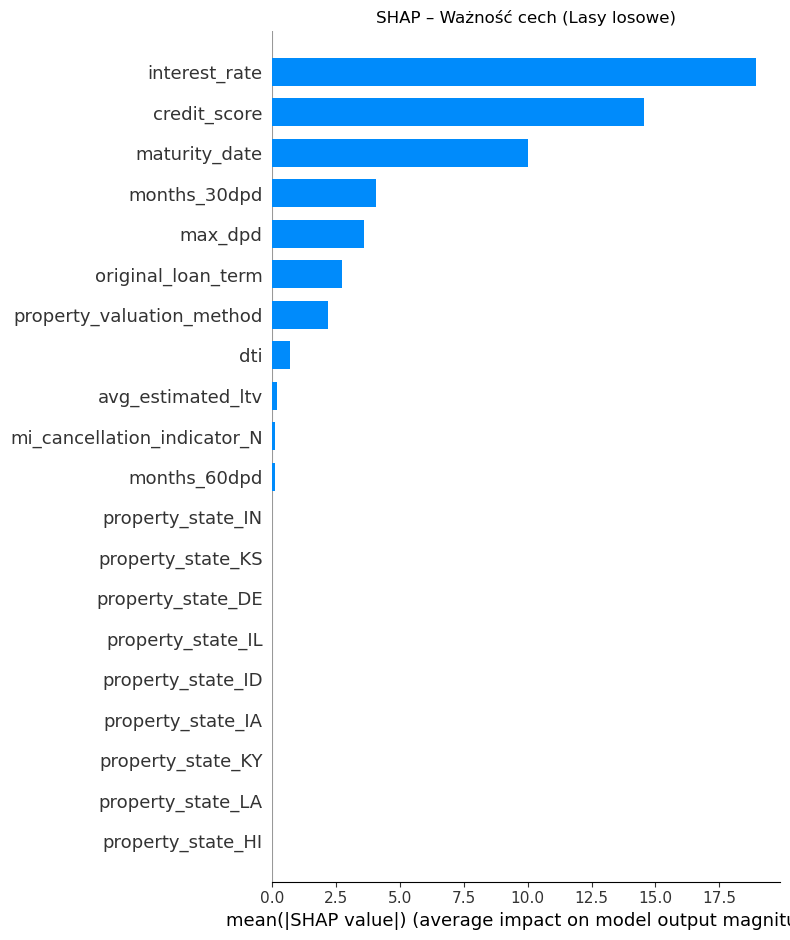

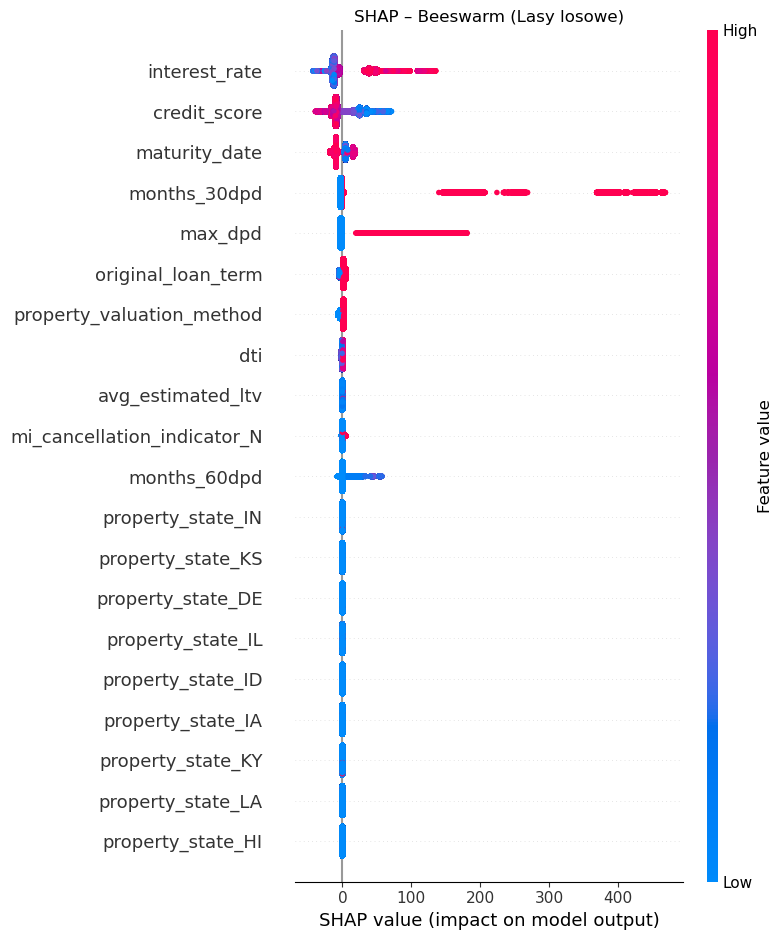

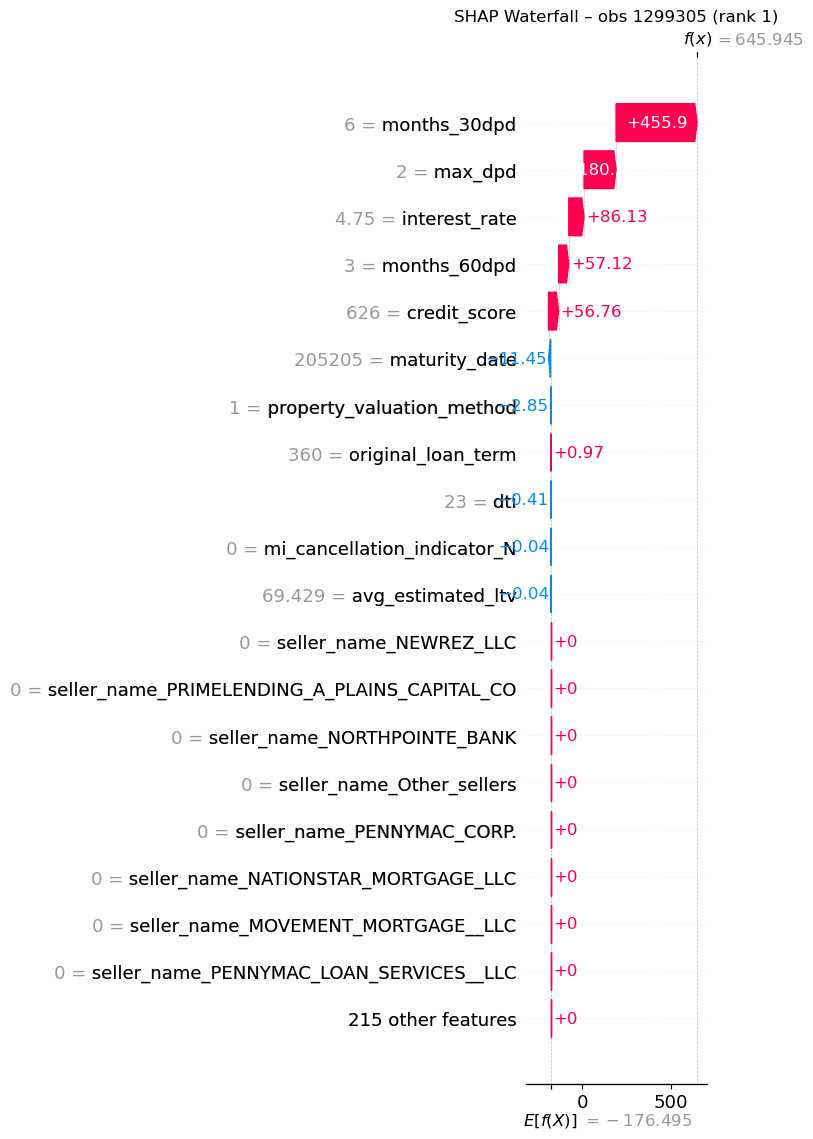

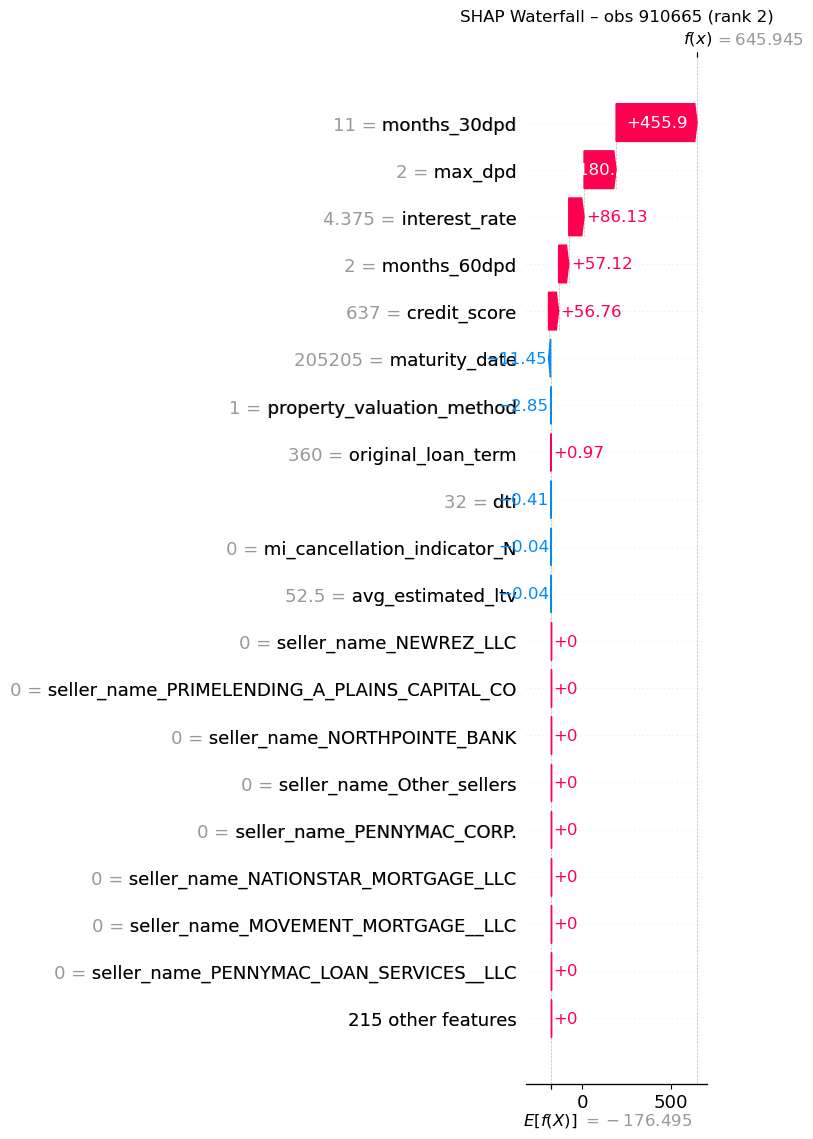

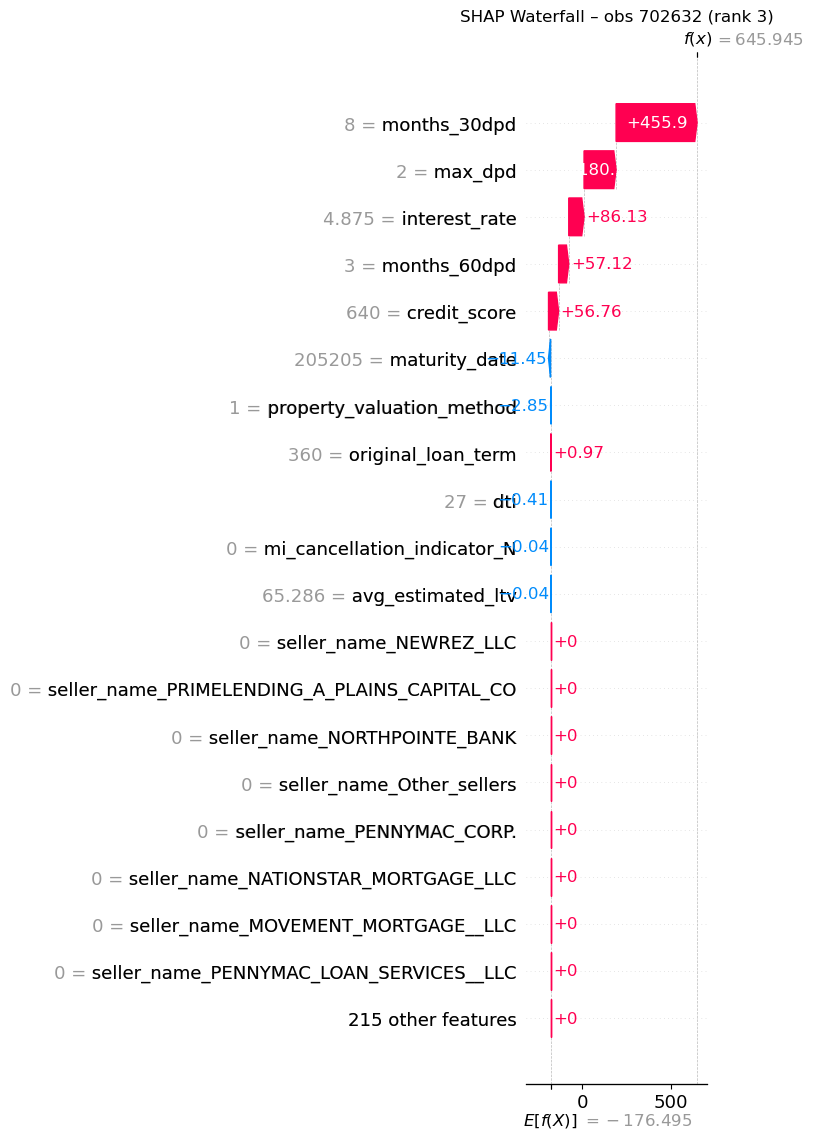

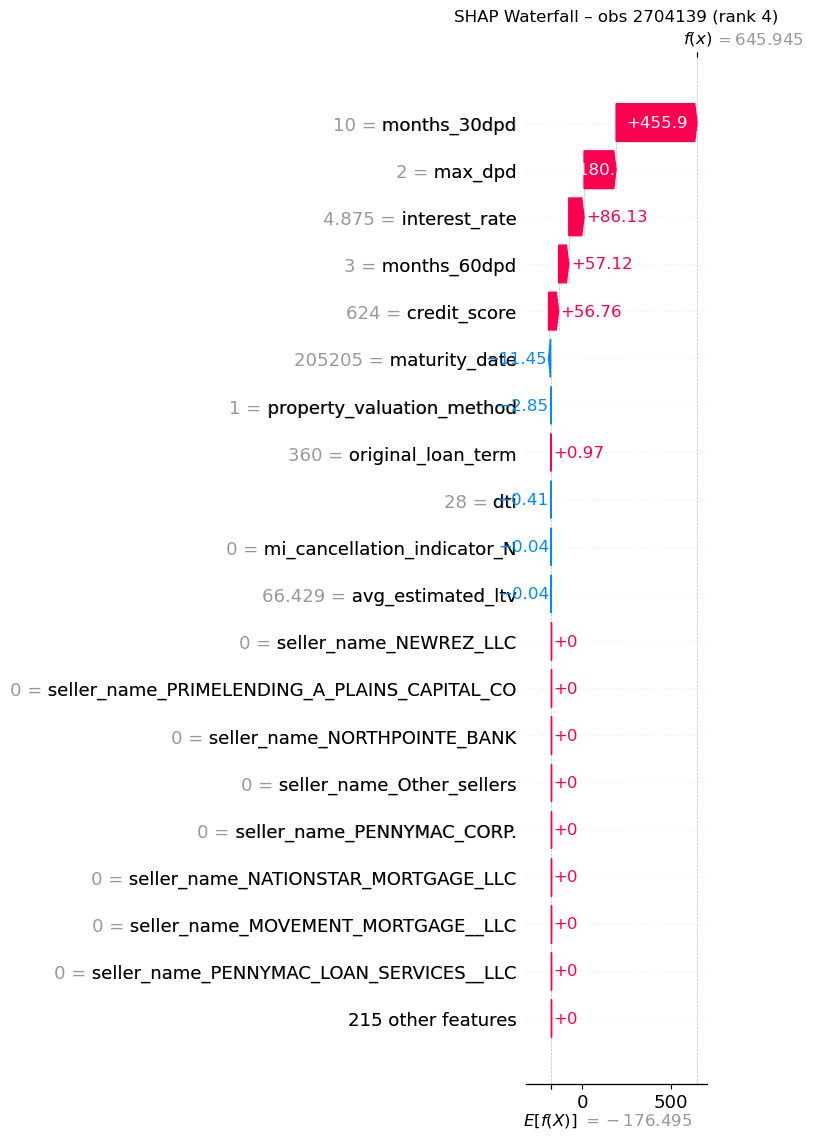

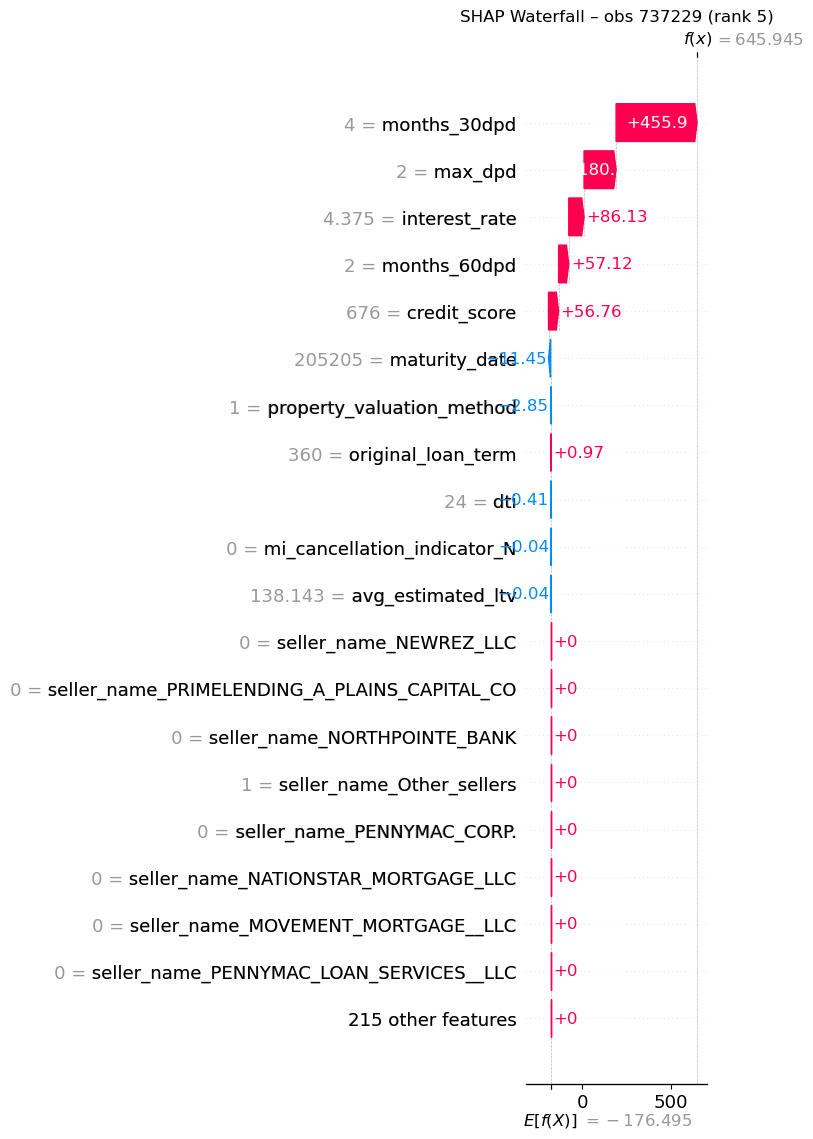

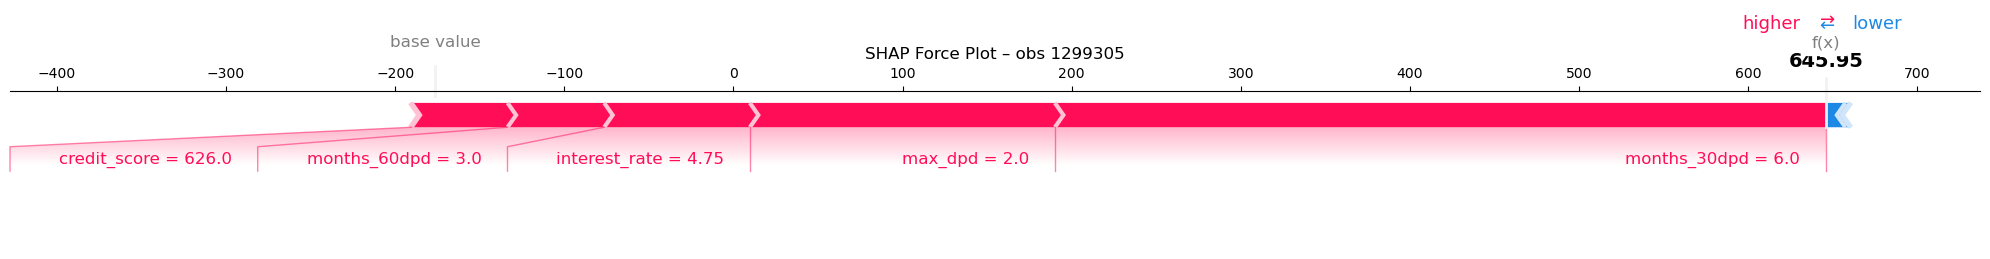

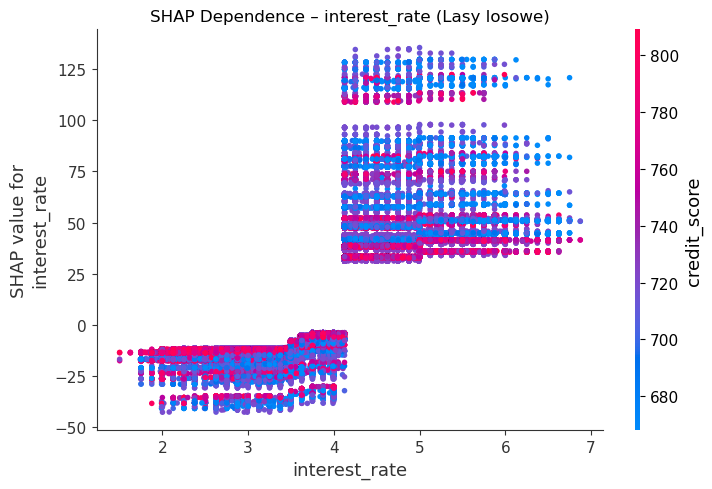

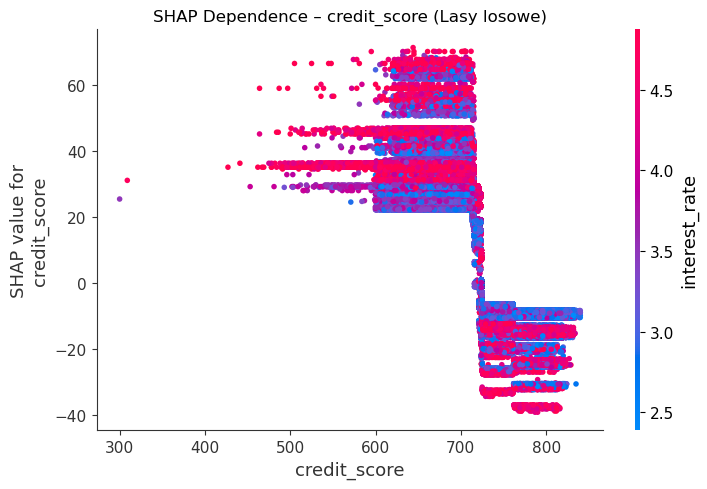

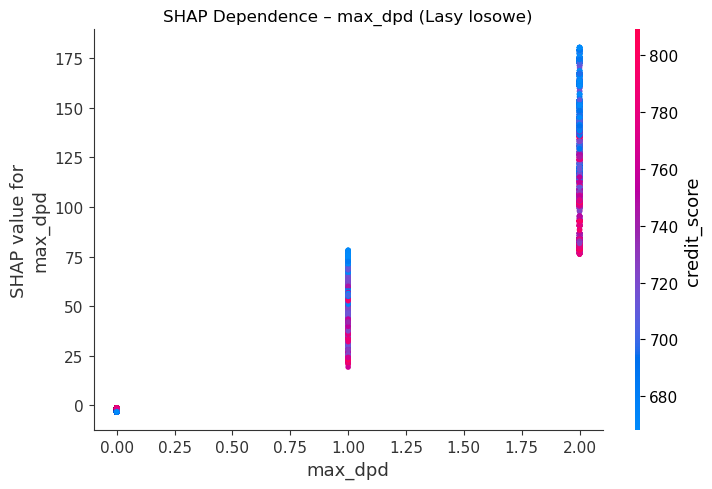

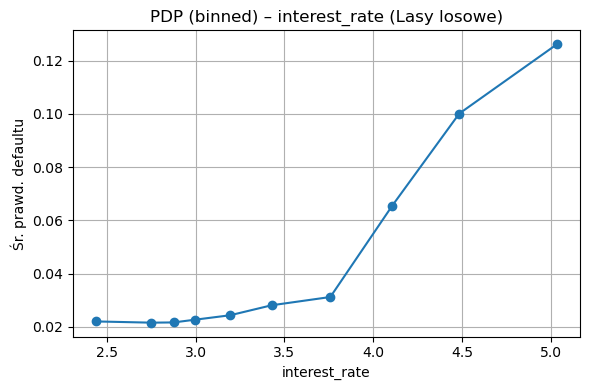

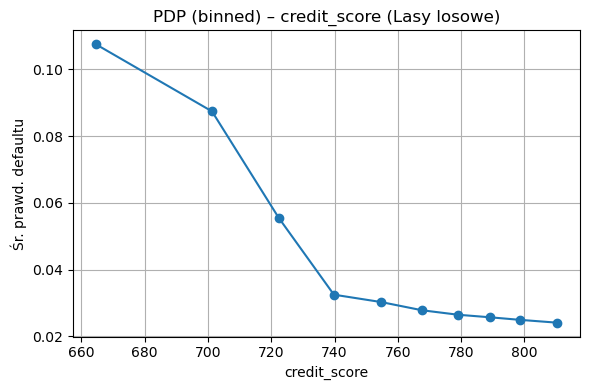

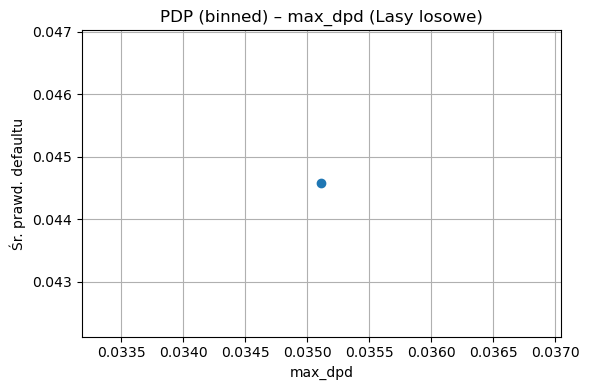

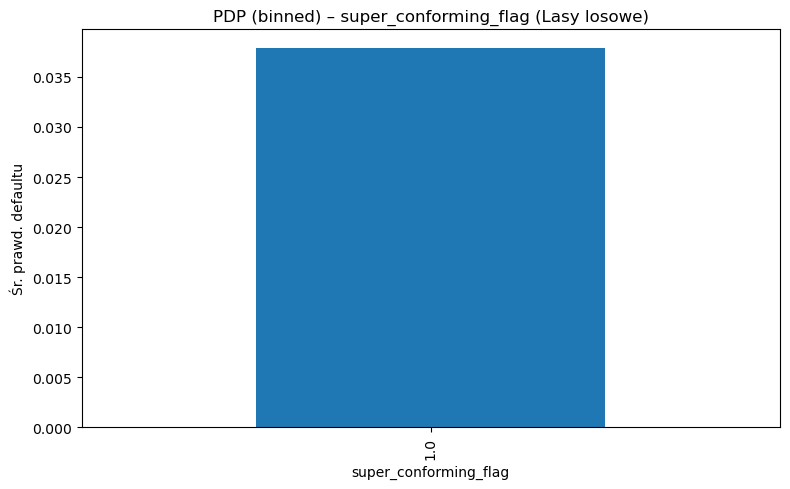

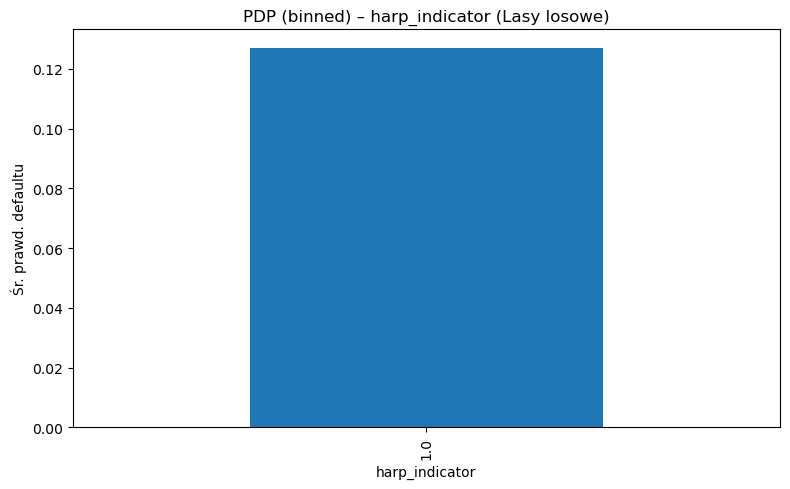

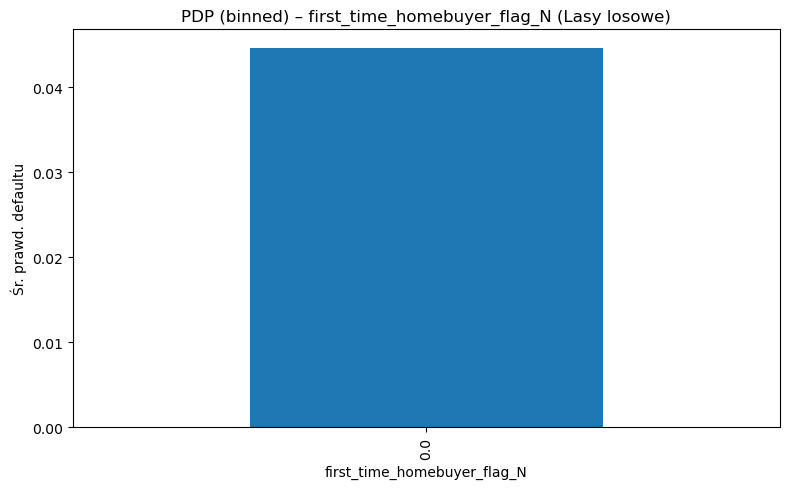

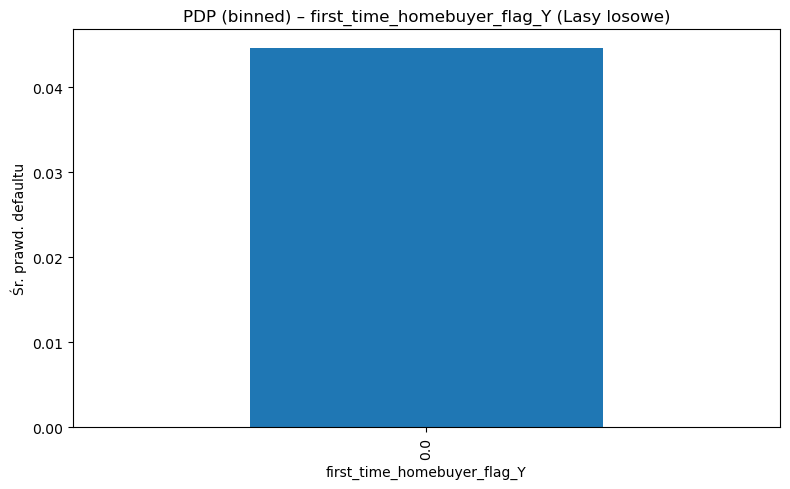

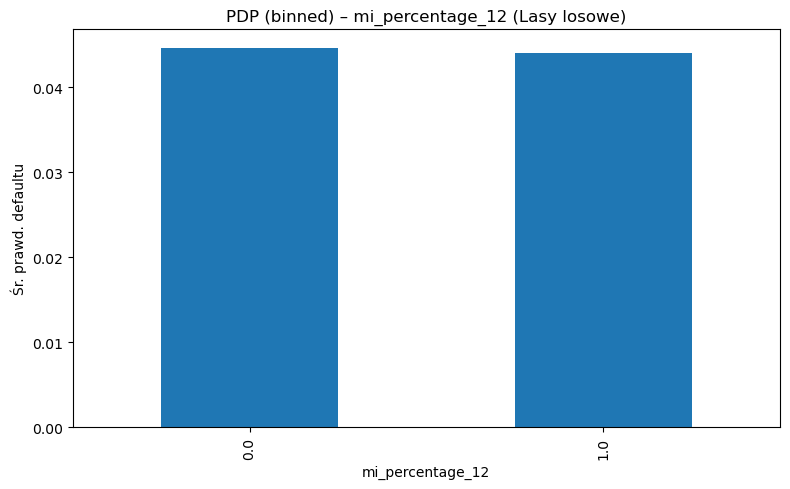

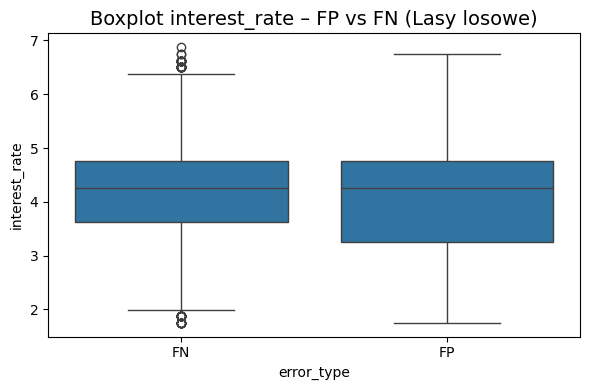

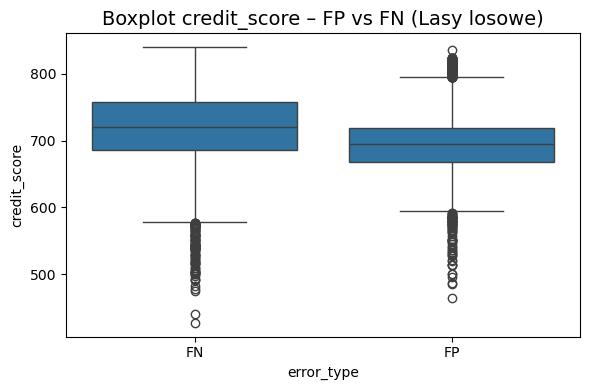

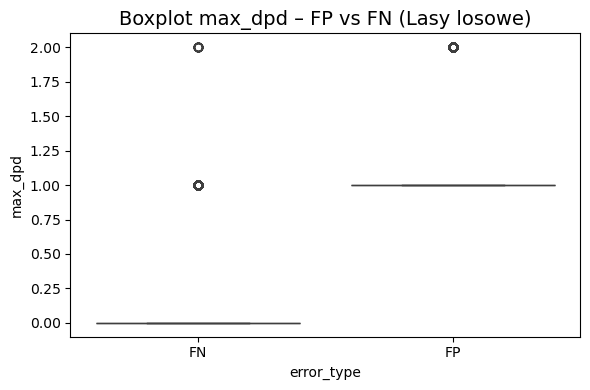

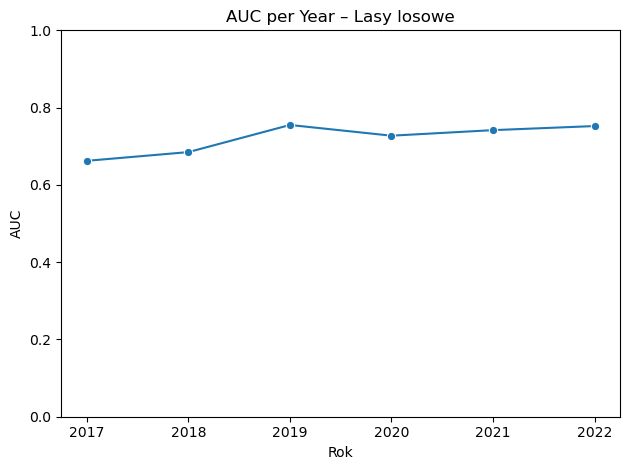

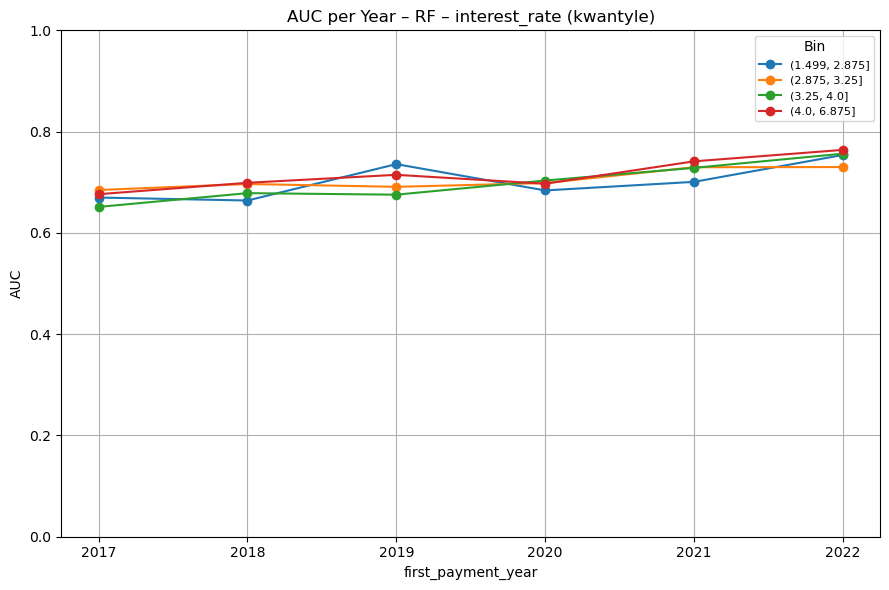

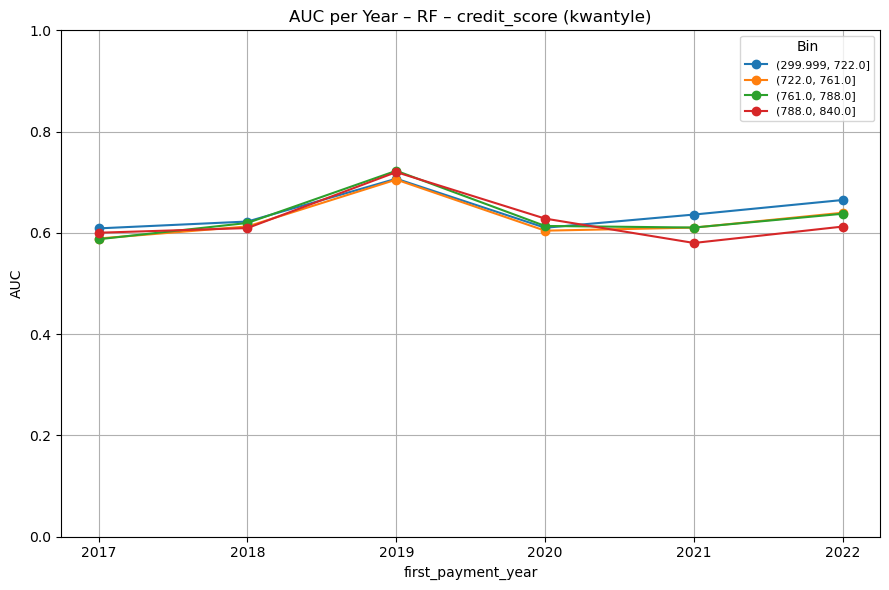

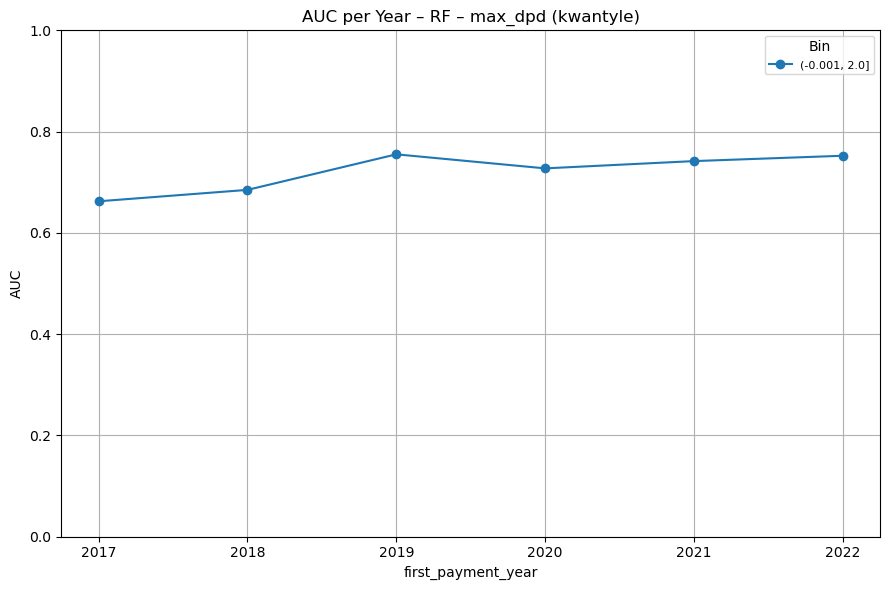

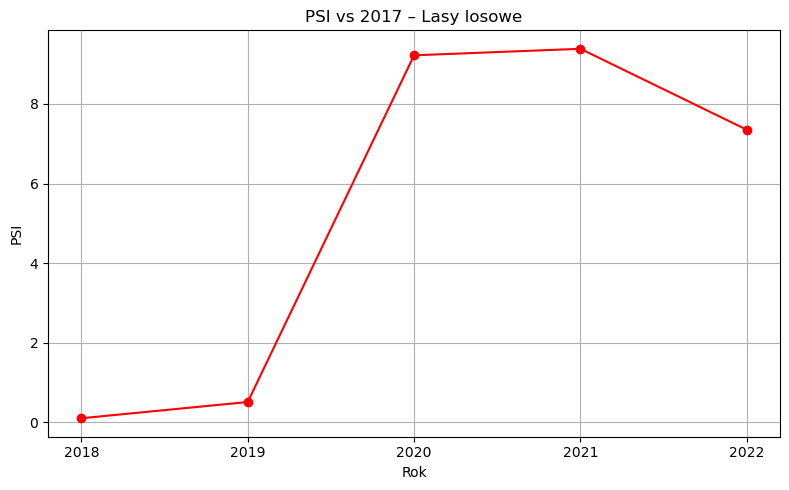

CSI – Miara stabilności względem roku bazowego (RF, inline)
Rok bazowy CSI: 2017


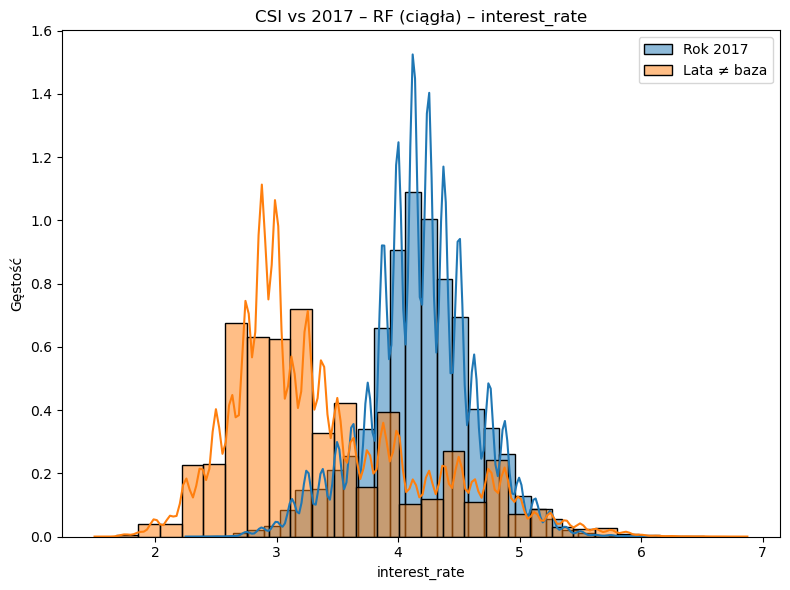

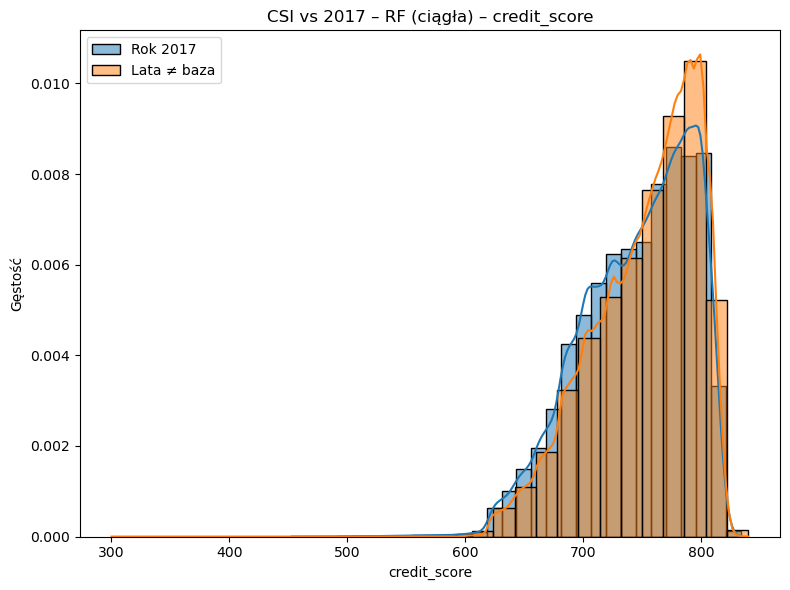

CSI CONT: pomijam max_dpd – brak sensownych binów.
Perturbacja cech — start (RF)
Perturbacja — cechy: ['interest_rate', 'credit_score', 'max_dpd']


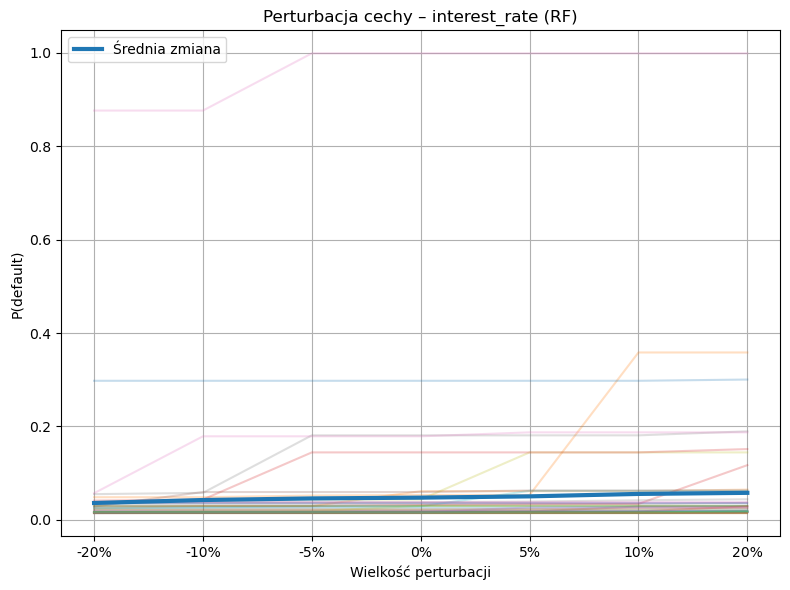

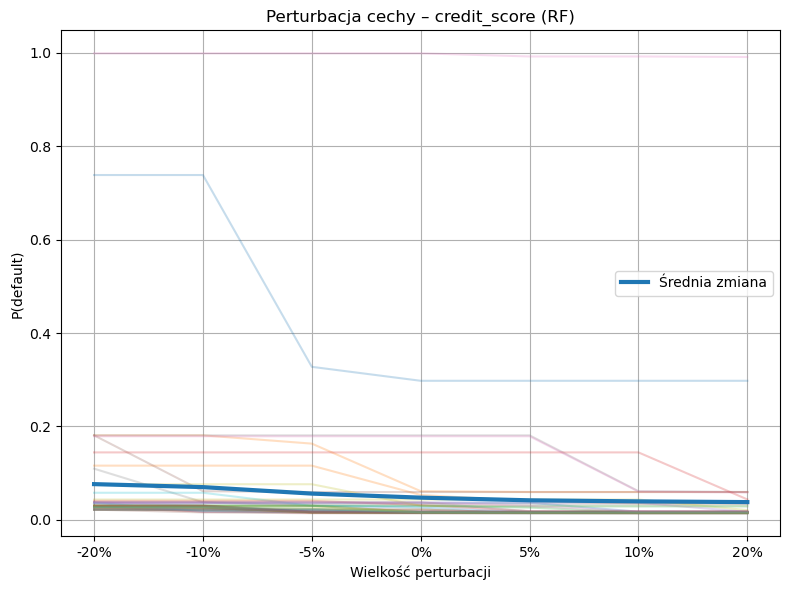

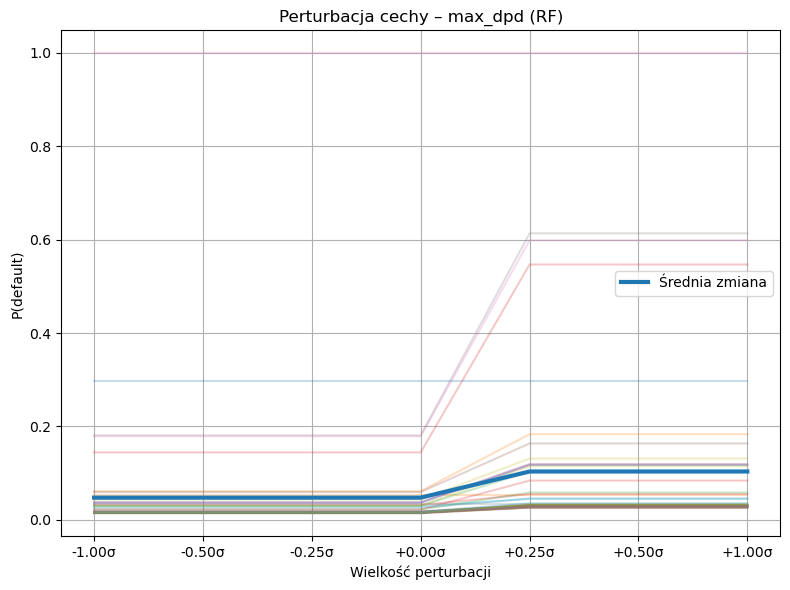

Zapisano: feature_perturbation_summary_rf.csv
Permutation importance...


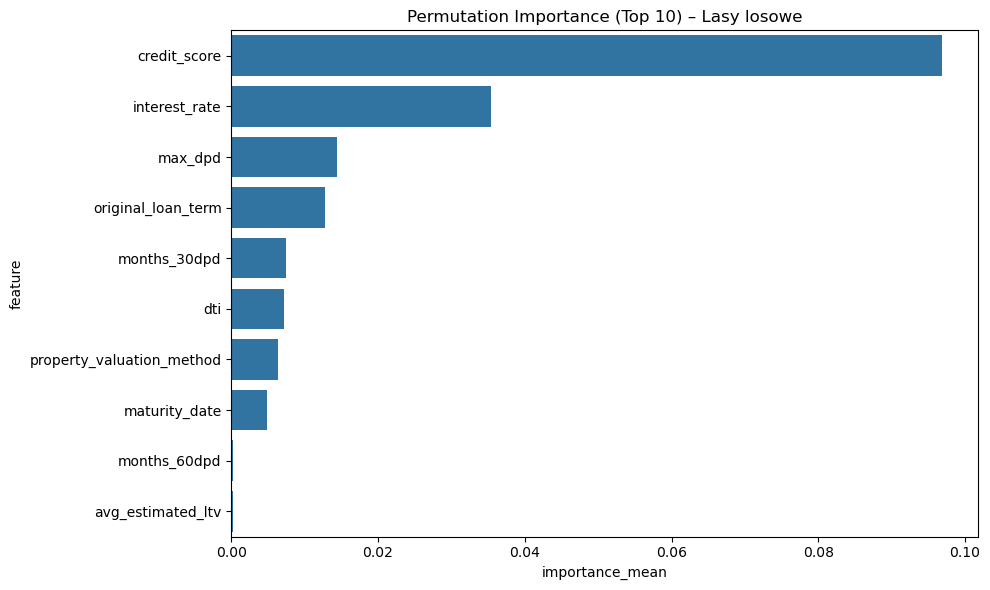

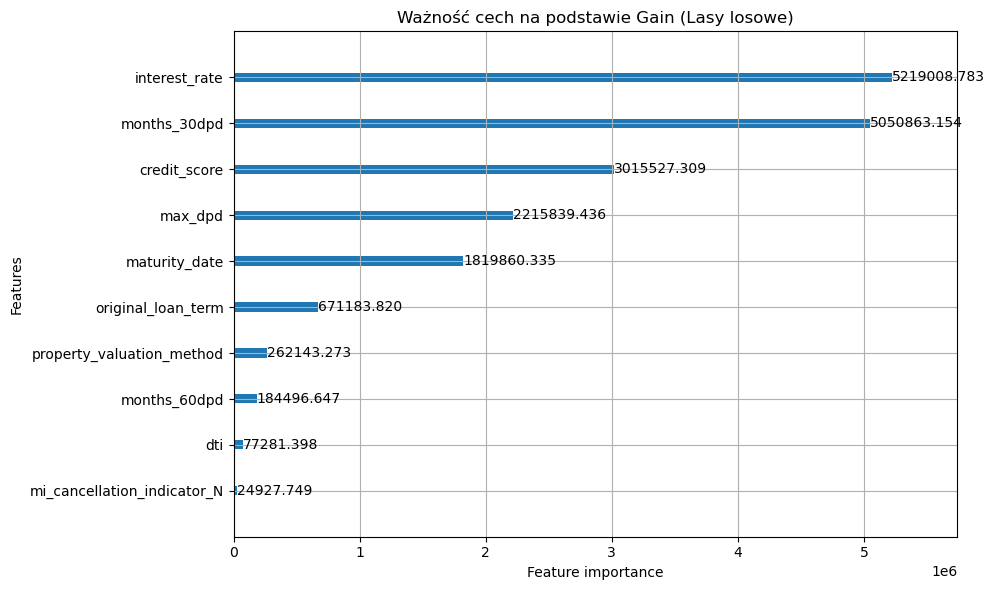

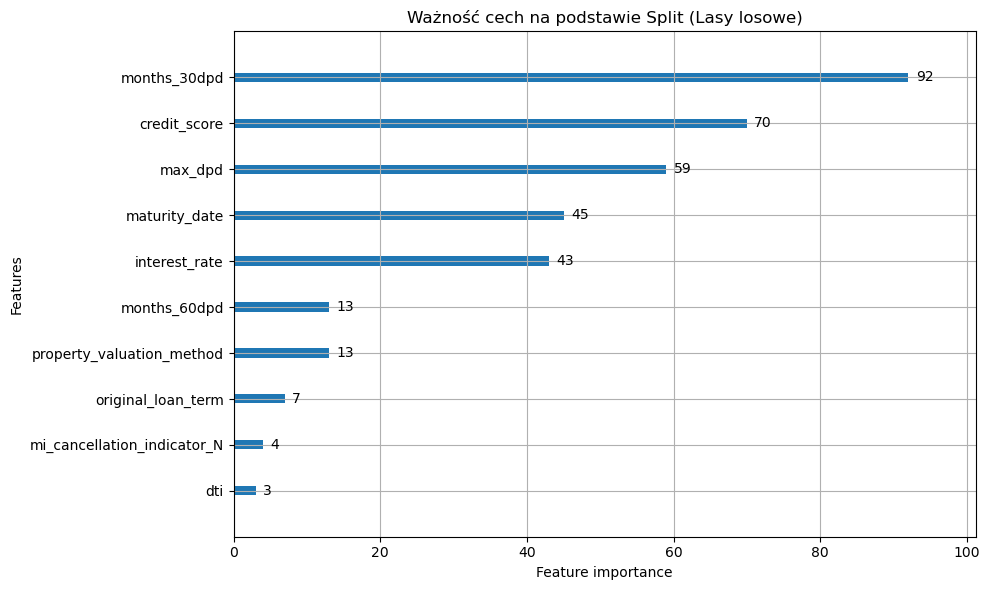

Analizy dla modelu lasów losowych zostały zapisane.


In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
import re
import joblib
import lightgbm as lgb
import warnings

from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, PrecisionRecallDisplay, average_precision_score
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
from pathlib import Path
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")

# Ścieżki
train_path = ""
test_path  = ""
data_path  = ""
output_dir = Path(data_path) / "Wyniki_Las_losowy"
output_dir.mkdir(parents=True, exist_ok=True)
print("Zapis wyników do:", output_dir.resolve())

# Próbka
df_train = duckdb.query(
    f"SELECT * FROM read_parquet('{train_path}') USING SAMPLE reservoir(2000 ROWS)"
).to_df()

df_test  = duckdb.query(
    f"SELECT * FROM read_parquet('{test_path}') USING SAMPLE reservoir(1000 ROWS)"
).to_df()

# Przygotowanie danych (YYYYMM -> rok)
def yyyymm_to_date(val):
    try:
        val = int(val)
        y, m = val // 100, val % 100
        if not (1 <= m <= 12):
            return pd.NaT
        return pd.Timestamp(year=y, month=m, day=1)
    except Exception:
        return pd.NaT

def ensure_first_payment_year(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "first_payment_year" not in df.columns:
        dt = df["first_payment_date"].apply(yyyymm_to_date)
        year = dt.dt.year
        if year.isna().mean() > 0.5:
            y2 = (pd.to_numeric(df["first_payment_date"], errors="coerce") // 100).astype("Int64")
            year = year.fillna(y2)
        df["first_payment_year"] = year
    # Wymuszenie integer-nullable
    df["first_payment_year"] = pd.to_numeric(df["first_payment_year"], errors="coerce").astype("Int64")
    return df

df_train = ensure_first_payment_year(df_train)
df_test  = ensure_first_payment_year(df_test)

# Usuwanie surowej daty
for _df in (df_train, df_test):
    _df.drop(columns=[c for c in _df.columns if "first_payment_date" in c.lower()],
             inplace=True, errors="ignore")
 
# macierze cech/cel
X_train = df_train.drop(columns=["loan_id", "default_flag"], errors="ignore")
y_train = pd.to_numeric(df_train["default_flag"], errors="coerce").astype("int8")
X_test  = df_test.drop(columns=["loan_id", "default_flag"], errors="ignore")
y_test  = pd.to_numeric(df_test["default_flag"], errors="coerce").astype("int8")

# porządki w typach
for d in [X_train, X_test]:
    if "number_of_borrowers" in d.columns:
        d["number_of_borrowers"] = pd.to_numeric(d["number_of_borrowers"], errors="coerce")
    if "first_payment_year" in d.columns:
        d["first_payment_year"] = pd.to_numeric(d["first_payment_year"], errors="coerce").astype("Int64")

# Usunięcie datetimes
X_train = X_train.select_dtypes(exclude=["datetime64[ns]"])
X_test  = X_test.select_dtypes(exclude=["datetime64[ns]"])

# Kolumny o bardzo wysokiej kategoryczności
high_cardinality_cols = [c for c in X_train.columns if X_train[c].dtype == "object" and X_train[c].nunique() > 100]
X_train.drop(columns=high_cardinality_cols, inplace=True)
X_test.drop(columns=[c for c in high_cardinality_cols if c in X_test.columns], inplace=True)

# Mapowanie Y/N -> 1/0
def map_binary_yn(df):
    for col in df.select_dtypes(include="object").columns:
        vals = set(df[col].dropna().unique())
        if vals <= {"Y", "N"} or vals <= {"y", "n"} or vals <= {"Y","N","y","n"}:
            df[col] = df[col].astype(str).str.upper().map({"Y": 1, "N": 0})
    return df

X_train = map_binary_yn(X_train)
X_test  = map_binary_yn(X_test)

# One-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# Czyszczenie nazw
def clean_lgbm_names(name):
    return name.translate(str.maketrans({
        "[": "_", "]": "_", "<": "_", ">": "_", "=": "_", "{": "_", "}": "_",
        "(": "_", ")": "_", ":": "_", ",": "_", "'": "_", '"': "_", " ": "_"
    }))

X_train.columns = [clean_lgbm_names(c) for c in X_train.columns]
X_test.columns  = X_train.columns.copy()
shap_feature_names = X_test.columns.tolist()

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

# Sanity check dla metryk po roku
assert "first_payment_year" in df_test.columns and not df_test["first_payment_year"].isna().all(), \
    "Brak/NaN w first_payment_year po parsowaniu."

# RandomizedSearchCV
base_model = lgb.LGBMClassifier(boosting_type='rf', objective='binary', random_state=42, n_jobs=-1)
param_distributions = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
rs = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,    
    cv=3,         
    scoring="roc_auc",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train, y_train)
model = rs.best_estimator_
print("Najlepsze parametry:", rs.best_params_)

best = rs.best_params_
print("Best (subsample):", best)

# Refit na całym zbiorze
df_train_full = duckdb.query(f"SELECT * FROM read_parquet('{train_path}')").to_df()
df_test_full  = duckdb.query(f"SELECT * FROM read_parquet('{test_path}')").to_df()

# Preprocessing
df_test_full  = ensure_first_payment_year(df_test_full)
for _df in (df_train_full, df_test_full):
    _df.drop(columns=[c for c in _df.columns if "first_payment_date" in c.lower()],
             inplace=True, errors="ignore")

X_train_full = df_train_full.drop(columns=["loan_id","default_flag"], errors="ignore")
y_train_full = pd.to_numeric(df_train_full["default_flag"], errors="coerce").astype("int8")
X_test_full  = df_test_full.drop(columns=["loan_id","default_flag"], errors="ignore")
y_test_full  = pd.to_numeric(df_test_full["default_flag"], errors="coerce").astype("int8")

for d in (X_train_full, X_test_full):
    if "number_of_borrowers" in d.columns:
        d["number_of_borrowers"] = pd.to_numeric(d["number_of_borrowers"], errors="coerce")
    if "first_payment_year" in d.columns:
        d["first_payment_year"] = pd.to_numeric(d["first_payment_year"], errors="coerce").astype("Int64")

X_train_full = X_train_full.select_dtypes(exclude=["datetime64[ns]"])
X_test_full  = X_test_full.select_dtypes(exclude=["datetime64[ns]"])

high_card = [c for c in X_train_full.columns if X_train_full[c].dtype=="object" and X_train_full[c].nunique()>100]
X_train_full.drop(columns=high_card, inplace=True)
X_test_full.drop(columns=[c for c in high_card if c in X_test_full.columns], inplace=True)

X_train_full = map_binary_yn(X_train_full)
X_test_full  = map_binary_yn(X_test_full)

X_train_full = pd.get_dummies(X_train_full, drop_first=True)
X_test_full  = pd.get_dummies(X_test_full,  drop_first=True)
X_test_full  = X_test_full.reindex(columns=X_train_full.columns, fill_value=0)

X_train_full.columns = [clean_lgbm_names(c) for c in X_train_full.columns]
X_test_full.columns  = X_train_full.columns
X_train_full = X_train_full.astype(np.float32)
X_test_full  = X_test_full.astype(np.float32)

# Finalny model na pełnym treningu
model = lgb.LGBMClassifier(boosting_type='rf', objective='binary', random_state=42, n_jobs=-1, **best)
model.fit(X_train_full, y_train_full)

y_proba = model.predict_proba(X_test_full)[:, 1]
y_pred  = model.predict(X_test_full)
df_test = df_test_full.copy()      
df_test["y_proba"] = y_proba
y_test = y_test_full               
X_test = X_test_full               
shap_feature_names = X_test.columns.tolist()

# Ewaluacja i predykcje
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
df_test["y_proba"] = y_proba

#====
# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_score(y_test, y_proba)).plot()
plt.title("Krzywa ROC – Lasy losowe")
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve_lightgbm_rf.png", dpi=150)
plt.show()

#=================
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Macierz pomyłek – Lasy losowe")
plt.tight_layout()
plt.savefig(f"{output_dir}/conf_matrix_lightgbm_rf.png", dpi=150)
plt.show()

#====================
# Histogram predykcji
plt.figure(figsize=(8, 5))
sns.histplot(y_proba[y_test == 0], color="blue", label="No Default", stat="density", bins=100)
sns.histplot(y_proba[y_test == 1], color="red",  label="Default",   stat="density", bins=100)
plt.legend()
plt.title("Histogram predykcji – Lasy losowe")
plt.tight_layout()
plt.savefig(f"{output_dir}/prediction_hist_lasy_losowe.png")
plt.show()
plt.close()

#=================
# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap).plot()
plt.title("Krzywa Precision-Recall – Lasy losowe")
plt.tight_layout()
plt.savefig(f"{output_dir}/precision_recall_curve_lightgbm_rf.png", dpi=150)
plt.show()

#=====
# SHAP
print("Obliczanie wartości SHAP...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ==========================
# TOP 5 cech wg mean(|SHAP|)

EXCLUDE_FEATURES = {"first_payment_year"}

importances = np.abs(shap_values).mean(axis=0)
top5 = (
    pd.Series(importances, index=X_test.columns)
    .drop(labels=EXCLUDE_FEATURES, errors="ignore")  
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print("Top 5 cech wg SHAP (bez pomocniczych):", top5)

# PODZIAŁ: CONT vs CAT (po OHE) + TOP_LISTY
_EXCLUDE_NAME_TOKENS = [
    "msa","zip","postal","code","id",
    "year","month","date","days_since","number_of_borrowers"
]
_EXCLUDE_EXACT = {"first_payment_year"}

def _is_name_excluded(name: str) -> bool:
    n = str(name).lower()
    if n in _EXCLUDE_EXACT:
        return True
    return any(tok in n for tok in _EXCLUDE_NAME_TOKENS)

def _is_binary_01(s: pd.Series) -> bool:
    u = pd.Series(s.dropna().unique())
    return (len(u) > 0) and u.isin([0, 1]).all()

# SAFE listy po OHE
SAFE_CAT_FEATURES = [
    c for c in X_test.columns
    if not _is_name_excluded(c)
    and _is_binary_01(X_test[c]) # dummy 0/1
]

SAFE_CONT_FEATURES = [
    c for c in X_test.columns
    if not _is_name_excluded(c)
    and pd.api.types.is_numeric_dtype(X_test[c])
    and not _is_binary_01(X_test[c])    # nie 0/1
    and X_test[c].nunique(dropna=True) >= 3
]

# TOP z rankingu SHAP
if "top5" in globals() and isinstance(top5, (list, tuple)) and len(top5) > 0:
    TOP_ALL = [c for c in top5 if c in X_test.columns]
elif "top_vars" in globals() and isinstance(top_vars, (list, tuple)) and len(top_vars) > 0:
    TOP_ALL = [c for c in top_vars if c in X_test.columns]
else:
    TOP_ALL = []

TOP_CONT = [c for c in TOP_ALL if c in SAFE_CONT_FEATURES]
TOP_CAT  = [c for c in TOP_ALL if c in SAFE_CAT_FEATURES]

# Fallbacki defensywne
if not TOP_CONT:
    print("TOP_CONT puste – używam pierwszych 5 z SAFE_CONT_FEATURES.")
    TOP_CONT = SAFE_CONT_FEATURES[:5]
if not TOP_CAT:
    print("TOP_CAT puste – używam pierwszych 5 z SAFE_CAT_FEATURES.")
    TOP_CAT = SAFE_CAT_FEATURES[:5]

print("SAFE_CONT_FEATURES (n=%d)" % len(SAFE_CONT_FEATURES))
print("SAFE_CAT_FEATURES  (n=%d)" % len(SAFE_CAT_FEATURES))
print("TOP_CONT:", TOP_CONT)
print("TOP_CAT :", TOP_CAT)


# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP – Ważność cech (Lasy losowe)")
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_bar_lightgbm_rf.png", dpi=150)
plt.show()

# Beeswarm plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP – Beeswarm (Lasy losowe)")
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_beeswarm_lightgbm_rf.png", dpi=150)
plt.show()

# Waterfall: Top-5 obserwacji wg sumy |SHAP|
impact = np.abs(shap_values).sum(axis=1)
idx_sorted = np.argsort(impact)[::-1]
idx_keep = [int(i) for i in idx_sorted if np.isfinite(impact[int(i)]) and impact[int(i)] > 1e-8][:5]

for rank, idx in enumerate(idx_keep, start=1):
    try:
        base_val = (explainer.expected_value[1]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value)
        exp = shap.Explanation(
            values=shap_values[idx],
            base_values=base_val,
            data=X_test.iloc[idx],
            feature_names=shap_feature_names
        )
        shap.plots.waterfall(exp, max_display=20, show=False)
        plt.title(f"SHAP Waterfall – obs {idx} (rank {rank})")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/shap_waterfall_rank{rank}_obs{idx}_lightgbm_rf.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Błąd waterfall plot dla obs {idx}: {e}")

# Force plot
try:
    base_val = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value)
    shap.force_plot(base_val, shap_values[idx_keep[0]], X_test.iloc[idx_keep[0]],
                    matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot – obs {idx_keep[0]}")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_force_obs{idx_keep[0]}_lightgbm_rf.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"Błąd force plot: {e}")

# helper do bezpiecznych nazw plików
def _safe_fname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))
    
# ======================
# SHAP dependence – CONT
for feature in TOP_CONT[:5]:
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.title(f"SHAP Dependence – {feature} (Lasy losowe)")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_dependence_{_safe_fname(feature)}_rf.png", dpi=150)
    plt.show(); plt.close()

# ===================
# PDP (binned) – CONT
for feature in TOP_CONT[:5]:
    df_plot = pd.DataFrame({feature: X_test[feature], "pred_prob": y_proba}).dropna()
    if df_plot.empty:
        continue
    try:
        df_plot["bin"] = pd.qcut(df_plot[feature], q=10, duplicates='drop')
    except Exception:
        print(f"PDP: pominięta zmienna {feature} – brak sensownych kwantyli.")
        continue

    bin_means  = df_plot.groupby("bin", observed=False)[feature].mean()
    pred_means = df_plot.groupby("bin", observed=False)["pred_prob"].mean()

    plt.figure(figsize=(6, 4))
    plt.plot(bin_means, pred_means, marker="o")
    plt.title(f"PDP (binned) – {feature} (Lasy losowe)")
    plt.xlabel(feature); plt.ylabel("Śr. prawd. defaultu")
    plt.grid(True); plt.tight_layout()
    plt.savefig(f"{output_dir}/pdp_binned_{_safe_fname(feature)}_rf.png", dpi=150)
    plt.show(); plt.close()

# ==================
# PDP (binned) – CAT
for feature in TOP_CAT[:5]:
    dfc = pd.DataFrame({feature: X_test[feature], "pred_prob": y_proba}).dropna()
    if dfc.empty:
        continue
    grouped = dfc.groupby(feature)["pred_prob"].mean().sort_index()

    ax = grouped.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"PDP (binned) – {feature} (Lasy losowe)")
    ax.set_xlabel(feature); ax.set_ylabel("Śr. prawd. defaultu")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/pdp_binned_{_safe_fname(feature)}_rf.png", dpi=150)
    plt.show(); plt.close()

#=================
# Boxplot FP vs FN
error_df = X_test.copy()
error_df["y_true"]  = y_test.values
error_df["y_pred"]  = y_pred
error_df["y_proba"] = y_proba
error_df["error_type"] = np.select(
    [(error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
     (error_df["y_true"] == 1) & (error_df["y_pred"] == 0)],
    ["FP", "FN"], default="Correct"
)
err_subset = error_df[error_df["error_type"].isin(["FP", "FN"])].copy()

for feat in TOP_CONT[:5]:
    if feat in err_subset.columns and pd.api.types.is_numeric_dtype(err_subset[feat]):
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=err_subset, x="error_type", y=feat)
        plt.title(f"Boxplot {feat} – FP vs FN (Lasy losowe)", fontsize=14)
        plt.tight_layout()
        plt.savefig(f"{output_dir}/boxplot_fpfn_{feat}_lightgbm_rf.png")
        plt.show(); plt.close()

#=====================
# FP/FN + AUC per year
errors_df = df_test.copy()
errors_df["y_true"] = y_test
errors_df["y_pred"] = y_pred
errors_df["y_proba"] = y_proba
errors_df["error_type"] = np.select([
    (y_test == 0) & (y_pred == 1),
    (y_test == 1) & (y_pred == 0)
], ["FP", "FN"], default="Correct")
errors_df[errors_df["error_type"] != "Correct"].to_csv(
    f"{output_dir}/prediction_errors_fp_fn_lightgbm_rf.csv", index=False)

#========================
# AUC per year (globalne)
from matplotlib.ticker import MaxNLocator

# Dane wejściowe
years = pd.to_numeric(df_test["first_payment_year"], errors="coerce").astype("Int64")
y_proba_s = pd.Series(y_proba, index=df_test.index)

df_auc = pd.DataFrame({
    "year": years,
    "y_true": y_test.astype(int),
    "y_proba": y_proba_s
}).dropna(subset=["year"])

# Filtrowanie lat: wymaganie  obu klas i minimalnej liczności
min_group = 20
cnt = df_auc.groupby("year").agg(
    n=("y_true", "size"),
    pos=("y_true", "sum")
)
cnt["neg"] = cnt["n"] - cnt["pos"]
ok_years = cnt.index[(cnt["n"] >= min_group) & (cnt["pos"] > 0) & (cnt["neg"] > 0)]

# AUC per year 
auc_rows = []
for yr, g in df_auc[df_auc["year"].isin(ok_years)].groupby("year", sort=True):
    auc_rows.append({"year": int(yr), "AUC": roc_auc_score(g["y_true"], g["y_proba"])})

auc_per_year = pd.DataFrame(auc_rows).sort_values("year")

# Diagnostyka, gdy brak
if auc_per_year.empty:
    print("Brak lat z obiema klasami lub zbyt mała liczność. Rozkład klas po latach:")
    print(cnt)
else:
    ax = sns.lineplot(data=auc_per_year, x="year", y="AUC", marker="o")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.ylim(0.0, 1.0)
    plt.title("AUC per Year – Lasy losowe")
    plt.xlabel("Rok"); plt.ylabel("AUC")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/auc_per_year_lightgbm_rf.png", dpi=150)
    plt.show()
    auc_per_year.to_csv(f"{output_dir}/auc_per_year_lightgbm_rf.csv", index=False)


# AUC per year by bin
nbins, min_group = 4, 30  # liczba kwantyli i minimalna liczność w grupie

def _safe(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))

years_s = pd.to_numeric(df_test["first_payment_year"], errors="coerce").astype("Int64")

for feat in TOP_CONT[:5]:
    if feat not in X_test.columns or not pd.api.types.is_numeric_dtype(X_test[feat]):
        continue

    tmp = pd.DataFrame({
        "year": years_s,
        "feat": pd.to_numeric(X_test[feat], errors="coerce"),
        "y_true": y_test.values,
        "y_proba": y_proba
    }).dropna(subset=["year", "feat"])

    try:
        tmp["bin"] = pd.qcut(tmp["feat"], q=nbins, duplicates="drop")
    except Exception:
        print(f"Pominięcie {feat} – za mało unikalnych wartości do qcut.")
        continue

    rows = []
    for (yr, b), g in tmp.groupby(["year", "bin"], observed=False):
        if len(g) < min_group or g["y_true"].nunique() < 2:
            continue
        rows.append({"year": int(yr), "bin": str(b),
                     "AUC": roc_auc_score(g["y_true"], g["y_proba"])})

    if not rows:
        print(f"Brak danych do AUC per year dla {feat}."); 
        continue

    res = pd.DataFrame(rows).sort_values(["year", "bin"])
    res.to_csv(output_dir / f"auc_per_year_by_bin_{_safe(feat)}_rf.csv", index=False)

    pivot = res.pivot(index="year", columns="bin", values="AUC").sort_index()
    plt.figure(figsize=(9,6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=str(col))
    ax = plt.gca(); ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.ylim(0.0, 1.0); plt.grid(True)
    plt.title(f"AUC per Year – RF – {feat} (kwantyle)")
    plt.xlabel("first_payment_year"); plt.ylabel("AUC")
    plt.legend(title="Bin", fontsize=8)
    plt.tight_layout()
    plt.savefig(output_dir / f"auc_per_year_by_bin_{_safe(feat)}_rf.png", dpi=150)
    plt.show()
    plt.close()

#====
# PSI
def calculate_psi(expected, actual, bins=10):
    expected_percents, _ = np.histogram(expected, bins=bins, range=(0, 1), density=True)
    actual_percents, _ = np.histogram(actual, bins=bins, range=(0, 1), density=True)
    expected_percents += 1e-6
    actual_percents += 1e-6
    return np.sum((expected_percents - actual_percents) * np.log(expected_percents / actual_percents))

if "first_payment_year" in df_test.columns:
    base_year = 2017
    base_scores = df_test[df_test["first_payment_year"] == base_year]["y_proba"]
    psi_vals = []
    for year in sorted(df_test["first_payment_year"].dropna().unique()):
        if year == base_year:
            continue
        actual = df_test[df_test["first_payment_year"] == year]["y_proba"]
        psi_vals.append((year, calculate_psi(base_scores, actual)))

    psi_df = pd.DataFrame(psi_vals, columns=["Rok", "PSI"])

    plt.figure(figsize=(8,5))
    plt.plot(psi_df["Rok"], psi_df["PSI"], marker="o", color="red")
    plt.title("PSI vs 2017 – Lasy losowe")
    plt.xlabel("Rok")             
    plt.ylabel("PSI")             
    plt.xticks(psi_df["Rok"], psi_df["Rok"].astype(str))  # etykiety lat jako string
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/psi_lightgbm_rf.png", dpi=150)
    plt.show()

    psi_df.to_csv(f"{output_dir}/psi_lightgbm_rf.csv", index=False)

else:
    print("Brak kolumny first_payment_year – PSI pominięte.")

#====
# CSI
print("CSI – Miara stabilności względem roku bazowego (RF, inline)")

if "first_payment_year" not in df_test.columns:
    print("Brak 'first_payment_year' – pominięcie CSI.")
else:
    years = pd.to_numeric(df_test["first_payment_year"], errors="coerce").astype("Int64")
    base_year = 2017 if 2017 in years.dropna().unique() else int(years.value_counts().idxmax())
    print(f"Rok bazowy CSI: {base_year}")

    min_n = 30  # Minimalna liczność

    def _csi_inline(base_vals, cur_vals, edges):
        b = pd.to_numeric(pd.Series(base_vals), errors="coerce").dropna().values
        c = pd.to_numeric(pd.Series(cur_vals),  errors="coerce").dropna().values
        if b.size == 0 or c.size == 0:
            return np.nan
        b_cnt, _ = np.histogram(b, bins=edges)
        c_cnt, _ = np.histogram(c, bins=edges)
        if b_cnt.sum() == 0 or c_cnt.sum() == 0:
            return np.nan
        b_p = b_cnt / b_cnt.sum() + 1e-6
        c_p = c_cnt / c_cnt.sum() + 1e-6
        return float(np.sum((b_p - c_p) * np.log(b_p / c_p)))

    def _make_edges(all_vals, max_bins=10, min_bins=3):
        all_vals = pd.to_numeric(pd.Series(all_vals), errors="coerce").dropna().values
        if all_vals.size < 2:
            return None
        for b in range(max_bins, min_bins - 1, -1):
            q = np.quantile(all_vals, np.linspace(0, 1, b + 1))
            uniq = np.unique(q)
            if uniq.size >= (min_bins + 1):
                return uniq
        return None

    for feat in TOP_CONT:
        if feat not in X_test.columns or feat == "first_payment_year":
            continue

        vals = pd.to_numeric(X_test[feat], errors="coerce")
        df_feat = pd.DataFrame({"year": years, "val": vals}).dropna()
        if df_feat.empty or df_feat["val"].nunique() < 3:
            print(f"CSI CONT: pominięcie{feat} – zbyt mało unikalnych wartości.")
            continue

        base_vals = df_feat.loc[df_feat["year"] == base_year, "val"].values
        rest_vals = df_feat.loc[df_feat["year"] != base_year, "val"].values
        if base_vals.size < min_n or rest_vals.size < min_n:
            print(f"CSI CONT: pominięcie {feat} – za mało danych (base={base_vals.size}, rest={rest_vals.size}).")
            continue

        edges = _make_edges(np.concatenate([base_vals, rest_vals]), max_bins=10, min_bins=3)
        if edges is None or np.allclose(edges.min(), edges.max()):
            print(f"CSI CONT: pominięcie {feat} – brak sensownych binów.")
            continue

        rows = []
        for yr in sorted(df_feat["year"].dropna().unique()):
            yr = int(yr)
            if yr == base_year:
                continue
            cur = df_feat.loc[df_feat["year"] == yr, "val"].values
            if cur.size < min_n:
                rows.append({"Rok": yr, "CSI": np.nan})
                continue
            rows.append({"Rok": yr, "CSI": _csi_inline(base_vals, cur, edges)})

        if not rows:
            continue

        res = pd.DataFrame(rows).sort_values("Rok")
        safe = "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(feat))
        res.to_csv(os.path.join(output_dir, f"csi_{_safe_fname(feat)}_rf_cont.csv"), index=False)

        plt.figure(figsize=(8, 6))
        sns.histplot(base_vals, label=f"Rok {base_year}", kde=True, stat="density", bins=30)
        sns.histplot(rest_vals, label="Lata ≠ baza", kde=True, stat="density", bins=30)
        plt.title(f"CSI vs {base_year} – RF (ciągła) – {feat}")
        plt.xlabel(feat); plt.ylabel("Gęstość"); plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"csi_distribution_{_safe_fname(feat)}_rf_cont.png"), dpi=150)
        plt.show(); plt.close()

#=====================
# Feature perturbation
print("Perturbacja cech — start (RF)")

PERTURB_TOP_N   = 5
PERCENT_DELTAS  = np.array([-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20])
STD_STEPS       = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
SAMPLE_ROWS     = 200
SHOW_N_LINES    = 50

# Lista cech do perturbacji
if TOP_CONT:
    FEATURES_FOR_PERTURB = TOP_CONT[:PERTURB_TOP_N]
else:
    FEATURES_FOR_PERTURB = [c for c in X_test.columns if pd.api.types.is_numeric_dtype(X_test[c])][:PERTURB_TOP_N]

print("Perturbacja — cechy:", FEATURES_FOR_PERTURB)

perturb_summary_rows = []

base_idx = X_test.index[:min(SAMPLE_ROWS, len(X_test))]
X_base_all = X_test.loc[base_idx].copy()

for var in FEATURES_FOR_PERTURB:
    x = X_base_all[var].dropna()
    if x.empty:
        print(f"Pominięta zmienna {var} – same NaN.")
        continue

    use_multiplicative = (x.min() > 0) and (np.nanmedian(x) > 1e-12)
    preds_grid, labels = [], []

    if use_multiplicative:
        for d in PERCENT_DELTAS:
            Xp = X_base_all.copy()
            Xp[var] = x * (1.0 + d)
            y_pred = model.predict_proba(Xp)[:, 1]
            preds_grid.append(y_pred)
            labels.append(f"{int(d*100)}%")
    else:
        std = float(np.nanstd(x))
        if not np.isfinite(std) or std < 1e-12:
            continue
        for s in STD_STEPS:
            Xp = X_base_all.copy()
            Xp[var] = x + s * std
            y_pred = model.predict_proba(Xp)[:, 1]
            preds_grid.append(y_pred)
            labels.append(f"{s:+.2f}σ")

    # Wykres
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(min(SHOW_N_LINES, len(X_base_all))):
        ax.plot(range(len(labels)), [preds_grid[k][i] for k in range(len(labels))], alpha=0.25)
    mean_curve = np.array([np.mean(pg) for pg in preds_grid])
    ax.plot(range(len(labels)), mean_curve, linewidth=3, label="Średnia zmiana")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0)
    ax.set_title(f"Perturbacja cechy – {var} (RF)")
    ax.set_xlabel("Wielkość perturbacji"); ax.set_ylabel("P(default)")
    ax.legend(); ax.grid(True); fig.tight_layout()
    plt.savefig(os.path.join(output_dir, f"feature_perturbation_{_safe_fname(var)}_rf.png"), dpi=150)
    plt.show()
    plt.close(fig)

    # Podsumowanie
    row = {"feature": var}
    for lab, pg in zip(labels, preds_grid):
        row[f"mean_pred_{lab}"] = float(np.mean(pg))
    perturb_summary_rows.append(row)

# Zapis wykresu
if perturb_summary_rows:
    pd.DataFrame(perturb_summary_rows).to_csv(os.path.join(output_dir, "feature_perturbation_summary_rf.csv"), index=False)
    print("Zapisano: feature_perturbation_summary_rf.csv")
else:
    print("Perturbacja — brak wyników do zapisania.")

#=======================
# Permutation importance
print("Permutation importance...")

X_test_small = X_test.iloc[:1000, :].to_numpy(dtype=np.float32, copy=False)
y_test_small = y_test.iloc[:1000].to_numpy(dtype=np.int8, copy=False)

perm_result = permutation_importance(
    model,
    X_test_small,
    y_test_small,
    n_repeats=2,
    scoring="roc_auc",
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

perm_df.to_csv(f"{output_dir}/permutation_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance_mean", y="feature", data=perm_df.head(10))
plt.title("Permutation Importance (Top 10) – Lasy losowe")
plt.tight_layout()
plt.savefig(f"{output_dir}/permutation_importance.png", dpi=150)
plt.show()

#===========================================
# Natywne miary ważności cech – Gain i Split

# 1. Gain – Wzrost (redukcja błędu)
lgb.plot_importance(model, importance_type='gain', max_num_features=10, figsize=(10, 6), title="Ważność cech na podstawie Gain (Lasy losowe)")
plt.tight_layout()
plt.savefig(f"{output_dir}/feature_importance_gain_lightgbm.png", dpi=150)
plt.show()

# 2. Split – Częstotliwość użycia zmiennej do podziału
lgb.plot_importance(model, importance_type='split', max_num_features=10, figsize=(10, 6), title="Ważność cech na podstawie Split (Lasy losowe)")
plt.tight_layout()
plt.savefig(f"{output_dir}/feature_importance_split_lightgbm.png", dpi=150)
plt.show()

# Koniec kodu lasu losowego
print("Analizy dla modelu lasów losowych zostały zapisane.")